# 1. Wstęp

Współczesny krajobraz rynkowy przeszedł fundamentalną transformację — od jednorazowych transakcji w stronę **modeli subskrypcyjnych i abonamentowych**. Dziś niemal każda usługa, od telekomunikacji po rozrywkę, opiera się na cyklicznych płatnościach. Ten model tworzy specyficzny ekosystem pełen napięć na linii klient – przedsiębiorstwo.

### Dynamika rynku: Klient vs. Firma

* **Perspektywa Użytkownika:** Funkcjonuje w świecie nadmiaru ofert. Klienci są coraz bardziej świadomi, mobilni i skłonni do zmiany dostawcy w poszukiwaniu lepszej ceny, nowocześniejszej technologii czy wyższej jakości obsługi. W ich oczach każda kolejna subskrypcja to zobowiązanie, z którego chcą wycisnąć maksymalną wartość.
* **Perspektywa Organizacji:** Jej nadrzędnym celem jest maksymalizacja zysków i stabilizacja przychodów. W dobie nasycenia rynku, agresywne pozyskiwanie nowych abonentów staje się coraz droższe i trudniejsze. Dlatego firmy przykuwają wyższą uwagę do retencji (utrzymania) obecnych klientów.

### Rola analizy danych w zapobieganiu odejściom

W tym dynamicznym środowisku zjawisko **odpływu klientów** (ang. *churn*) przestało być jedynie statystyką, a stało się kluczowym wyzwaniem strategicznym. Firma, która nie potrafi przewidzieć momentu, w którym klient zaczyna rozważać odejście, traci szansę na reakcję. Jest to szczególnie istotne, gdyż konkurencja na rynku jest wyższa niż kiedykolwiek, a raz utracony klient może już nigdy nie wrócić.

Niniejszy projekt podejmuje to wyzwanie poprzez:

1.  **Analizę wzorców zachowań:** Identyfikację sygnałów ostrzegawczych w danych historycznych.
2.  **Budowę modelu predykcyjnego:** Stworzenie systemu "wczesnego ostrzegania", który wskazuje zagrożone relacje.
3.  **Zrozumienie wartości:** Próba znalezienia złotego środka między oczekiwaniami użytkownika a rentownością biznesu.

> **Podsumowanie:** Efektywna analiza odpływu klientów to jeden ze sposobów, by w gąszczu tysięcy subskrypcji firma mogła dostrzec pojedynczego człowieka i zatrzymać go przy sobie, zanim podejmie on decyzję o rezygnacji.

***

## 1.1. Definicja problemu badawczego

Współczesny rynek telekomunikacyjny charakteryzuje się wysoką konkurencyjnością. Pozyskanie nowego klienta jest wielokrotnie droższe niż utrzymanie obecnego, dlatego **predykcja odejścia (Churn)** stała się kluczowym elementem strategii biznesowej wszystkich firm oferujących usługi w formie abonamentu.

### 1. Cel Predykcyjny: Proaktywne Zarządzanie Odpływem
Firma potrzebuje narzędzia opartego na uczeniu maszynowym, które pozwoli na **wczesne wykrywanie ryzyka rezygnacji** klienta.

* **Działanie długoterminowe:** Stabilizacja bazy klientów i lepsze planowanie przychodów.
* **Działanie operacyjne:** Umożliwienie działowi utrzymania klienta szybkiego reagowania, np. poprzez:
    * Przygotowanie spersonalizowanych ofert.
    * Przyznanie dedykowanych zniżek.
    * Bezpośredni kontakt w celu rozwiązania problemów technicznych.

### 2. Cel Analityczny: Identyfikacja Przyczyn
Model nie ma być tylko "czarną skrzynką". Projekt ma na celu odpowiedzieć na pytania:
* **Dlaczego klienci odchodzą?** (Czy decyduje cena, typ umowy, czy brak wsparcia technicznego?)
* **Które obszary firmy wymagają optymalizacji?** (Np. czy konkretna usługa, jak światłowód, generuje więcej problemów niż inne?)

> **Wpływ biznesowy:** Skuteczna implementacja modelu pozwoli na redukcję kosztów operacyjnych, zwiększenie wskaźnika CLTV (*ang. Customer Lifetime Value*) oraz bardziej dynamiczne zarządzanie bazą klientów.

***

## 1.2. Opis Zbioru Danych

Zbiór danych zawiera informacje o klientach fikcyjnej firmy telekomunikacyjnej (Telco) i ich zachowaniach w kontekście korzystania z usług. Każdy wiersz reprezentuje jednego unikalnego klienta.

### 
 Integracja Danych i Inżynieria Przechowywania

Pierwotnie dane zostały pozyskane w formacie **6 odrębnych plików CSV**, pochodzących z różnych systemów źródłowych:

* **Zasoby Telco (5 plików):**
    * `Demographics` – profil społeczny klientów.
    * `Location` – dane geograficzne.
    * `Population` – gęstość zaludnienia w obszarach działania.
    * `Services` – szczegóły zakontraktowanych usług.
    * `Status` – informacje o rezygnacjach (churn) i aktywności.
* **Zasoby Publiczne (1 plik):**
    * `Census Data` – dane o dochodach gospodarstw domowych (Census.gov).

#### Wybór PostgreSQL jako silnika bazy danych
Z uwagi na rozproszenie danych oraz potrzebę zapewnienia spójności relacji, zdecydowano o **migracji danych do relacyjnej bazy danych PostgreSQL**.

**Zalety tego podejścia w projekcie:**
1.  **Integracja:** Połączenie tabel za pomocą kluczy obcych.
2.  **Optymalizacja:** Możliwość szybkiego filtrowania i agregacji danych po stronie serwera bazy danych.
3.  **Realizm biznesowy:** Symulacja rzeczywistego środowiska pracy analityka, gdzie dane rzadko znajdują się w jednym, gotowym pliku płaskim.

### Źródło i pochodzenie danych

#### 1. Główny Zbiór Danych (Telco Churn)
Dane bazowe pochodzą z zasobów **IBM Sample Data Sets**. Jest to uznany w branży benchmark, służący do testowania zaawansowanych algorytmów retencji.

* **Dostawca:** IBM Business Analytics.
* **Typ danych:** Dane przekrojowe.
* **Lokalizacja:** Kalifornia, USA.
* **Zakres:** Informacje o profilu klienta, zakontraktowanych usługach i historii odejść.

#### 2. Dane Kontekstowe (Zewnętrzne)
W celu wzbogacenia analizy o tło makroekonomiczne, do modelu dołączono dane demograficzne pochodzące z **U.S. Census Bureau (CENSUS.GOV)**.


* **Źródło:** United States Census Bureau.
* **Wykorzystane wskaźniki:** Średnie oraz mediany przychodów w gospodarstwach domowych (*Household Income*).
* **Zastosowanie:** Pozwala to na weryfikację hipotezy, czy status materialny i siła nabywcza mieszkańców danego regionu korelują ze skłonnością do rezygnacji z usług premium.

> Zbiór ten jest idealnym materiałem do nauki modelowania, ponieważ zawiera mieszankę danych kategorycznych i numerycznych, co wymaga zastosowania zaawansowanych metod przetwarzania danych.

***
## 1.3. Ocena Jakości Danych

Przed przystąpieniem do analizy, przeprowadzono szczegółową walidację danych pod kątem ich wiarygodności, kompletności oraz wartości biznesowej.

### 1. Ocena Źródeł Danych
Dane pochodzą z dwóch sprawdzonych i uznanych źródeł, co zapewnia wysoki poziom zaufania do ich jakości:
* **IBM Sample Data Sets:** Standard branżowy w testowaniu algorytmów retencyjnych. Dane są spójne strukturalnie i odzwierciedlają realne procesy biznesowe w telekomunikacji.
* **U.S. Census Bureau:** Oficjalne dane rządowe, stanowiące "złoty standard" (*gold standard*) w badaniach demograficzno-ekonomicznych.

### 2. Przydatność Danych (Utility)
Zbiór charakteryzuje się wysoką **wartością predykcyjną** ze względu na:
* **Wielowymiarowość:** Połączenie cech behawioralnych (usługi), kontraktowych (typ umowy) i zewnętrznych (dochody).
* **Granularność:** Dane na poziomie pojedynczego klienta (*unit-level data*) umożliwiają budowę precyzyjnych mikro-segmentów.

### 3. Możliwość Uogólnienia Wniosków (Generalization)
Wnioski płynące z analizy mają wysoką wartość aplikacyjną, jednak należy wziąć pod uwagę następujące aspekty:

* **Reprezentatywność:** Dane dotyczą rynku amerykańskiego (Kalifornia), co oznacza, że specyficzne zachowania (np. płatności czekiem) mogą się różnić od innych rynków.
* **Ograniczenia geograficzne:** Uwarunkowania lokalne ograniczają bezpośrednią generalizację wyników na populację globalną.
* **Specyfika firmy:** Czynniki takie jak jakość infrastruktury czy standard obsługi klienta są unikalne dla danej firmy. Dlatego analiza powinna być traktowana jako studium przypadku dla konkretnego podmiotu, a nie uniwersalna prawda dla całego sektora.
* **Transfer wiedzy:** Mimo powyższych, model może służyć jako skuteczny szkielet (*framework*) dla dowolnej firmy subskrypcyjnej po uprzednim dostosowaniu zmiennych lokalnych.

# 2. Tworzenie zbiorów i strukturyzacja

## 2.0.1. Wczytanie bibliotek

Poniższa tabela przedstawia kluczowe biblioteki wykorzystane w procesie analizy danych oraz budowy modelu predykcyjnego:

| Biblioteka | Alias | Opis i zastosowanie |
| :--- | :--- | :--- |
| **Pandas** | `pd` | Kompleksowa manipulacja danymi, praca na obiektach DataFrame. |
| **NumPy** | `np` | Zaawansowane operacje matematyczne i wektorowe na tablicach. |
| **Plotly** | `px` / `go` | Tworzenie interaktywnych i dynamicznych wizualizacji w formacie HTML. |
| **Matplotlib** | `plt` | Podstawowa biblioteka do tworzenia statycznych wykresów 2D. |
| **Seaborn** | `sns` | Nakładka na Matplotlib, umożliwiająca tworzenie estetycznych wykresów statystycznych. |
| **Scikit-Learn** | `sklearn` | Ekosystem narzędzi do modelowania statystycznego i uczenia maszynowego. |

***

In [1]:
import pandas as pd 
import os 
import sys
from dotenv import load_dotenv
from pathlib import Path 
import re 
import numpy as np 
import plotly.express as px 
import plotly.figure_factory as ff
import plotly.io as pio
pio.renderers.default = "notebook_connected" 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.neighbors import BallTree
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression
import numpy as np
from phik import resources, report
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from subprocess import call
from IPython.display import Image 
from sklearn.tree import export_graphviz
import shap 

# Ustawienie ścieżek
notebook_path = Path.cwd()
project_root = notebook_path.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import train_dev_test_split, load_db, structurize,load_prepare_csv
from src.pipeline.pipe_config import preprocessor

RANDOM_STATE = 42

sns.set_context("talk") # Automatycznie powiększa czcionki dla "prezentacji"
pd.set_option('display.max_rows', 90)

# Dwie linijki ponizej powodują, że biblioteki odświeżają się przy każdym uruchomieniu komórki w notebooku

%load_ext autoreload
%autoreload 2

/opt/homebrew/Caskroom/miniforge/base/envs/tf_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



## 2.1. Budowa relacyjnej bazy danych 

### Metodologia zasilania bazy

1. **Dane Telco (Surowe):**
   Pliki pochodzące z systemów wewnętrznych operatora zostały zaimportowane w stanie surowym (*raw data*). Pozwoliło to na zachowanie pełnej szczegółowości danych przed etapem transformacji wewnątrz bazy danych.

2. **Dane Census (Strukturyzacja):**
   Dane pozyskane z serwisów rządowych (Census.gov) wymagały zaawansowanego preprocessingu jeszcze przed importem do PostgreSQL. 
   * **Wyzwanie:** Typowe dla publicznych zbiorów danych „anomalie strukturalne” – m.in. zagnieżdżone nagłówki, niestandardowe separatory oraz nadmiarowe metadane wewnątrz plików.
   * **Rozwiązanie:** Przeprowadzono proces ekstrakcji i czyszczenia (ETL), mający na celu sprowadzenie danych do postaci płaskiej tabeli, gotowej do relacyjnego połączenia z danymi klientów.


## 2.1.1 Strukturyzacja zbioru pozyskanego z census.gov

## Wczytanie surowego zbioru oraz podejrzenie pierwszych 5 wierszy

In [2]:
cdf = pd.read_excel('../data/raw_data/Census_income_data.xlsx', sheet_name='Data')
cdf.head()

,Unnamed: 0,ZCTA5 89010,Unnamed: 2,Unnamed: 3,Unnamed: 4,ZCTA5 89019,Unnamed: 6,Unnamed: 7,Unnamed: 8,ZCTA5 89060,...,Unnamed: 7223,Unnamed: 7224,ZCTA5 96161,Unnamed: 7226,Unnamed: 7227,Unnamed: 7228,ZCTA5 97635,Unnamed: 7230,Unnamed: 7231,Unnamed: 7232
0,NaN,Households,Families,Married-couple families,Nonfamily households,Households,Families,Married-couple families,Nonfamily households,Households,...,Married-couple families,Nonfamily households,Households,Families,Married-couple families,Nonfamily households,Households,Families,Married-couple families,Nonfamily households
1,Label,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,...,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate,Estimate
2,Total,165,109,96,56,"1,198",623,535,575,"5,163",...,0,0,"7,655","5,195","4,692","2,460",107,97,87,10
3,"Less than $10,000",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.1%,...,-,-,5.2%,2.2%,2.2%,12.0%,9.3%,10.3%,0.0%,0.0%
4,"$10,000 to $14,999",0.0%,0.0%,0.0%,0.0%,3.3%,0.0%,0.0%,7.0%,4.2%,...,-,-,1.8%,0.3%,0.0%,4.7%,0.0%,0.0%,0.0%,0.0%


### W Powyższej tabeli widać, że aktualnie kody pocztowe (po których nastąpi połączenie do głównej bazy) znajdują się w kolumnach. Generalnie tablica zawiera wiele nie potrzebnych w naszej analizie informacji. 

### Porządany efekt w finalnej ustruktyryzowanej ramce danych: 
| Kod pocztowy | Mediana przychodów | Średnia przychodów |
| :---: | :---: | :---: |
|00000| x|y|
|:| :|:|
|99999| a|b|

In [3]:
valid_cols = [col for col in cdf.columns if 'Unnamed' not in col] 
#Wyrażenie list comprehension, które zwraca jedynie kolumny nie zawierające w nazwie Unnamed

In [4]:
cdf_t = cdf.loc[[13,14],valid_cols].T # Wybor wierszych z medianą i średnią oraz transpozycja
cdf_t = cdf_t.reset_index()
cdf_t = cdf_t.rename(columns={'index':'zip_code',
                      13: 'median_income',
                      14: 'mean_income'}) # Zmiana nazw kolumn

# Usuwanie prefixów z kodów pocztowych":

cdf_t['zip_code'] = cdf_t['zip_code'].apply(lambda x: x.split(' ')[1])
cdf_t['mean_income'] = cdf_t['mean_income'].str.replace(',','')
cdf_t['median_income'] = cdf_t['median_income'].str.replace(',','')

cdf_t['mean_income'] = cdf_t['mean_income'].apply(lambda x: None if x == '-' else str(x).replace(',',''))
cdf_t['median_income'] =  cdf_t['median_income'].apply(lambda x: None if x == '-' else str(x).replace(',',''))

# Zmiana typów danych 
cdf_t['mean_income'] = pd.to_numeric(cdf_t['mean_income'], errors='coerce')
cdf_t['median_income'] = pd.to_numeric(cdf_t['mean_income'], errors='coerce')

In [5]:
cdf_t.head()

,zip_code,median_income,mean_income
0,89010,68153.0,68153.0
1,89019,70883.0,70883.0
2,89060,75975.0,75975.0
3,89061,87289.0,87289.0
4,89439,142472.0,142472.0


In [6]:
cdf_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   zip_code       1808 non-null   object 
 1   median_income  1679 non-null   float64
 2   mean_income    1679 non-null   float64
dtypes: float64(2), object(1)
memory usage: 42.5+ KB


### Jak można zauważyć (Non-Null Count) kolumny zawierające medianę oraz średnią zawierają trochę braków. Analiza tych wartości zostanie przeprowadzona w części czyszczenia danych

In [7]:
#Export gotowej tabeli w formacie csv
# cdf_t.to_csv('../data/raw_data/household_income.csv', index= False)

##  2.1.2. Architektura i Implementacja Bazy Danych

Integralną częścią projektu jest relacyjna baza danych, która zapewnia spójność oraz wydajność operacji na dużych zbiorach danych.

### Dokumentacja Techniczna
Pełna implementacja, w tym skrypty DDL (*Data Definition Language*) oraz procedury zasilające, znajduje się w repozytorium projektu pod adresem:
`../sql/`

### Architektura Bazy: Płatka śniegu

Baza danych została zaprojektowana w oparciu o **model płatka śniegu**, co optymalizuje procesy agregacji i zapytań analitycznych. Taka struktura pozwala na wysoką wydajność przy łączeniu danych operacyjnych z informacjami demograficznymi.

####  Klucze i Połączenia:
Centralnym punktem odniesienia są klucze relacyjne, które integrują rozproszone źródła danych:

* **`CustomerID` (Klucz Główny):** Unikalny identyfikator klienta, służący do łączenia tabel usługowych, statusowych, demograficznych oraz lokalizacyjnych.
* **`Zip Code` (Klucz Geograficzny):** Wykorzystany jako punkt styku dla tabel **`income`** oraz **`population`**


#### Zalety zastosowanego modelu:
1.  **Uproszczona logika zapytań:** Redukcja liczby skomplikowanych złączeń przy generowaniu raportów.
2.  **Skalowalność:** Łatwe dołączanie nowych "ramion" gwiazdy (np. danych pogodowych czy rynkowych) bez naruszania struktury głównej.
3.  **Analityczny standard:** Architektura ta odzwierciedla profesjonalne systemy Business Intelligence.

### Schemat Relacyjny (ERD)
Poniższy diagram przedstawia architekturę bazy danych, relacje między tabelami oraz strukturę kluczy obcych łączących dane Telco z danymi Census.


![Schemat Bazy Danych](../data/report_materials/DB_diagram.png)


### Warstwa Abstrakcji: Widoki SQL

W celu standaryzacji procesu analitycznego oraz uproszczenia składni zapytań, na fundamencie schematu gwiazdy zaimplementowano **trzy dedykowane widoki logiczne**. Zapewniają one spójny dostęp do danych bez konieczności każdorazowego definiowania złożonych złączeń.

1. **Widok Geograficzny (`v_telcom_geo`):**
   Integrują dane przydatne w analizie geograficznej klientów 

2. **Widok Pełny (`v_full_full_data`):**
   Kompletne zestawienie wszystkich dostępnych cech (Master Table). Służy jako główne źródło danych wykorzystywane w niniejszej analizie, eliminując ryzyko pominięcia istotnych zmiennych.

3. **Widok Kluczowych Cech (`v_telcom_master`):**
   Początkowo stworzony widok z ekspercko wybranymi kluczowymi cechami. Zostanie nadpisany po procesie selekcji kluczowych cech opartej na metodach analitycznych

>Przykładowa definicja widoku z kluczowymi cechami

<details>
<summary>👉 kliknij aby rozwinąć</summary>

```sql
-- Tworzenie Master View integrującego dane Telco, Census i Population
CREATE OR REPLACE VIEW v_telcom_master AS 
SELECT 
    -- Dane demograficzne
    d.customer_id, 
    d.gender, 
    d.age,
    -- Dane geograficzne
    l.country, 
    l.state, 
    l.city, 
    l.zip_code,
    -- Statystyki populacyjne (Census)
    p.population,
    -- Informacje o usługach i kontrakcie
    cs.tenure_months, 
    cs.offer, 
    cs.contract, 
    cs.monthly_charge, 
    cs.total_revenue,
    -- Status churnu (Zmienne celowe i diagnostyczne)
    st.satisfaction_score, 
    st.cltv, 
    st.churn_label, 
    st.churn_reason
FROM demographics d
LEFT JOIN location l ON d.customer_id = l.customer_id
LEFT JOIN population p ON l.zip_code = p.zip_code
LEFT JOIN churn_service cs ON d.customer_id = cs.customer_id
LEFT JOIN churn_status st ON d.customer_id = st.customer_id;

```



## 2.2. Integracja bazy ze środowiskiem programistycznym

Kluczowym elementem procesów potoku przetwarzania danych (*data pipeline*) jest automatyzacja pobierania danych z bazy bezpośrednio do środowiska Python. Zapewnia to powtarzalność analizy i łatwość aktualizacji zbioru danych.

#### Bezpieczeństwo i konfiguracja
W celu zachowania standardów bezpieczeństwa, dane uwierzytelniające do bazy (host, port, użytkownik, hasło) nie są przechowywane bezpośrednio w kodzie. Wykorzystano zmienne środowiskowe wczytywane z pliku `.env`, co chroni wrażliwe dane przed nieautoryzowanym dostępem przy publikacji projektu (np. na GitHub).


#### Wykorzystanie funkcji
 Aby zachować czystość i przejrzystoć kodu to funkcję `pomocnicze` są importowane do notebook-ów z plików o rozszerzeniu `.py` znajdujących się w folderze `/src/`

#### Implementacja funkcji ładującej
Do komunikacji z bazą wykorzystano bibliotekę **SQLAlchemy** oraz sterownik **psycopg2**. Poniższa funkcja `load_db` stanowi uniwersalny interfejs między zapytaniami SQL a strukturami danych Pandas.


```python
def load_db(query: str) -> pd.DataFrame:
    """
    Pobiera dane z bazy PostgreSQL bezpośrednio do obiektu DataFrame.

    Funkcja wykorzystuje zmienne środowiskowe (DB_USER, DB_PASSWORD itd.) 
    do nawiązania bezpiecznego połączenia przez SQLAlchemy i zwraca wynik 
    podanego zapytania SQL.

    Argumenty:
        query (str): Ciąg znaków zawierający zapytanie SQL do wykonania.

    Zwraca:
        pd.DataFrame: Obiekt DataFrame zawierający wyniki zapytania.
    """
    # Tworzenie silnika połączenia na podstawie bezpiecznych danych uwierzytelniających
    engine = create_engine(
        f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
        f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )

    return pd.read_sql(query, engine)

```

##  2.3. Proces Strukturyzacji Danych

Proces strukturyzacji jest krytycznym etapem pośrednim, który pomostuje surowy import z bazy danych z właściwym procesem czyszczenia i analizy. Jego głównym celem jest eliminacja błędów technicznych oraz ujednolicenie formatu danych.

###  Cel i Charakterystyka Procesu
W odróżnieniu od czyszczenia danych (które często wymaga decyzji analitycznych), strukturyzacja opiera się na **operacjach deterministycznych**. 

* **Zastosowanie na pełnym zbiorze:** Ponieważ operacje te są powtarzalne i nie zależą od rozkładu statystycznego cech, są one wykonywane na całym zbiorze danych przed podziałem na podzbiory treningowe , walidacyjne i testowe.
* **Fundament SQL:** Większość typowych problemów (np. ujednolicanie typów danych) została rozwiązana na poziomie zapytań SQL w bazie PostgreSQL, co znacząco odciążyło środowisko Python.



### 🔧 Kluczowe zadania strukturyzacji:
1. **Usuwanie błędów strukturalnych:** Naprawa przesunięć w kolumnach, usuwanie nadmiarowych znaków białych (whitespace) oraz standaryzacja nazw zmiennych.
2. **Mapowanie typów:** Zapewnienie, że zmienne numeryczne (np. `TotalCharges`) są interpretowane jako `float`, a zmienne kategoryczne jako `object` lub `category`.
3. **Ujednolicenie formatów:** Sprowadzenie wszystkich zapisów binarnych do wspólnego mianownika (np. konwersja wartości tekstowych na format logiczny).

***
> **Ważna uwaga:** Poprawnie przeprowadzona strukturyzacja gwarantuje, że proces czyszczenia (Data Cleaning) będzie skupiał się na merytorycznej jakości danych (obsługa braków, outliery), a nie na walce z błędami formatowania pliku.

## Wczytanie bazy

In [8]:
df_ori = load_db("SELECT * FROM v_telcom_full_data")
# Lokallnie bez bazy danych:
df_ori = pd.read_csv('../data/raw_data/v_telcom_full_data.csv')

# Stworzenie kopii aby w pamięci mieć cały czas dostępną orginalną bazę
df= df_ori.copy()

## 2.3.1. Ujednolicenie typów braków danych

W procesie strukturyzacji kluczowe jest wykrycie tzw. **ukrytych braków danych**. Biblioteka Pandas automatycznie rozpoznaje standardowe znaczniki (np. `NA`, `null`, `NaN`), jednak w wielu systemach źródłowych braki są maskowane przez znaki specjalne.

#### Identyfikacja "Cichych" Braków

Obiektem zainteresowania tego etapu są wartości, które dla algorytmu wyglądają na poprawne dane, a w rzeczywistości nie niosą żadnej informacji:

* **Symbole graficzne:** Myślniki (`-`), kropki (`.`), znaki zapytania (`?`).
* **Puste znaki:** Pojedyncze lub wielokrotne spacje (`" "`), które często pojawiają się przy eksporcie z baz SQL do plików CSV.
* **Wartości placeholderowe:** Napisy typu `None`, `Unknown` lub `N/A` zapisane jako zwykły tekst (String).

#### Strategia Standaryzacji

Celem tej operacji jest przekonwertowanie wszystkich powyższych wariantów na jednolity format `np.nan`. Dzięki temu:

1.  **Metody Pandas:** Funkcje takie jak `.isnull().sum()` będą poprawnie raportować kompletność danych.
2.  **Imputacja:** Metody wykorzystane do imputacji braków będą w stanie automatycznie uzupełnić te dane na dalszych etapach.

In [9]:
#Sprawdzenie liczby braków poprzez zsumowanie pustych rekordów
df.isnull().sum().sort_values(ascending=False)

age_NA                      1275
mean_income                  188
median_income                188
online_security                0
device_prot_plan               0
premium_support                0
streaming_tv                   0
streaming_movies               0
streaming_music                0
unlimited_data                 0
contract                       0
paperless_billing              0
payment_method                 0
monthly_charge                 0
total_charges                  0
total_refunds                  0
total_extra_data_charges       0
total_long_dist_charges        0
total_revenue                  0
status_id                      0
satisfaction_score             0
customer_status                0
churn_label                    0
churn_score                    0
cltv                           0
churn_category                 0
churn_reason                   0
online_backup                  0
customer_id                    0
gender                         0
latitude  

In [10]:
#Sprawdzenie pustych stringów " " lub "" lub "    "  wykorzystując wyrażenia regularne 
for column in df.columns:
    col_summary = (df[column].astype(str).str.contains(r'^\s*$', na=False)).value_counts()
    if col_summary.iloc[0] != len(df):
        print(col_summary)
        #fill in the blanks
        df[column] = df[column].apply(lambda x: 'did not churn' if re.match(r'^\s*$',x) else x)

        


In [11]:
print(df['offer'].value_counts())
print()
print(df['internet_type'].value_counts())

offer
Offer wasn't made    3877
Offer B               824
Offer E               805
Offer D               602
Offer A               520
Offer C               415
Name: count, dtype: int64

internet_type
Fiber Optic    3035
DSL            1652
No internet    1526
Cable           830
Name: count, dtype: int64


### W trakcie analizy zidentyfikowano dwie zmienne, w których wystąpiły braki danych w postaci pustych ciągów znaków (empty strings). W przeciwieństwie do typowych błędów w danych, te braki niosą ze sobą konkretną informację biznesową.

#### Charakterystyka zmiennych
Braki te dotyczą kolumn opisujących przyczyny rezygnacji (`Powód odejścia`,`kategoria powodu odejścia`). Analiza wykazała, że:

* Występują one **wyłącznie** u klientów, którzy mają status `Churn = No`.
* Brak wpisu nie oznacza błędu w zbieraniu danych, lecz fakt, że zdarzenie (odejście klienta) nie miało miejsca.

Dodatkowo zidentyfikowano dwie zmienne o wariantach 'None' w kolumnach dotyczących ostatniej oferty marketingowej oraz typu internetu. W metadanych, które zostały dostarczone wraz ze zbiorem jest wyszczególnione, że brak w przypadku pierwszej z wymienionych zmiennych wynika z tego, że żadna dodatkowa oferta nie została przedstawiona. W przypadku typu internetu związane to jest z tym, że klient nie miał wykupionej takiej usługi

#### Strategia imputacji
Zamiast usuwać te rekordy lub stosować imputację statystyczną (średnia/mediana), zdecydowano się na **imputację logiczną**:

* Puste wartości zostaną zastąpione dedykowaną etykietą `"did not churn"`.
* Takie podejście pozwoli na zachowanie pełnego zbioru danych.
* Wartości `None` również zastąpiono dedykowanymi etykietami

***


In [12]:
for col in df.columns: # Pętla iteruje po wszystkich kolumnach
    if df[col].dtype in ['int64','float64']:
        if any(df[col] < 0):
            print(f'Numeric column: {col} has negative values')

            # Brak outputu --> Brak ujemnych wartości liczbowych 

Numeric column: longitude has negative values


## 2.3.4. Eliminacja zmiennych o zerowej wariancji

Kolejnym etapem strukturyzacji jest identyfikacja i usunięcie zmiennych, które zawierają tylko jedną unikalną wartość dla całego zbioru danych. 

#### Dlaczego to robimy?
Zmienne stałe (identyczne w każdym wierszu) nie niosą żadnej **wartości informacyjnej** ani statystycznej. W procesie modelowania predykcyjnego:

* Nie pozwalają na znalezienie korelacji ze zmienną celową (`Churn`).
* Zwiększają niepotrzebnie wymiarowość zbioru danych.



#### Wyniki weryfikacji
Przeprowadzono automatyczny skan wszystkich kolumn pod kątem liczby unikalnych wartości (`nunique`). 

> **Decyzja:** Zmienne zidentyfikowane jako stałe zostały trwale usunięte z potoku przetwarzania, co pozwoliło na uproszczenie struktury danych i skupienie się na cechach rzeczywiście różnicujących zachowania klientów.

In [13]:
# Skanowanie ramki w poszukiwaniu zmiennych o zerowej wariancji 
one_val_cols = df.nunique()[df.nunique()==1].index #
print(f'Cechy o zerowej wariancji: {*one_val_cols,}')
for col in one_val_cols:
    print(df[col].value_counts())

Cechy o zerowej wariancji: ('country', 'state', 'quarter')
country
United States    7043
Name: count, dtype: int64
state
California    7043
Name: count, dtype: int64
quarter
Q3    7043
Name: count, dtype: int64


### Zmienne o zerowej wariancji (Wszystkie zostały usunięte z analizy):
1) Kraj - wszystkie obserwacje pochodzą z USA 
2) Stan - wszystkei obserwacje pochodzą z Kalifornii
3) Kwartał - wszystkie obserwacje pochodzą z jednego kwartału


## 2.3.5. Eliminacja nadmiarowych identyfikatorów

W wyniku integracji sześciu tabel źródłowych w relacyjnej bazie danych, do końcowego zbioru trafiły cztery różne kolumny pełniące rolę identyfikatorów  poszczególnych modułów. 

#### Uzasadnienie redukcji
Z punktu widzenia modelowania statystycznego, identyfikatory są zmiennymi o najwyższej kardynalności (unikalne dla każdego wiersza), które:

* Nie posiadają mocy predykcyjnej.

#### Decyzja projektowa
Zdecydowano o pozostawieniu wyłącznie **głównego klucza `customer_id`**, który służy jako unikalny znacznik rekordu. Pozostałe trzy redundantne kolumny identyfikacyjne zostały usunięte, co uprościło strukturę danych i przygotowało ją do etapu eksploracji (EDA).

***

In [14]:
id_cols = [id_col for id_col in df.columns if 'id' in id_col]
print(df[id_cols].nunique())
# Definiowanie listy z nazwami kolumn id (oprócz customer_id) wykorzystując wyrażenia list comprehensions
id_cols_2_drop = [id_col for id_col in id_cols if 'customer_id' not in id_col] 


customer_id    7043
location_id    7043
service_id     7043
status_id      7043
dtype: int64


## 2.3.6. Ostateczna weryfikacja i rzutowanie typów danych

Poprawność typów danych jest fundamentem rzetelnej analizy. Na tym etapie upewniamy się, że zmienne kategoryczne nie są traktowane jako liczby, a dane finansowe nie są przechowywane jako ciągi znaków (String).

#### Podjęte działania optymalizacyjne:

1.  **Konwersja na typy numeryczne zmiennych geograficznych:** Zmienne takie jak `długość geograficzna` czy `Szerokość geograficzna` zostały rzutowane na typ zmiennoprzecinkowy (`float`) oraz zaokrąglone w precyzji co do metra.


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               7043 non-null   object 
 1   gender                    7043 non-null   object 
 2   age                       7043 non-null   int64  
 3   senior                    7043 non-null   object 
 4   married                   7043 non-null   object 
 5   dependents                7043 non-null   object 
 6   number_of_dependents      7043 non-null   int64  
 7   location_id               7043 non-null   object 
 8   country                   7043 non-null   object 
 9   state                     7043 non-null   object 
 10  city                      7043 non-null   object 
 11  zip_code                  7043 non-null   int64  
 12  latitude                  7043 non-null   float64
 13  longitude                 7043 non-null   float64
 14  zip_popu

## 2.3.7. Symulacja brakujących wartości (Scenario-based MCAR)

W celach edukacyjnych oraz w celu przetestowania odporności modelu na braki danych, wprowadzono syntetyczny scenariusz awarii systemowej. Pozwala to na demonstrację zaawansowanych technik imputacji w warunkach kontrolowanych.

### Scenariusz: Awaria konwersji daty urodzenia
Wyobraźmy sobie błąd w procesie migracji bazy danych Telco: podczas przetwarzania daty urodzenia klientów nastąpił błąd zapisu. W efekcie, flaga binarna `SeniorCitizen` (> 65 lat) została zachowana, ale szczegółowa wartość zmiennej `Age` została utracona dla części rekordów.



#### Metodologia symulacji (MCAR)
Braki zostały wygenerowane zgodnie z mechanizmem **MCAR** (*Missing Completely at Random*), co oznacza, że prawdopodobieństwo wystąpienia braku jest niezależne od jakichkolwiek zmiennych w zbiorze.

* **Rozkład:** Wykorzystano rozkład jednostajny do losowego wytypowania rekordów.
* **Implementacja:** Wybrane wartości w kolumnie `Wiek` zostały zastąpione wartością `NaN`.
* **Cel:** Symulacja ta stwarza potrzebę zastosowania metod estymacji wieku, co jest typowym wyzwaniem w pracy osób pracujących z danymi 

***


## 2.3.8 Status klienta - zmienna reprezentuje status klienta na koniec kwartału

Na wykresie widać pewien odsetek klientów, którzy dołączyli na koniec kwartału. Z tego powodu nie mieli jeszcze nawet okazji aby zrezygnować z usług. Z tego powodu takie obserwacje zostaną usunięte

<Axes: xlabel='customer_status', ylabel='count'>

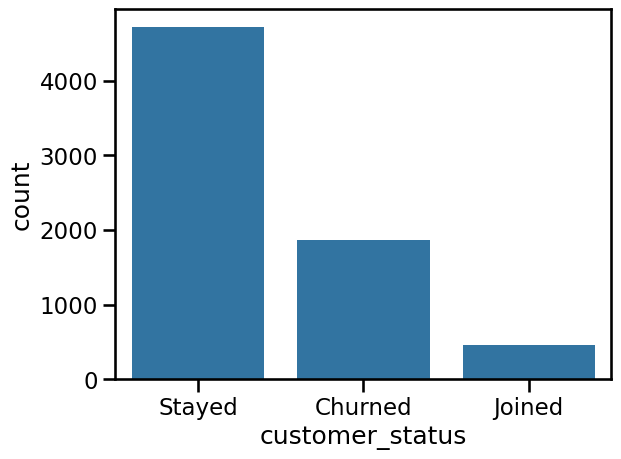

In [16]:
sns.countplot(df, x='customer_status', order = ['Stayed','Churned','Joined'])

## 2.3.9. Automatyzacja strukturyzacji

Aby zapewnić powtarzalność procesu i ułatwić wdrażanie zmian, wszystkie powyższe kroki zostały skonsolidowane wewnątrz funkcji `structurize()`. Podejście to gwarantuje, że każdy nowy zestaw danych pobrany z bazy PostgreSQL przejdzie identyczną ścieżkę transformacji.

###  Główne komponenty funkcji:

* **Logiczna Rekategoryzacja:** Zamiana mało intuicyjnych wartości (np. `None` w ofertach) na czytelne etykiety biznesowe.
* **Obsługa Braków Strukturalnych:** Wykorzystanie wyrażeń regularnych (`regex`) do identyfikacji pustych ciągów znaków w przyczynach rezygnacji.
* **Optymalizacja Geoprzestrzenna:** Zaokrąglenie współrzędnych do 5 miejsc po przecinku (~1.1 m precyzji).
* **Redukcja Szumu:** Usunięcie redundantnych identyfikatorów i stałych geograficznych (`country`, `state`).
* **Moduł Eksperymentalny:** Implementacja sztucznych braków danych (20% zbioru) w zmiennej `age` dla celów testowych.



```python
def structurize(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wykonuje pełny cykl strukturyzacji danych Telco.
    
    Proces obejmuje: rekategoryzację ofert, obsługę braków w churnie, 
    precyzję współrzędnych, redukcję wymiarowości oraz symulację braków MCAR.
    """
    
    # 1. Rekategoryzacja ofert i usług internetowych
    df.loc[df['offer'] == 'None', 'offer'] = "Offer wasn't made"
    df.loc[df['internet_service'] == 'No', 'internet_type'] = 'No internet'

    # 2. Obsługa ukrytych braków (puste stringi) przy użyciu Regex
    # Jeśli klient nie odszedł, przypisujemy mu etykietę 'did not churn'
    df['churn_category'] = df['churn_category'].apply(lambda x: 'did not churn' if re.match(r'^\s*$', str(x)) else x)
    df['churn_reason'] = df['churn_reason'].apply(lambda x: 'did not churn' if re.match(r'^\s*$', str(x)) else x)

    # 3. Standaryzacja współrzędnych geograficznych (precyzja ~1m)
    df['longitude'] = round(df['longitude'].astype('Float64'), 5)
    df['latitude'] = round(df['latitude'].astype('Float64'), 5)

    # 4. Usunięcie kolumn redundantnych i o zerowej wariancji
    drop_cols = ['country', 'state', 'quarter', 'location_id', 'service_id', 'status_id']
    df = df.drop(drop_cols, axis=1)

    # 5. Symulacja braków danych (MCAR) dla celów edukacyjnych (20% rekordów)
    np.random.seed(42) 
    idx_to_rep = np.random.randint(0, len(df), round(len(df) * 0.2))
    df['age_NA'] = df['age']
    df.loc[idx_to_rep, 'age_NA'] = np.nan

    return df
```

# 3. Proces Eksploracji i Czyszczenia Danych (EDA & Cleaning)

Sekcja ta stanowi serce analityczne projektu. Procesy eksploracji oraz czyszczenia traktowane są jako **nierozłączne i iteracyjne**. Przyjęto założenie, że skuteczne przygotowanie zbioru do modelowania jest możliwe wyłącznie poprzez dogłębne zrozumienie zależności zachodzących między cechami.

### Synergia EDA i Preprocessingu
Właściwe czyszczenie danych to coś więcej niż usuwanie błędów – to świadome kształtowanie zbioru w oparciu o wiedzę statystyczną:

1. **Wykrywanie anomalii:** Identyfikacja wartości odstających (*outliers*), które mogą negatywnie wpływać na stabilność modeli liniowych.
2. **Analiza braków danych:** Zrozumienie mechanizmu powstawania braków (zidentyfikowane wcześniej MCAR oraz braki strukturalne) pozwala na dobór optymalnej metody imputacji.
3. **Badanie korelacji:** Wykrycie współliniowości cech, co pozwala uniknąć redundancji informacji w modelu.



***


## 3.0.1 Wczytanie wstępnie przygotowanego zbioru

In [17]:

df= structurize(df)
# Uruchamiając kod lokalnie należy odkomentować poniższe 
# df_ori = pd.read_csv('../data/processed_data/structured_data.csv')
# df = df_ori.copy()

Liczba rekordów po usunięciu nowych klientów: 6589


In [18]:
age = df['age'] # Zapisanie orginalnego wieku w celach naukowych do oceny imputacji (W realnych warunkach nie byłoby to możliwe )
df.drop(['age'], axis=1,inplace=True)   # Usunięcie wieku bez braków z bazy 

churn_map = {'No':0,
             'Yes':1}
df['target'] = df['churn_label'].map(churn_map) # Utworzenie numerycznej zmiennej y - zmienna objaśniana modelu 


## 3.0.2. Podział zbioru i prewencja wycieku danych (Target Leakage)

Przed przystąpieniem do głębokiej analizy statystycznej i modelowania, zbiór danych został podzielony na część **treningową** i **testową**. Jest to kluczowy krok dla zapewnienia obiektywnej oceny modelu.

#### Czym jest Target Leakage (Przeciek Zmiennej Celowej)?
Target Leakage występuje wtedy, gdy do modelu trafiają informacje, które w świecie rzeczywistym nie byłyby dostępne w momencie dokonywania predykcji.

* **Przykład:** Włączenie kolumny `Churn Reason` (powód odejścia) do cech uczących. Jeśli znamy powód odejścia, to wiemy na 100%, że klient odszedł. Model zamiast uczyć się wzorców, po prostu "odczytuje" wynik z tej kolumny.
* **Skutek:** Model wykazuje niemal 100% skuteczności na danych historycznych, ale jest bezużyteczny w praktyce (nie potrafi przewidzieć odejścia przyszłego klienta).



#### Dlaczego eksplorację wykonujemy (głównie) na zbiorze treningowym?

1. **Unikanie stronniczości:** Jeśli podczas EDA zauważymy specyficzne wzorce w całym zbiorze i na ich podstawie zbudujemy model, to zbiór testowy przestaje być obiektywnym sprawdzianem. Podświadomie "dostosujemy" model do wzorców, które już widzieliśmy.
2. **Imputacja i Skalowanie:** Parametry takie jak średnia (do uzupełnienia wieku) czy odchylenie standardowe muszą być obliczone **tylko na zbiorze treningowym**. Następnie te same wartości aplikujemy do zbioru testowego. W ten sposób symulujemy sytuację, w której model trafia na zupełnie nowych klientów.
3. **Realizm biznesowy:** W biznesie zbiór testowy reprezentuje "przyszłość". Nie możemy znać średniej wieku klientów, którzy dopiero dołączą do firmy za miesiąc.

***
> **Decyzja projektowa:** Wszystkie decyzje dotyczące transformacji danych, imputacji braków w kolumnie `wiek` oraz inżynierii cech będą podejmowane wyłącznie na podstawie statystyk zbioru treningowego, aby zapobiec "podglądaniu" danych testowych.

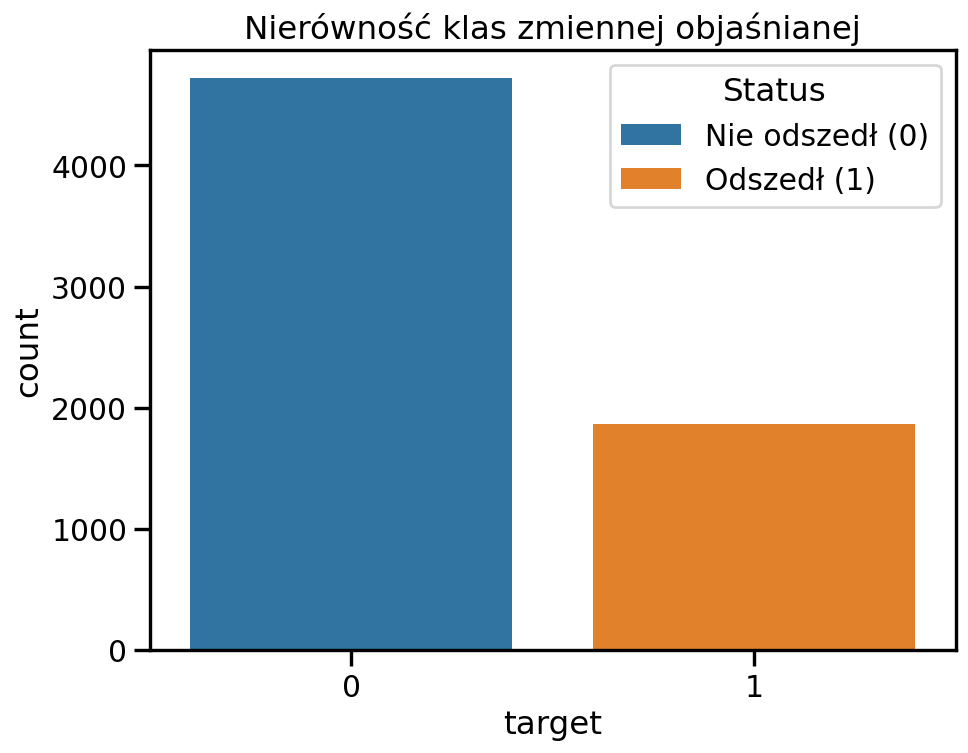

In [19]:
# Ustawienie rozmiaru wykresu i wysokiej rozdzielczości (DPI) dla lepszej jakości w raporcie
plt.figure(figsize=(8, 6), dpi=130)

# Wykres liczebności klas z podziałem kolorystycznym (hue) dla lepszej czytelności
ax = sns.countplot(data=df, x='target', hue='target')

# Definicja czytelnych etykiet dla legendy (zamiast surowych wartości 0/1)
labels = ['Nie odszedł (0)', 'Odszedł (1)']

# Pobranie uchwytów (obiektów graficznych) z wykresu, aby przypisać im nowe opisy
h, l = ax.get_legend_handles_labels()

# Konfiguracja legendy: przypisanie etykiet i nadanie tytułu sekcji
ax.legend(h, labels, title="Status")

# Tytuł wykresu informujący o braku balansu w zbiorze danych
plt.title('Nierówność klas zmiennej objaśnianej')

# Wyświetlenie gotowego wykresu
plt.show()

### Problem niezbalansowania klas a stratyfikacja

Wykres rozkładu zmiennej celowej potwierdza, że mamy do czynienia z nierównością klas. W branży telekomunikacyjnej odsetek rezygnacji jest zazwyczaj znacznie niższy niż liczba klientów lojalnych.

#### Ryzyko losowego podziału
Przy standardowym podziale losowym istnieje wysokie prawdopodobieństwo, że:

* Do zbioru testowego trafi zbyt mała liczba przypadków pozytywnych (klientów, którzy odeszli).
* Model nie będzie miał na czym rzetelnie "sprawdzić" swojej skuteczności w wykrywaniu odejścia.
* Wyniki metryk takich jak *Precyzja* czy *Recall* będą obarczone dużym błędem statystycznym.

#### Rozwiązanie: Stratyfikacja (Stratified Split)
Zastosowano podział ze stratyfikacją, który wymusza, aby **proporcja klas w zbiorze treningowym, testowym oraz walidacyjnym była identyczna z proporcją w zbiorze pierwotnym**


## 3.0.3. Trójstopniowa Strategia Podziału Danych

W celu zapewnienia najwyższej wiarygodności wyników oraz uniknięcia optymistycznego obciążenia ocen, zbiór danych został podzielony na trzy niezależne części. Pozwala to na całkowitą izolację danych, na których model będzie oceniany ostatecznie.

### Struktura i przeznaczenie zbiorów:

| Zbiór | Udział | Rola w projekcie |
| :--- | :--- | :--- |
| **Treningowy (Train)** | ~80% | Podstawa do nauki algorytmów i dopasowywania wag modelu. Na tym zbiorze wykonywana jest większość EDA. |
| **Walidacyjny (Dev)** | ~15% | Wykorzystywany do strojenia hiperparametrów, wyboru architektury i wczesnego wykrywania przetrenowania. |
| **Testowy (Test)** | ~5% | **"Zbiór zamknięty"**. Użyty wyłącznie raz na samym końcu projektu do finalnej weryfikacji zdolności generalizacji. |

### Implementacja techniczna (funkcja)

```python
def train_dev_test_split(df: pd.DataFrame, rs: int) -> tuple:
    """
    Dzieli dane na trzy zestawy (treningowy, walidacyjny, testowy) z zachowaniem 
    stratyfikacji, aby zapewnić równe proporcje klas 0 i 1 w każdej próbce.

    Funkcja wykorzystuje moduł sklearn.model_selection.train_test_split. 
    Stratyfikacja zmiennej celowej pozwala uniknąć problemów wynikających 
    z niezbalansowania klas.

    Argumenty:
        df (pd.DataFrame): Wejściowa ramka danych.
        rs (int): Ziarno losowości (random_state) dla powtarzalności wyników.

    Zwraca:
        tuple: Krotka zawierająca ramki danych (X_train, X_dev, X_test, y_train, y_dev, y_test).
    """
    # Usunięcie zmiennych celowych i pomocniczych z cech (features)
    X = df.drop(['target', 'churn_label'], axis=1)
    y = df['target']
    
    # Pierwszy podział: Wydzielenie zbioru treningowego (80%) i tymczasowego (20%)
    X_train, X_s, y_train, y_s = train_test_split(
        X, y, test_size=0.2, random_state=rs, stratify=y
    )
    
    # Drugi podział: Podział zbioru tymczasowego na walidacyjny (15% całości) i testowy (5% całości)
    # test_size=0.25 z 20% daje 5% całości dla X_test
    X_dev, X_test, y_dev, y_test = train_test_split(
        X_s, y_s, test_size=0.25, random_state=rs, stratify=y_s
    )
    
    return X_train, X_dev, X_test, y_train, y_dev, y_test
```

In [20]:
X_train, X_dev, X_test, y_train, y_dev, y_test = train_dev_test_split(df, RANDOM_STATE)
train = pd.concat([X_train, y_train], axis=1) # Połączenie z targetem do celów eksploracyjnych

## 3.1.1. Automatyzacja Eksploracji: Analiza Cech Ilościowych i Jakościowych

Aby zidentyfikować kluczowe czynniki wpływające na rezygnację, wdrożono zautomatyzowany proces wizualizacji. Pozwala on na równoległą ocenę statystyk opisowych oraz ich bezpośredniego przełożenia na wskaźnik churnu (*Churn Rate*).

#### Cechy Ilościowe 
Dla każdej zmiennej numerycznej generowany jest histogram z podwójną osią Y:

* **Oś Y1 (Liczebność):** Pokazuje rozkład danej cechy w populacji treningowej.
* **Oś Y2 (Średni prawdopodobieństwo odejścia):** Naniesiona linia trendu pokazująca, jak prawdopodobieństwo odejścia zmienia się wraz ze wzrostem wartości cechy (np. czy wyższy wiek lub wyższe opłaty korelują z wyższym chprurnem).



#### Cechy Jakościowe 
Dla zmiennych kategorycznych generowane są wykresy liczebności (*Count Plots*) z podziałem na klasy zmiennej zależnej:

* **Kolorystyka :** Pozwala natychmiastowo ocenić proporcję osób odchodzących w ramach danej kategorii 
* **Interpretacja:** Szukamy kategorii, w których "słupek" osób odchodzących (Target=1) jest nienaturalnie wysoki w stosunku do osób zostających.



***

> **Widoczność wykresu mocno zależy od środowiska (IDE) oraz ekranu, na którym otwierany jest raport. Nie mamy na to niestety wpływu**

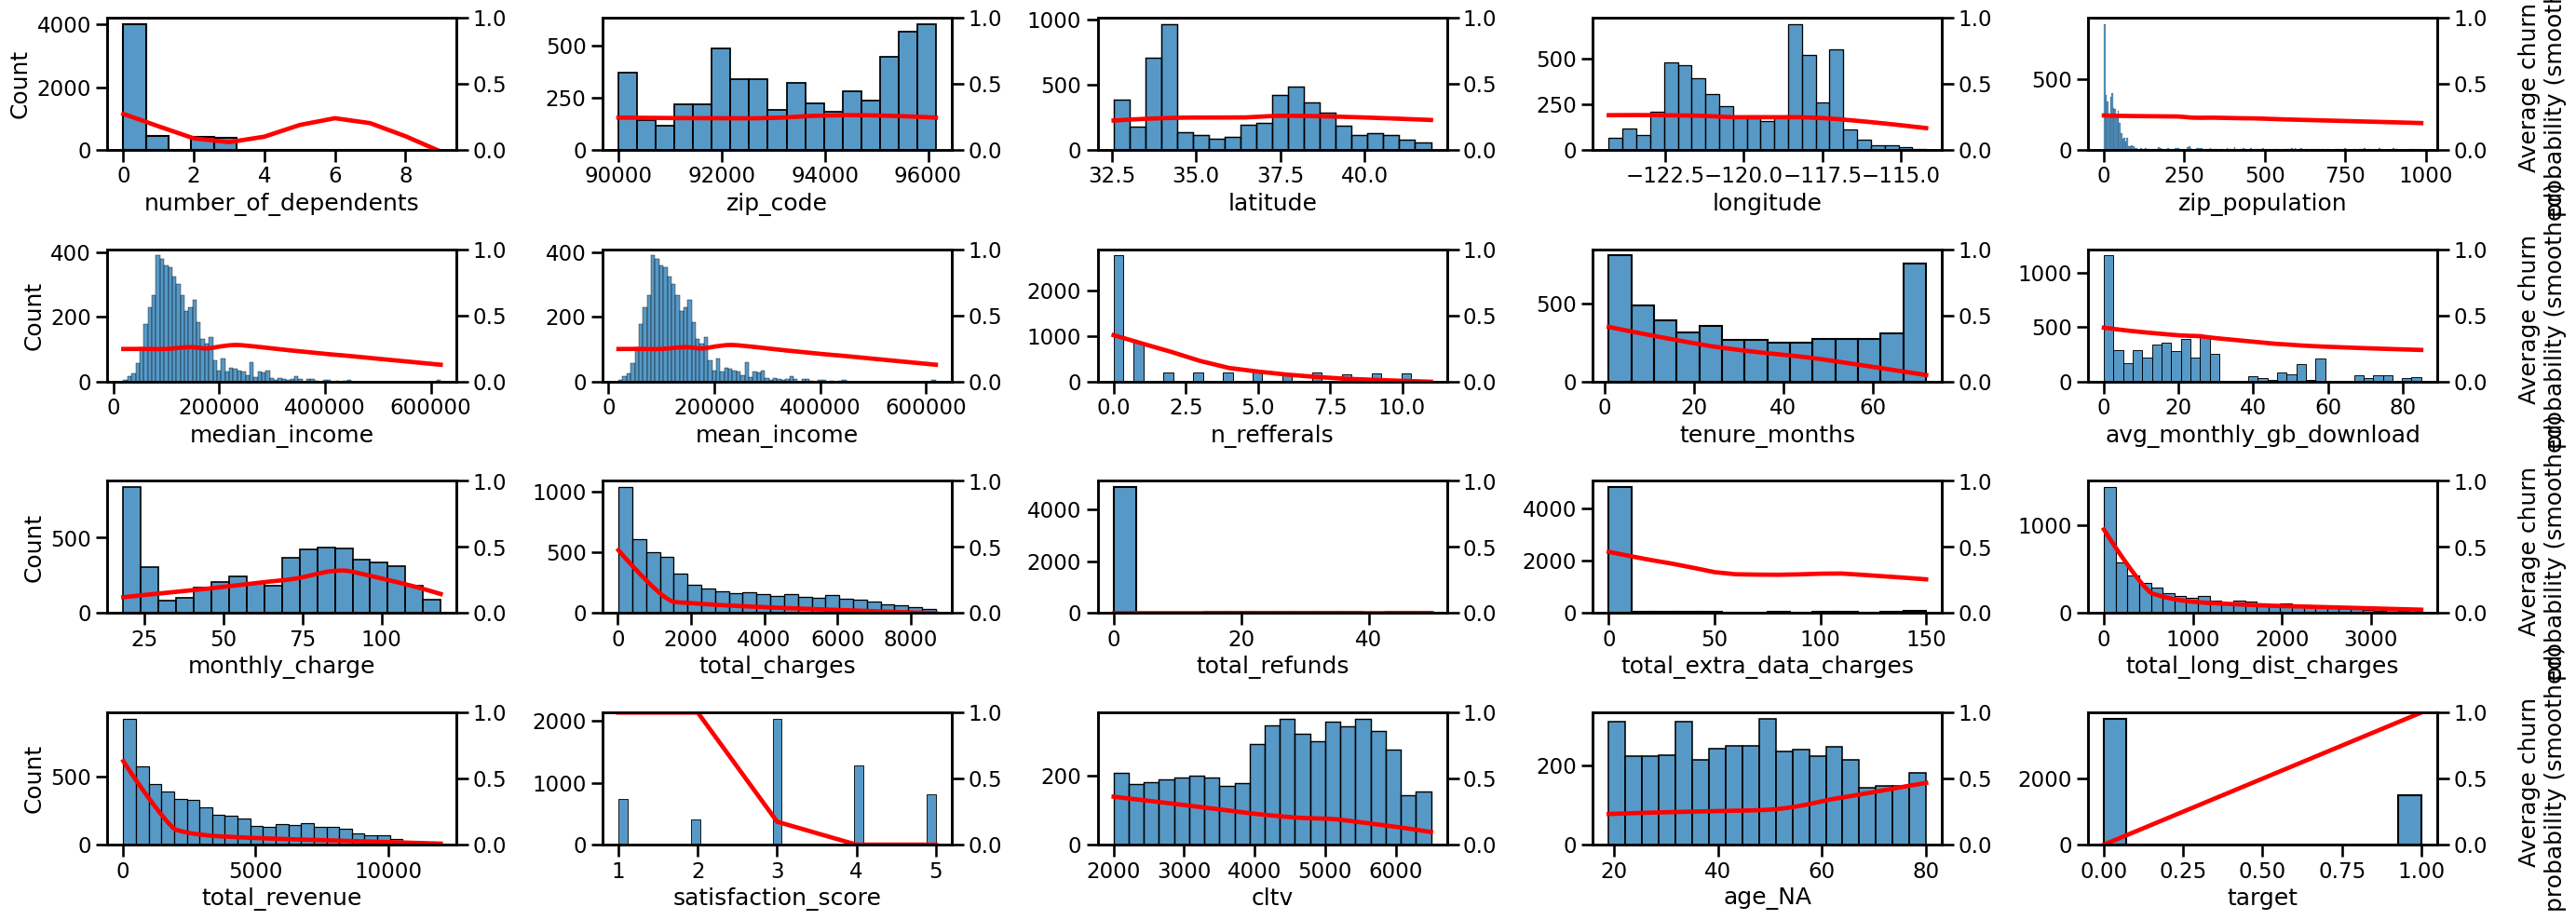

In [21]:
# Wyłonienie kolumn numerycznych (typu całkowitego i zmiennoprzecinkowego) ze zbioru treningowego
numeric_columns = [col for col in train.columns if train[col].dtype in ['int64', 'float64']]

plt.figure(figsize=(28,12))
plt.subplots_adjust(wspace=0.4) # Zwiększenie odstępów poziomych między wykresami

for i, x in enumerate(numeric_columns):
    plt.subplot(5, 5, i+1) 
    
    # Wyświetlenie histogramu rozkładu danej zmiennej
    sns.histplot(train[x])
    
    # Obliczenie średniego prawdopodobieństwa odejścia dla każdej wartości zmiennej
    group_mean = train.groupby(train[x])['target'].mean()
    
    # Tworzenie drugiej osi Y dla prawdopodobieństwa (dzielenie wspólnej osi X)
    ax = plt.gca()
    ax2 = ax.twinx()
    
    # Nałożenie wygładzonej linii regresji (LOWESS) pokazującej trend churnu
    sns.regplot(x=group_mean.index, y=list(group_mean), lowess=True, scatter=False, color='red')
    
    # Ujednolicenie skali prawdopodobieństwa od 0 do 1 dla wszystkich wykresów
    ax2.set_ylim(0, 1)
    
    # Logika czyszczenia opisów osi dla poprawy czytelności siatki
    if i % 5 == 0:
        ax.set_ylabel('Count') # Opis osi Y tylko dla pierwszej kolumny
    else:
        ax.set_ylabel('')
        
    if (i+1) % 5 == 0 or i == len(numeric_columns)-1:
        ax2.set_ylabel('\nAverage churn \nprobability (smoothed)') # Opis osi prawdopodobieństwa tylko z prawej strony
    
plt.tight_layout() # Automatyczne dopasowanie elementów, aby uniknąć nakładania się napisów

In [22]:
# W celu lepszej widocznosci mozna zapisac wykres
# plt.savefig('../report_materials/num_plot.png')

###  Wnioski z wstępnej analizy zmiennych numerycznych

Wstępna analiza graficzna (histogramy z nałożonym współczynnikiem churnu) pozwoliła na zidentyfikowanie kluczowych trendów oraz sygnałów predykcyjnych. Poniżej przedstawiono syntezę najważniejszych odkryć:

#### Trendy Geograficzne i Demograficzne

* **Wpływ lokalizacji:** Odnotowano nieznaczną zależność między współrzędnymi geograficznymi a rezygnacją. Dane wskazują, że prawdopodobieństwo churnu nieco maleje wraz z przemieszczaniem się na wschód (długość geograficzna).
* **Status materialny:** Mediana i średni dochód w regionie zamieszkania nie wskazują na związek z odejściem.
* **Struktura wieku:** Analiza zmiennej `age` (mimo wprowadzonych braków) wskazuje na grupę seniorów jako segment o podwyższonym ryzyku. Sugeruje to potrzebę opracowania dedykowanych programów, które zwiększą szansę retencji klientów w grupie osób starszych. Ponadto należy pamiętać o naturalnie podwyższonym ryzyku odejścia od usług z przyczyn naturalnych.



#### Czynniki finansowe i konsumpcyjne

* **Koszty miesięczne (`monthly_charge`):** Prawdopodobieństwo odejścia klienta rośnie do wraz ze wzrostem wartości miesięcznego abonamentu (Do wartości ok. 90 dolarów za miesiąc, powyżej tej wartości prawdopodobieństwo odejścia gwałtownie spada). Relacja ta jest zrozumiała. Klienci płacący mało mają niskie oczekiwania. Wraz ze wzrostem opłat oczekiwania rosną co może powodować napięcia na lini klient - firma. Klienci płacący najwęcej mają wysoie oczekiwania ale również w teori najwyższą jakość usług. Dodatkowo klienci decydujący się na najdroższe usługi prawdopodobnie wiedzą czego potrzebują więc łatwiej jest zaspokoić ich potrzeby.
* **Wartość klienta (`cltv`):** Zmienna Customer Lifetime Value wykazuje silną, relację liniową z prawdopodobiuństwem odejścia, co potwierdza jej wartość jako miary stabilności klienta.
* **Dodatkowe opłaty:** Większość klientów cechuje się niską wartością generowanych kośtów za użycie danych poza granicami obowiązującego abonamentu. (`total_long_dist_charges`). Respondenci, generujący wysokie koszty z tego tytułu mają średnio zdecydowanie niższe prawdopodobieństwo odejścia. 

#### Lojalność i zaangażowanie

* **Program poleceń (`n_referrals`):** Liczba poleceń wykonanych przez klienta jest odwrotnie proporcjonalna z prawdopodobieństwem odejścia – aktywni promotorzy marki odchodzą rzadziej.
* **Staż (`tenure_months`):** Potwierdzono klasyczną zależność – im dłuższy staż klienta, tym większe prawdopodobieństwo jego pozostania.

***

### Ważna uwaga metodologiczna: Wykluczenie Satisfaction Score z procesu modelowania (zmienna będzie wykorzystana do zbadnania co wpływa na tak niską ocenę)

Mimo że zmienna **`satisfaction_score`** wykazuje krytyczny wpływ na churn (biznesowe "akceptowalne minimum" punktowe wynosi 3), zdecydowano o **wykluczeniu jej z procesu modelowania**. Zmienna indywidualnie różnicuje zbiór niemal perfekcyjnie

* **Uzasadnienie:** Dane te prawdopodobnie zostały pozyskane w drodze ankiet po wystąpieniu zdarzenia rezygnacji. 
* **Ryzyko:** Użycie tej zmiennej stanowiłoby klasyczny wyciek informacji z przyszłości. W scenariuszu produkcyjnym nie dysponujemy oceną satysfakcji za okres, który dopiero ma nastąpić. Naszym celem jest modelowanie przyszłości na podstawie dostępnych danych historycznych, a nie opisywanie teraźniejszości.

***
> **Podsumowanie techniczne:** Większość zidentyfikowanych cech wykazuje nieliniowe zależności, co sugeruje, że algorytmy oparte na drzewach decyzyjnych (np. Random Forest, XGBoost) mogą przynieść lepsze rezultaty niż proste modele regresyjne.

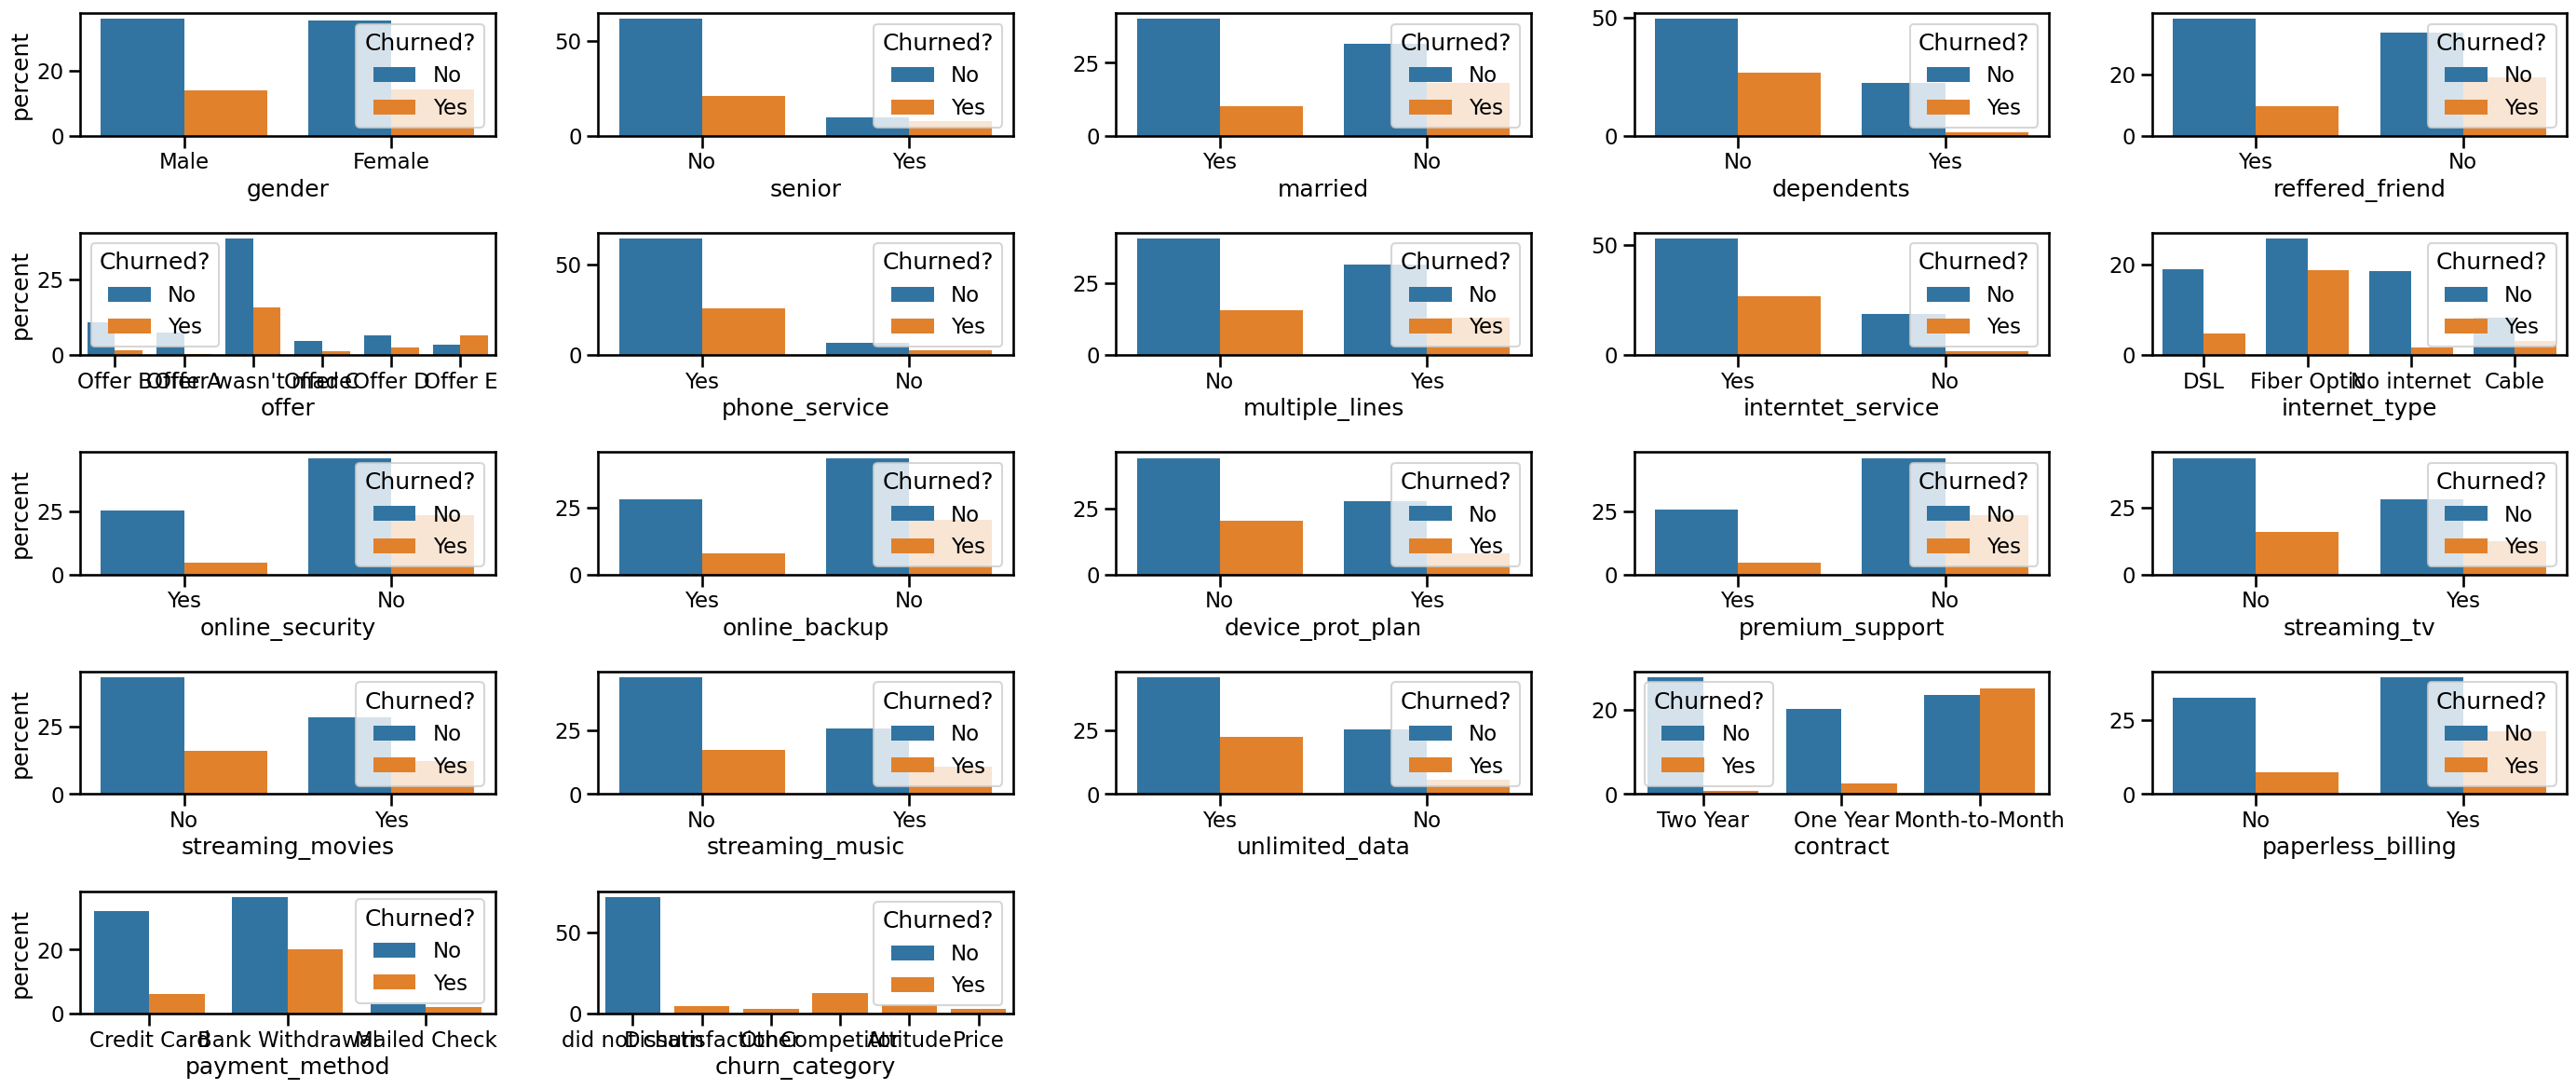

In [23]:
# Wybór kolumn kategorycznych (nie-numerycznych), z pominięciem identyfikatorów i lokalizacji
categorical_columns = [col for col in train.columns if train[col].dtype not in ['int64', 'float64'] and col not in ['customer_id', 'zip_code', 'city', 'churn_reason']]

# Sortowanie kolumn według liczby unikalnych wartości (od największej liczby kategorii)
categorical_cacolumns = train.loc[:, categorical_columns].nunique().sort_values(ascending=False).index

fig = plt.figure(figsize=(28, 12))
plt.subplots_adjust(wspace=0.4) # Odstępy między kolumnami wykresów

for i, x in enumerate(categorical_columns):
    ax = plt.subplot(5, 5, i+1) 
    
    # Wykres słupkowy pokazujący procentowy udział churnu w każdej kategorii
    sns.countplot(train, x=x, hue='target', stat='percent')
    
    # Ustawienie czytelnej legendy (0: No, 1: Yes)
    ax.legend(title='Churned?', labels=['No', 'Yes'])
    
    # Wyświetlanie opisu osi Y tylko dla wykresów w pierwszej kolumnie siatki
    if i % 5 == 0:
        ax.set_ylabel('percent')
    else:
        ax.set_ylabel('')

# Automatyczne wyrównanie elementów wykresu
fig.tight_layout()

In [24]:
# W celu lepszej widocznosci mozna zapisac wykres
# fig.savefig('../report_materials/cat_plot.png')

### Wnioski z wstępnej analizy zmiennych kategorycznych

Poniżej przedstawiono kluczowe obserwacje wynikające z analizy eksploracyjnej zbioru danych Telco:

#### Kluczowe czynniki rezygnacji 

* **Konkurencja:** Głównym powodem rezygnacji wskazywanym przez konsumentów są działania konkurencji.
* **Oferta E:** Należy poddać szczegółowej analizie Ofertę E. Ponad połowa klientów, którzy ją otrzymali, zdecydowała się na rezygnację z usług.
* **Technologia światłowodowa:** Użytkownicy światłowodów (Fiber Optic) wykazują zaskakująco wysoki wskaźnik rezygnacji. Jest to zjawisko niepokojące, biorąc pod uwagę, że jest to najbardziej zaawansowana technologia internetowa w ofercie.

#### Charakterystyka demograficzna

* **Płeć:** Zmienna ta nie różnicuje zbioru w kontekście rezygnacji. Rozkłady dla kobiet i mężczyzn są niemal identyczne, co sugeruje brak wpływu płci na lojalność klienta.
* **Seniorzy:** Analiza potwierdza, że w grupie seniorów odsetek rezygnacji jest znacznie wyższy, co pokrywa się z rozkładem zmiennej wieku.
* **Status cywilny i osoby na utrzymaniu (*Dependents*):** * Osoby w związkach małżeńskich rzadziej rezygnują z usług (potencjalna przyczyna: większa stabilność życiowa i przyzwyczajenie).
    * Posiadanie **osób na utrzymaniu** (*Dependents*) znacząco obniża skłonność do odejścia. Wynika to prawdopodobnie z faktu, że zmiana operatora w przypadku współdzielenia usług przez większą grupę domowników jest bardziej uciążliwa logistycznie (np. Zmiana numerów w całej rodzinie w przypadku zmiany operatora).

#### Usługi dodatkowe i pakiety

* **Usługi Premium:** Klienci, którzy **nie korzystają** z usług dodatkowych (takich jak *Ochrona urządzeń*, *Premium wsparcie techniczne* czy *Dodatkowa ochrona w internjecie*), odchodzą rzadziej. Sugeruje to potrzebę poprawy jakości usług bazowych lub stworzenia lepszych programów lojalnościowych zachęcających do korzystania z usług premium.
* **Nielimitowane dane:** Osoby z pakietami nielimitowanymi oraz wysokimi wydatkami miesięcznymi częściej rezygnują. Można wysnuć wniosek, że są to **klienci o wysokich wymaganiach**, którzy aktywnie poszukują najlepszej oferty na rynku. Co prawda nie pokrywa się to z wnioskami dla dodatkowych usług, które niewątpliwie również podnoszą miesięczne opłaty

#### Aspekty kontraktowe i płatności
* **Typ umowy:** Największy wskaźnik odejść generują umowy miesięczne, co wynika z niskiej bariery wyjścia. Klienci na kontraktach rocznych i dwuletnich rezygnują marginalnie (odpowiednio ok. 4% i poniżej 1%). 
    * **Rekomendacja:** Zachęcenie klientów do zawierania długoterminowych usług.
* **Metoda płatności:** * Osoby korzystające z faktur elektronicznych są bardziej skłonne do rezygnacji.
    * Wyższy odsetek rezygnacji odnotowano u osób płacących poprzez wyciąg z banku oraz czekiem w porównaniu do płatności kartą kredytową.
***

## 3.1.2. Szczegółowa analiza wybranych zmiennych 
W tym rozdziale przeprowadzona zostanie szczegółowa analiza zmiennych, które na podstawie wykresów dla zmiennych kategorycznych oraz numerycznych wykazują silny związek z prawdopodobieństwem odejścia.

***

### Typ internetu (var. Internet_type)

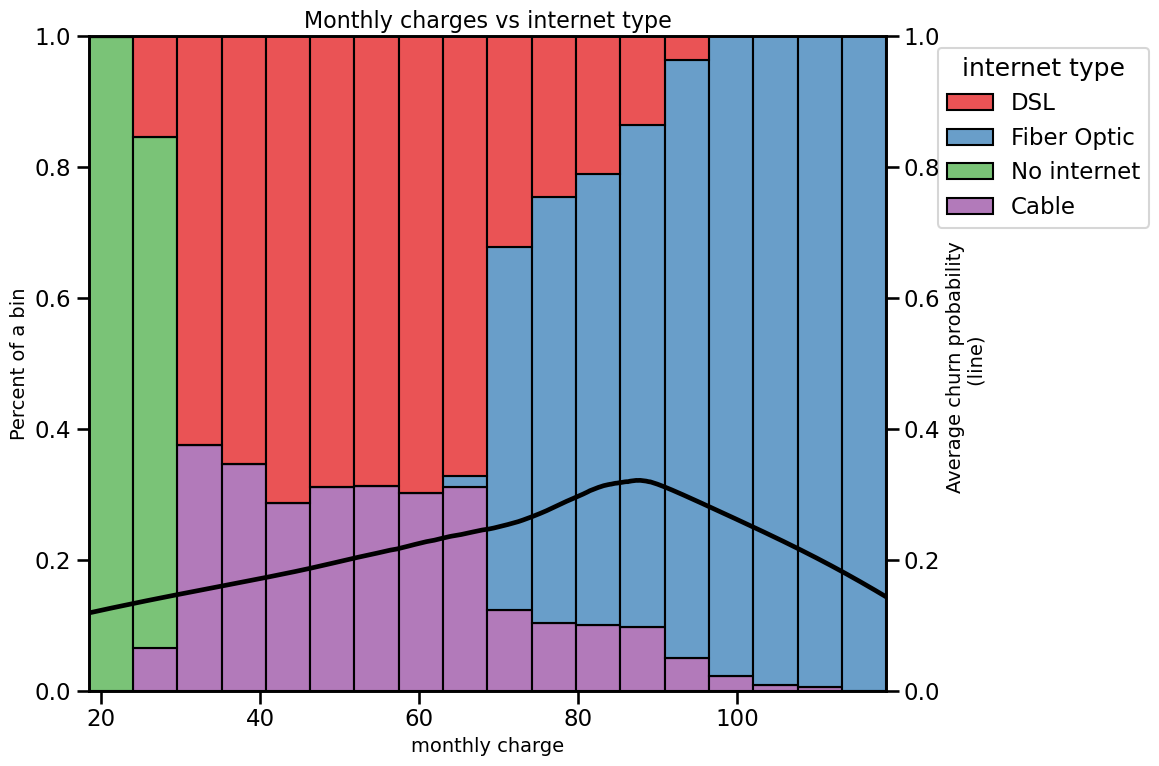

In [25]:
plt.figure(figsize=(12, 8))

# Histogram skumulowany (multiple='fill') pokazujący strukturę typu internetu 
# w zależności od wysokości opłat miesięcznych (stat='percent')
ax = sns.histplot(data=train, x='monthly_charge', hue='internet_type', 
                  multiple='fill', stat='percent', legend=True, palette='Set1')

# Przesunięcie legendy poza obszar wykresu, aby nie zasłaniała danych
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1.05, 1), title='internet type')

# Obliczenie średniego prawdopodobieństwa churnu dla każdej wartości opłaty
group_mean = train.groupby(train['monthly_charge'])['target'].mean()

# Dodanie drugiej osi Y dla trendu prawdopodobieństwa churnu
ax1 = plt.gca()
ax2 = ax1.twinx()

# Nałożenie wygładzonej linii trendu (LOWESS) obrazującej ryzyko odejścia (czarna linia)
sns.regplot(x=group_mean.index, y=list(group_mean), lowess=True, scatter=False, color='Black')

# Konfiguracja etykiet osi i tytułu wykresu
ax.set_ylabel('Percent of a bin', fontsize=14)
ax.set_xlabel('monthly charge', fontsize=14)
ax2.set_ylabel('Average churn probability \n (line)', fontsize=14)
ax2.set_ylim(0, 1) # Ujednolicenie zakresu osi prawdopodobieństwa do [0, 1]

plt.title('Monthly charges vs internet type', fontsize=16)
plt.tight_layout()

In [26]:
train.groupby('internet_type')['target'].agg('mean')

internet_type
Cable          0.276667
DSL            0.200321
Fiber Optic    0.420784
No internet    0.084651
Name: target, dtype: float64

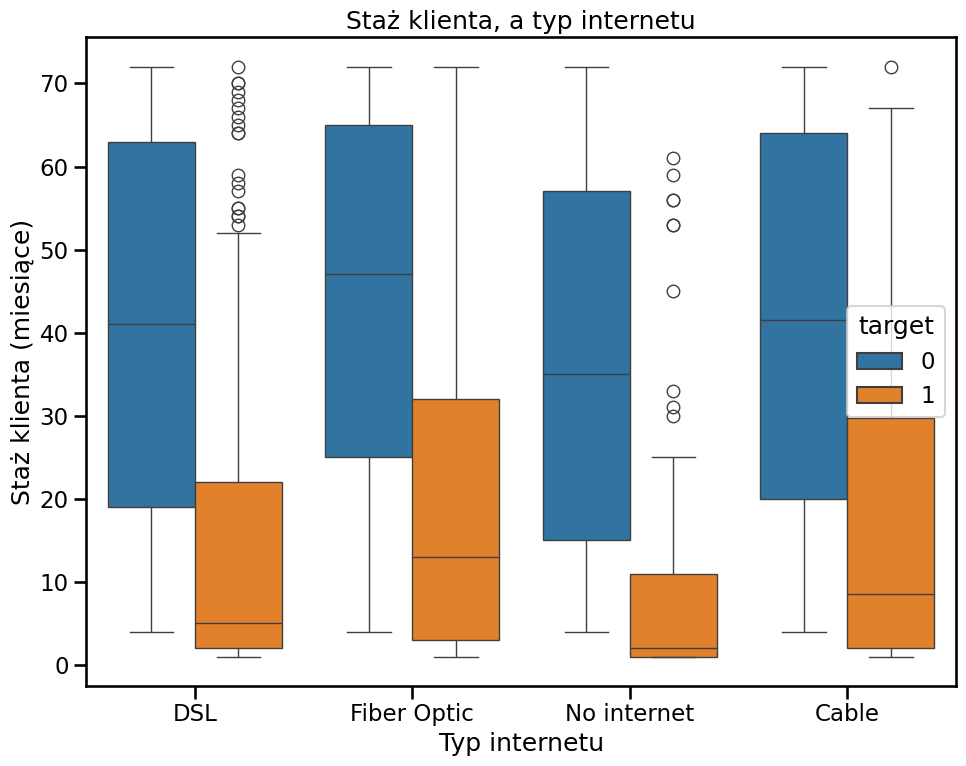

In [27]:
# Ustawienie rozmiaru wykresu dla zachowania proporcji w raporcie
plt.figure(figsize=(10, 8))

# Wykres pudełkowy (boxplot) analizujący staż klienta (tenure) 
# w zależności od typu internetu i statusu rezygnacji (hue='target')
sns.boxplot(data=train, x='internet_type', y='tenure_months', hue='target')

# Tytuł wykresu 
plt.title('Staż klienta, a typ internetu')
# Opis osi X - kategoria technologii internetowej
plt.xlabel('Typ internetu')

# Opis osi Y - liczba miesięcy spędzonych przez klienta w firmie
plt.ylabel('Staż klienta (miesiące)')

# Optymalizacja rozkładu elementów wykresu, aby uniknąć ucinania etykiet
plt.tight_layout()

#### Wnioski: Typ połączenia internetowego (Internet Type)

Analiza zmiennej dotyczącej rodzaju świadczonych usług internetowych pozwoliła na wyciągnięcie następujących kluczowych wniosków:

* **Struktura wydatków a technologia:** Klienci, których miesięczne zobowiązania przekraczają **65 USD**, to niemal wyłącznie użytkownicy światłowodów. Potwierdza to, że technologia ta jest pozycjonowana jako produkt premium.
* **Dominacja rynkowa:** Światłowód jest najczęściej wybieranym typem połączenia spośród wszystkich dostępnych opcji w ofercie operatora.
* **Retencja użytkowników światłowodu:** Dane wskazują na problem z lojalnością w tym segmencie — **75% osób** rezygnujących z usług światłowodowych decyduje się na ten krok przed upływem **32 miesięcy** (trzeci kwartyl czasu trwania umowy). **50% osób** rezygnuje przed upływem roku. W
* **Potencjał predykcyjny:** Ze względu na wyraźne różnice w zachowaniach klientów korzystających z różnych technologii, zmienna ta posiada wysoką moc rozdzielczą. 
* **Kodowanie zmiennej** Zmienna jest doskonałym kandydatem do zastosowania **Target Encodingu** w fazie przygotowania danych do modelowania maszynowego.

#### Usługi premium

* Dodatkowa ochrona online (var. online_security)
* Dodatkowy backup online (var. online_backup)
* Dodatkowy plan ochrony urządzeń (var. device_prot_plan)
* Wsparcie premium (var. premium_support)

***


In [28]:
# Lista kolumn do sprawdzenia
cols_to_check = ['online_security', 'online_backup', 'device_prot_plan', 'premium_support']

# 1. Sprawdzamy, gdzie jest 'Yes' (wynik: True/False)
# 2. Sumujemy wartości True wierszami (.sum(axis=1)) - True liczone jest jako 1
# 3. Wybieramy wiersze, gdzie suma jest większa lub równa 2
mask = (train[cols_to_check] == 'Yes').sum(axis=1) >= 3

result = train[mask]

# Wyświetlenie wyniku
result['target'].mean()

# Utworzenie zmiennej
train['premium_services'] = ((train[cols_to_check] == 'Yes').sum(axis=1) >= 3).astype(int)

In [29]:
train.groupby('premium_services')['target'].agg('mean')

premium_services
0    0.332693
1    0.099278
Name: target, dtype: float64

####  Wnioski: Usługi premium
 Klienci, którzy mieli wykupione conajmniej 3 z 4 usług premium rezygnowali średnio o 24 p.p rzadziej niż osoby nie korzystające z dodatkowych usług. Wskazuje to na potrzebę poprawienia jakości bazowych usług oferowanych przez operatora. 
***

### Ostatnia otrzymana oferta marketingowa (var. Offer)
***

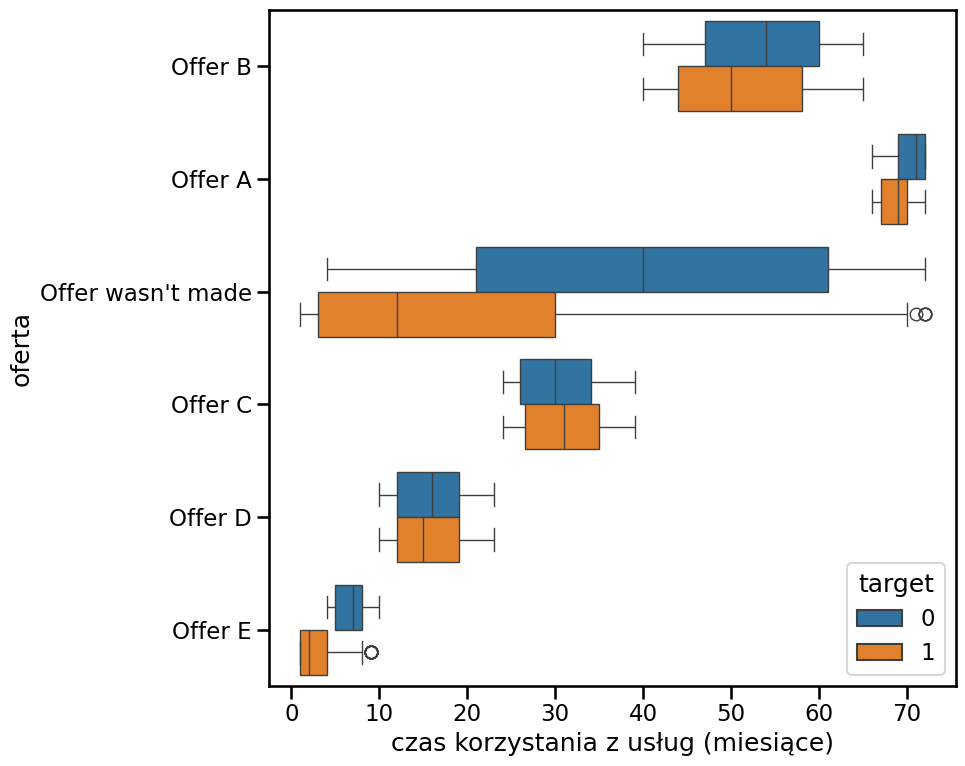

In [30]:
# Ustawienie rozmiaru wykresu (szerokość 10, wysokość 8 cali)
plt.figure(figsize=(10, 8))

# Wykres pudełkowy analizujący relację między czasem trwania umowy (tenure),
# rodzajem oferty (offer) a rezygnacją klienta (hue='target')
sns.boxplot(data=train, x='tenure_months', y='offer', hue='target')

# Opis osi X - staż klienta wyrażony w miesiącach
plt.xlabel('czas korzystania z usług (miesiące)')

# Opis osi Y - nazwa/typ przypisanej oferty
plt.ylabel('oferta')

# Automatyczne dopasowanie marginesów wykresu
plt.tight_layout()

In [31]:
round(train.groupby('offer')[['target','tenure_months']].agg('mean'), 2).sort_values(by='tenure_months')#*100//1 #Prawdopodobieństwo rezygnacji we wszystkich grupach umów

,target,tenure_months
offer,,
Offer E,0.66,4.30
Offer D,0.27,15.84
Offer C,0.23,30.54
Offer wasn't made,0.29,33.88
Offer B,0.13,53.22
Offer A,0.06,70.09


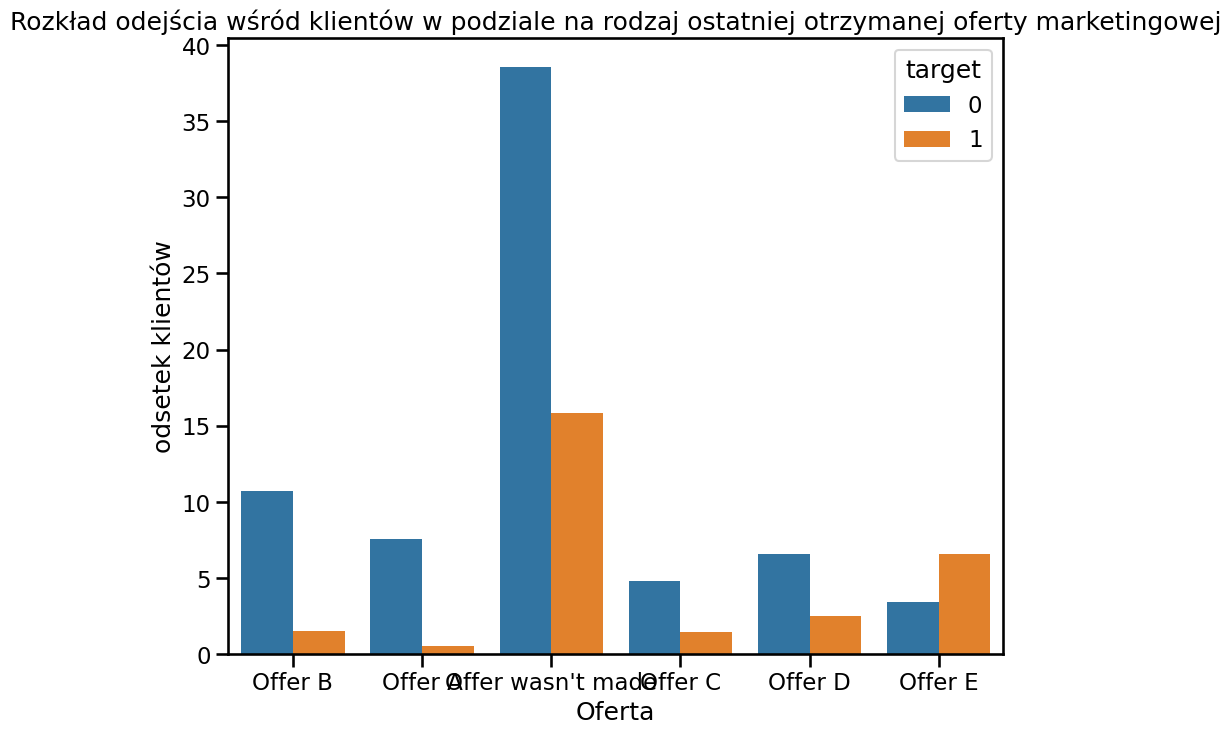

In [32]:
# Ustawienie wymiarów wykresu dla zachowania spójności z resztą raportu
plt.figure(figsize=(10, 8))

# Wykres liczebności kategorii ofert z podziałem na status rezygnacji (target)
# stat='percent' normalizuje słupki, pokazując udział procentowy zamiast surowych liczb
sns.countplot(train, x='offer', hue='target', stat='percent')

# Tytuł wyjaśniający analizowany wpływ ofert marketingowych na churn
plt.title('Rozkład odejścia wśród klientów w podziale na rodzaj ostatniej otrzymanej oferty marketingowej')

# Etykiety osi ułatwiające interpretację skali i kategorii
plt.xlabel('Oferta')
plt.ylabel('odsetek klientów')

# Wyświetlenie wykresu (w Quarto zostanie osadzony jako element raportu)
plt.show()

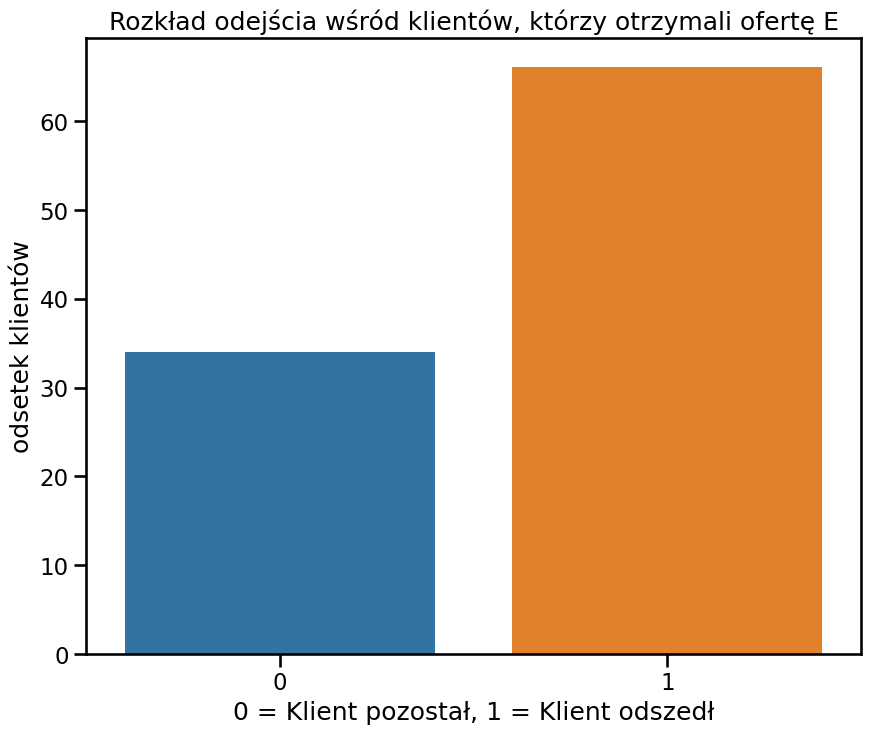

In [33]:
# Ustawienie wymiarów wykresu
plt.figure(figsize=(10, 8))

# Filtrowanie danych tylko dla 'Offer E' i przedstawienie rozkładu churnu w ujęciu procentowym
# legend=False usuwa zbędną legendę, gdyż informacja o target jest już na osi X
sns.countplot(train[train['offer'] == 'Offer E'], x='target', hue='target', stat='percent', legend=False)

# Tytuł podkreślający, że analiza dotyczy wyłącznie segmentu z ofertą E
plt.title('Rozkład odejścia wśród klientów, którzy otrzymali ofertę E')

# Precyzyjne opisy osi dla ułatwienia interpretacji wartości binarnych
plt.xlabel('0 = Klient pozostał, 1 = Klient odszedł')
plt.ylabel('odsetek klientów')

# Wyświetlenie wykresu
plt.show()

####  Wnioski: Oferty marketingowe (Offer)

Analiza skuteczności poszczególnych ofert marketingowych ujawniła istotne luki w strategii utrzymania klienta:

* **Niska penetracja działaniami marketingowymi:** Przeważająca część bazy klientów nie otrzymała żadnej dedykowanej oferty marketingowej. Sugeruje to niewykorzystany potencjał sprzedażowy oraz konieczność **zoptymalizowania wydajności działu marketingu** w zakresie kierowania ofert do obecnych użytkowników.
* **Krytyczna nieskuteczność Oferty E:**
    * Odnotowano drastycznie wysoki wskaźnik rezygnacji – ok. **65% klientów**, którzy otrrzymali ofertę E, zakończyło współpracę z operatorem.
    * Analiza wykazała, że Oferta E była kierowana wyłącznie do **nowych klientów** (ze stażem nieprzekraczającym 10 miesięcy).
    * **Wniosek:** Strategia pozyskiwania i retencji nowych użytkowników za pomocą tej konkretnej oferty jest nieskuteczna. Wymagana jest natychmiastowa rewizja warunków Oferty E lub całkowita zmiana podejścia do klientów o krótkim stażu.

    ***

### Rodzaj umowy (var. Contract)

In [34]:
print(f"Odsetek osób, które zrezygnowały ze współpracy na umowach miesięcznych: {round(train[train['contract']=='Month-to-Month']['target'].value_counts()[1]/train['target'].value_counts()[1],2)}")

Odsetek osób, które zrezygnowały ze współpracy na umowach miesięcznych: 0.89


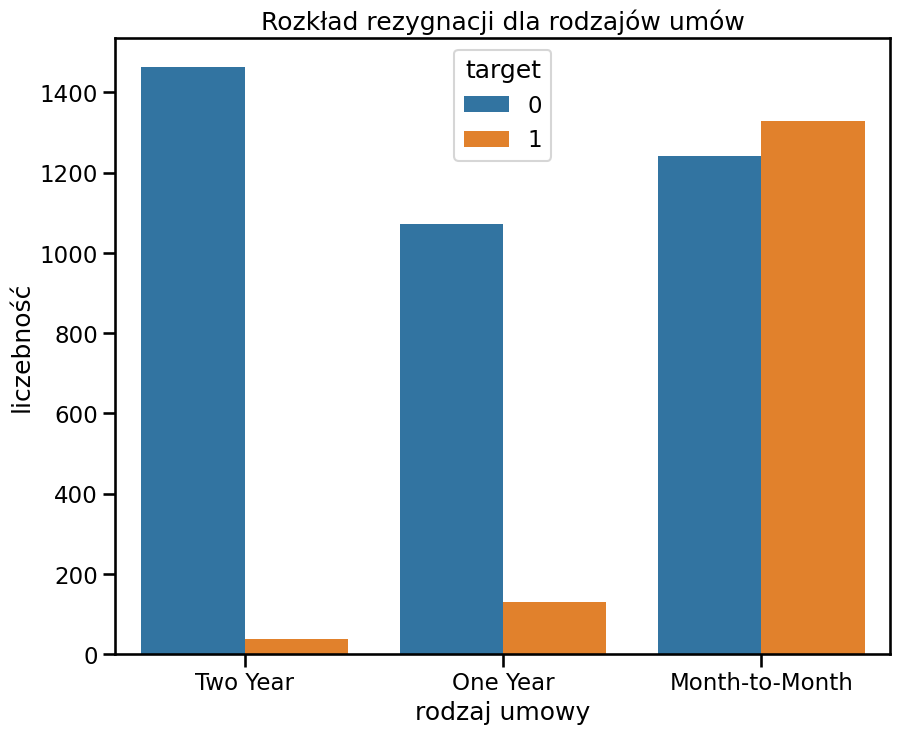

In [35]:
# Ustawienie wymiarów wykresu
plt.figure(figsize=(10, 8))

# Wykres liczebności klas z podziałem na rodzaj umowy (contract) oraz status odejścia (target)
# Porównanie surowych liczb pozwala ocenić skalę biznesową każdego segmentu
sns.countplot(data=train, x='contract', hue='target')

# Opis osi X - typ zawartej umowy (np. Month-to-month, One year, Two year)
plt.xlabel('rodzaj umowy')

# Opis osi Y - całkowita liczba klientów w każdej podgrupie
plt.ylabel('liczebność')

# Tytuł wskazujący na analizę stabilności klientów w zależności od typu kontraktu
plt.title('Rozkład rezygnacji dla rodzajów umów')

# Wyświetlenie wykresu w raporcie
plt.show()

In [36]:
train.groupby('contract')['target'].agg('mean')*100//1 #Prawdopodobieństwo rezygnacji we wszystkich grupach umów

contract
Month-to-Month    51.0
One Year          10.0
Two Year           2.0
Name: target, dtype: float64

Text(0, 0.5, '')

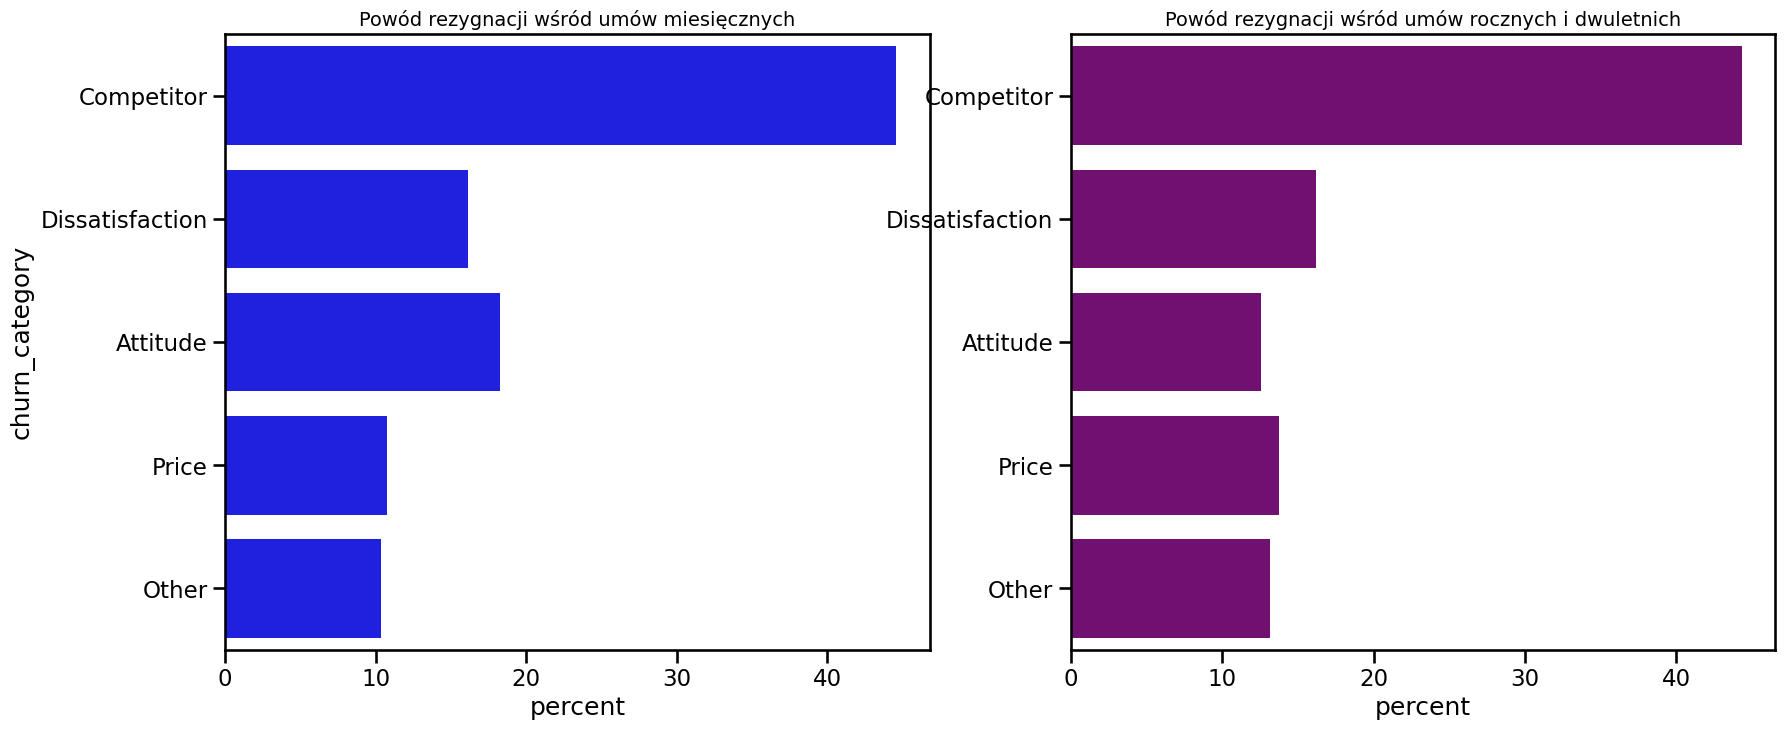

In [37]:
# Filtrowanie danych: wybór tylko klientów z umowami miesięcznymi (najbardziej rotujący segment)
m2m = train[train['contract'] == 'Month-to-Month']

# Tworzenie siatki dwóch wykresów obok siebie dla bezpośredniego porównania grup
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# Wykres 1: Procentowy rozkład powodów odejścia dla umów krótkoterminowych (Month-to-Month)
sns.countplot(data=m2m[m2m['target'] == 1], y='churn_category', 
              order=['Competitor', 'Dissatisfaction', 'Attitude', 'Price', 'Other'], 
              ax=ax[0], color='blue', stat='percent')

# Wykres 2: Procentowy rozkład powodów odejścia dla umów lojalnościowych (1 rok i 2 lata)
sns.countplot(data=train[(train['target'] == 1) & (train['contract'] != 'Month-to-Month')], 
              y='churn_category', order=['Competitor', 'Dissatisfaction', 'Attitude', 'Price', 'Other'], 
              ax=ax[1], color='purple', stat='percent')

# Konfiguracja tytułów i estetyki osi dla obu podwykresów
ax[0].set_title('Powód rezygnacji wśród umów miesięcznych', fontsize=14)
ax[1].set_title('Powód rezygnacji wśród umów rocznych i dwuletnich', fontsize=14)
ax[1].set_ylabel('') # Usunięcie powtarzającej się etykiety osi Y dla czystości wykresu

#### Wnioski: Rodzaj umowy (Contract)

Analiza typu zawartej umowy wskazuje na bardzo silny związek prawdopodobieństwem rezygnacji klienta:

#### 1. Stabilność kontraktu a lojalność

* **Umowy miesięczne (Month-to-month):** Stanowią aż **89% wszystkich rezygnacji**. Co więcej, ponad połowa (51%) wszystkich klientów posiadających ten typ umowy rezygnuje z usług.
* **Umowy długoterminowe:** Prawdopodobieństwo rezygnacji drastycznie spada wraz z długością zobowiązania:
    * **Umowy roczne:** ok. 10% rezygnacji.
    * **Umowy dwuletnie:** zaledwie 2% rezygnacji.
* **Rekomendacja:** Kluczowym celem biznesowym powinno być wdrożenie programów migracji klientów z umów miesięcznych na kontrakty terminowe (np. poprzez systemy rabatowe lub lukratywne programy lojalnościowe).

#### 2. Analiza przyczyn odejść w zależności od stażu
Porównanie powodów rezygnacji dla różnych typów umów ujawnia istotne różnice w postrzeganiu usług:

* **Wspólny mianownik – Konkurencja:** Niezależnie od typu umowy, głównym powodem odejścia pozostaje atrakcyjniejsza oferta konkurencji. Potwierdza to konieczność rewizji polityki cenowej i wcześniej opisywanej strategii marketingowej.
* **Różnice w grupach:**
    * **Klienci długoterminowi:** Częściej wskazywali na **brak satysfakcji z jakości usług**. Sugeruje to, że osoby związane z firmą na dłużej oczekują wysokiej niezawodności technicznej.
    * **Klienci krótkoterminowi (umowy miesięczne):** Jako powód częściej podawali **Postawę/Obsługe (zm. attitude)**. Można to interpretować jako negatywne doświadczenia w bezpośrednim kontakcie z personelem, niską jakość obsługi w punktach sprzedaży lub na infolinii oraz brak budowania relacji z nowym klientem. Może to być bezpośrednio spowodowane irytacją ze względu na otrzymaną ofertę.

### Satysfakcja (var. Satisfaction_score)

<Axes: xlabel='target', ylabel='satisfaction_score'>

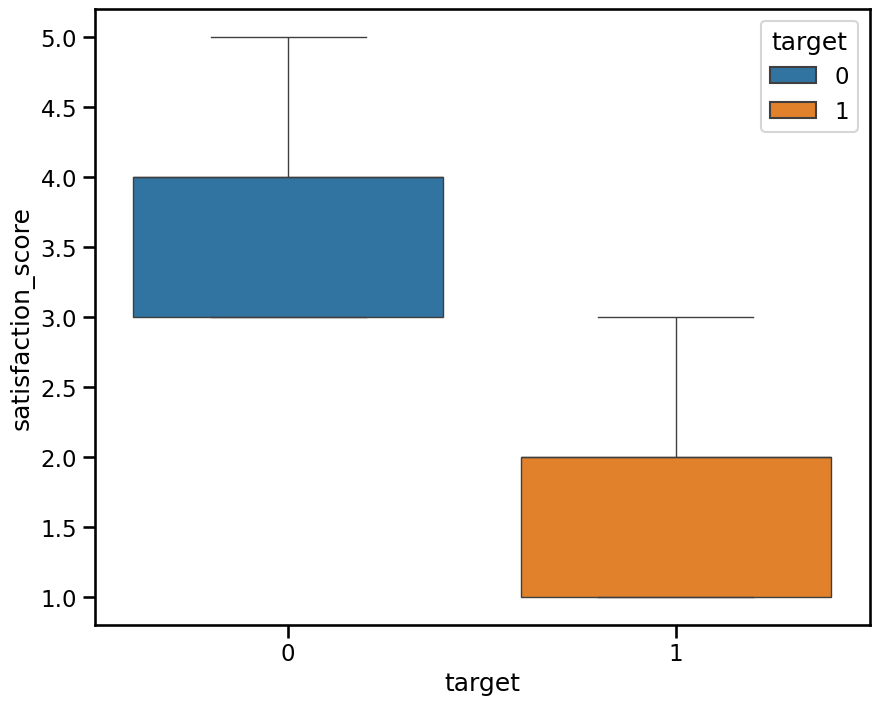

In [38]:
plt.figure(figsize=(10,8))

sns.boxplot(data=train, y='satisfaction_score',x='target', hue='target')

#### Wniosek: Satysfakcja
Zauważa się, satysfakcja na poziomie 3 jest minimalnym akceptowalnym przez klientów poziomem. Nie ma w zbiorze ani jednego klienta, który postanowił zrezygnować z usług pomimo wykazywania zadowolenia.

In [39]:
train['city'].nunique() # Bardzo duzo wariantow. Model sie zapcha + bardzo male proby nie sa reprezentatywne 

1102

### Staż klienta (var. Tenure_months)

Analiza rozkładu zmiennej reprezentującej czas korzystania z usług (staż w miesiącach).

* **Zależność staż a retencja:** Obserwujemy silną, ujemną korelację między stażem a skłonnością do odejścia. Klienci o dłuższym stażu (segment lojalny) wykazują znacznie niższe ryzyko rezygnacji w porównaniu do nowych użytkowników.

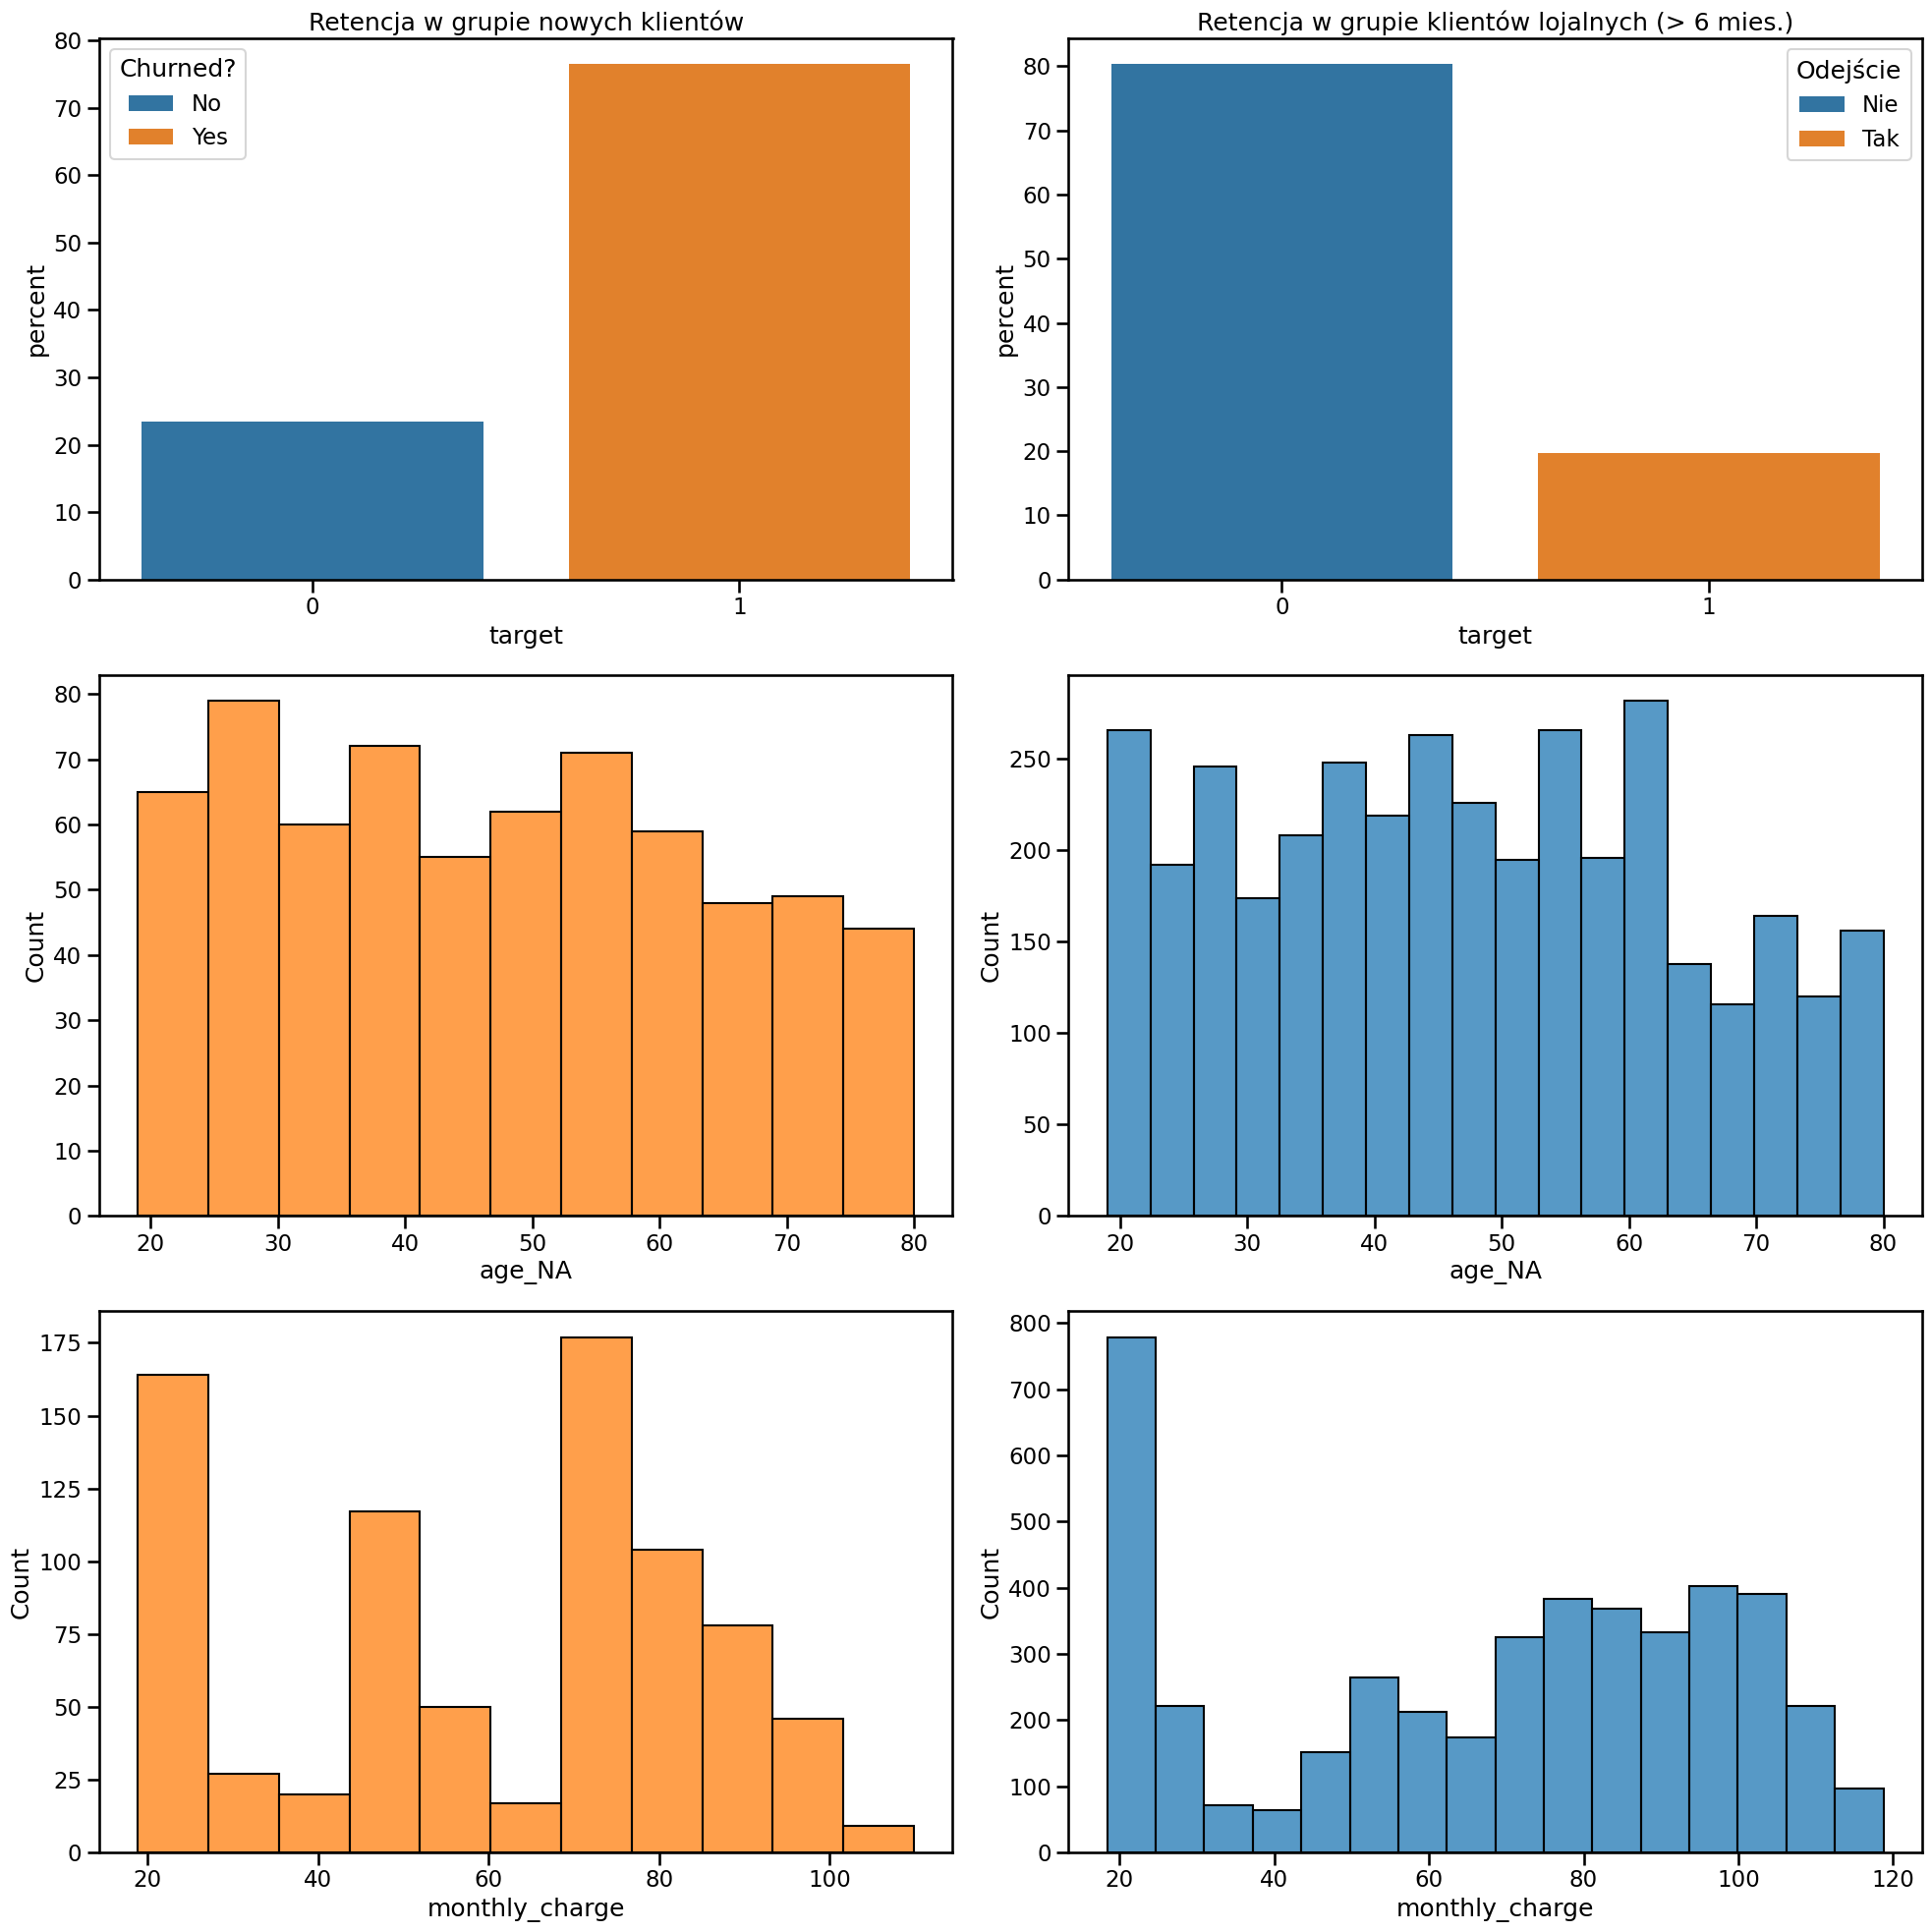

Liczebność grupy nowych klientów: 809


In [40]:
# Podział na nowych klientów (staż <= 6 mies.) oraz lojalnych (> 6 mies.)
new_clients = train[train['tenure_months'] <= 6]
loyal_clients = train[train['tenure_months'] > 6]

# Przygotowanie siatki 3x2 dla czytelnego porównania obu grup
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))

# --- RZĄD 1: Analiza retencji (procentowy churn) ---
# Użycie palety 'tab10' (C1 - pomarańczowy, C0 - niebieski) dla spójności wizualnej
sns.countplot(data=new_clients, x='target', hue='target', ax=ax[0, 0], stat='percent', palette=['C0', 'C1'])
ax[0, 0].legend(title='Churned?', labels=['No', 'Yes'])
ax[0, 0].set_title('Retencja w grupie nowych klientów')

sns.countplot(data=loyal_clients, x='target', hue='target', stat='percent', ax=ax[0, 1], palette=['C0', 'C1'])
ax[0, 1].legend(title='Odejście', labels=['Nie', 'Tak'])
ax[0, 1].set_title('Retencja w grupie klientów lojalnych (> 6 mies.)')

# --- RZĄD 2: Porównanie struktury wieku ---
# Nowi klienci - kolor pomarańczowy (C1)
sns.histplot(new_clients, x='age_NA', ax=ax[1, 0], color='C1')
# Klienci lojalni - kolor niebieski (C0)
sns.histplot(loyal_clients, x='age_NA', ax=ax[1, 1], color='C0')

# --- RZĄD 3: Porównanie opłat miesięcznych ---
sns.histplot(new_clients, x='monthly_charge', ax=ax[2, 0], color='C1')
sns.histplot(loyal_clients, x='monthly_charge', ax=ax[2, 1], color='C0')

# Estetyczne wyrównanie układu wykresów
plt.tight_layout()
plt.show()

# Wyświetlenie liczebności nowej grupy pod wykresami
print(f"Liczebność grupy nowych klientów: {len(new_clients)}")

In [41]:
print(f" Nowi klienci: \n{new_clients[['age_NA','monthly_charge']].describe()}\n")

print(f" Pozostali klienci: \n{(train[train['tenure_months'] > 6][['age_NA','monthly_charge']]).describe()}")

 Nowi klienci: 
           age_NA  monthly_charge
count  664.000000      809.000000
mean    47.221386       59.335600
std     17.052065       25.223557
min     19.000000       18.850000
25%     32.000000       40.100000
50%     47.000000       69.200000
75%     61.000000       79.650000
max     80.000000      109.900000

 Pozostali klienci: 
            age_NA  monthly_charge
count  3675.000000     4462.000000
mean     47.109660       67.511878
std      16.821898       30.527520
min      19.000000       18.400000
25%      33.000000       40.562500
50%      47.000000       74.475000
75%      60.000000       93.587500
max      80.000000      118.750000


In [42]:
### Utworzenie zmiennej flagi dla nowych klientów
train['is_new_client'] = (train['tenure_months'] <=6).astype(int)

### Analiza porównawcza: Nowi vs. Pozostali klienci

W celu głębszego zrozumienia struktury bazy, podzielono klientów na dwie grupy: **Nowi klienci** (krótki staż) oraz **Pozostali klienci**.

##### Charakterystyka wydatków (Monthly Charges)

* **Podobieństwo rozkładów:** Ogólne statystyki opisowe oraz kształt rozkładów dla obu grup są do siebie bardzo zbliżone. Sugeruje to, że staż klienta nie zmienia drastycznie struktury wybieranych usług w ujęciu globalnym.
* **Różnice w dominantach (Wartości najczęstsze):**
    * **Nowi klienci :** Najczęściej generują rachunki w przedziale **65 – 78 USD**. Wskazuje to na wybór droższych pakietów (prawdopodobnie światłowodowych) na początku współpracy, co przy braku satysfakcji potęguje skłonność do szybkiej rezygnacji.
    * **Pozostali klienci:** Dominanta przesuwa się w okolice **20 USD**. Są to prawdopodobnie klienci korzystający z podstawowych usług lub starszych, tańszych planów taryfowych, co sprzyja ich długoterminowej retencji.
* **Średnie wydatki:** Co ciekawe, mimo niskiej dominanty, **średnie miesięczne opłaty są o ok. 8 USD wyższe w grupie lojalnych klientów**. Może to wynikać z faktu, że osoby zostające z firmą na dłużej z czasem dokupują usługi dodatkowe lub posiadają rozbudowane pakiety rodzinne, co podnosi ich średni rachunek przy zachowaniu wysokiej lojalności.

##### Kluczowy wniosek: 
Najbardziej uderzającą obserwacją z całej analizy stażu jest zjawisko "wczesnej rezygnacji", które przybiera niepokojącą skalę w początkowym okresie współpracy:

* **Drastyczna retencja wśród nowych klientów:** W grupie osób o stażu **do 6 miesięcy**, wskaźnik rezygnacji wynosi aż **80%**. Stanowi to o **40%** odejść całego portela, co świadczy o tym, że średnio 2 z 5 odejść nastąpiły przed upłynięciem 1 półrocza.




**Wnioski strategiczne:**

1. **Błąd Onboardingu lub Oferty:** Tak wysoki odsetek odejść na starcie sugeruje, że albo proces wdrażania klienta jest wadliwy, albo obietnica marketingow rozmija się z rzeczywistą jakością usług.
2. **Rekomendacja:** Dział utrzymania klienta powinien skupić dużą część swoich zasobów prewencyjnych na użytkownikach w ich pierwszym kwartale stażu.




### Miasto (var. city)

Zmienne nominalne o wysokiej kardynalności (dużej liczbie unikalnych kategorii), takie jak nazwy miast, wymagają specjalistycznego podejścia w procesie przygotowania danych do modelowania.

### Strategia przetwarzania zmiennej `city`:

* **Problem wysokiej wymiarowości:** Zastosowanie standardowego kodowania *One-Hot Encoding* (OHE) dla setek lokalizacji doprowadziłoby do tzw. "przekleństwa wymiarowości". Skutkowałoby to drastycznym wydłużeniem czasu uczenia modelu oraz ryzykiem przeuczenia lub całkowitej niestabilności algorytmu.
* **Grupowanie rzadkich kategorii:** Podjęto decyzję o agregacji danych — wszystkie obserwacje dotyczące miast, które pojawiają się w zbiorze **rzadziej niż 20 razy**, zostały przypisane do wspólnej kategorii zbiorczej **"OTHER"**. Pozwala to na wyeliminowanie szumu informacyjnego generowanego przez małe próby.
* **Kodowanie docelowe (Target Encoding):** W kolejnym etapie zmienna kategoryczna zostanie zastąpiona wartościami numerycznymi odpowiadającymi **prawdopodobieństwu rezygnacji** w danym mieście. 

> **Uzasadnienie:** Taka transformacja pozwala zachować informację o wpływie lokalizacji na lojalność klientów bez zwiększania wymiarowości zbioru.

> **Uwaga:** Kluczowym aspektem takiego kodowania zmiennej jest dopasowanie danych jedynie do zbioru treningowego aby uniknąć przecieku informacji.

___

In [43]:
print(f'Liczba unikalnych miejscowości w zbiorze: {train["city"].nunique()}')

Liczba unikalnych miejscowości w zbiorze: 1102


In [44]:
# Zidentyfikowanie 10 miast z największą liczbą klientów w zbiorze treningowym
common_cities = train['city'].value_counts().sort_values(ascending=False).head(10).index

# Grupowanie rzadszych lokalizacji: pozostawienie 10 najczęstszych miast, 
# a pozostałe przypisanie do zbiorczej kategorii 'Other'
train['city'] = train['city'].apply(lambda x: x if x in common_cities else 'Other')

## 3.2. Analiza wartości brakujących

Analiza braków jest krytycznym etapem przygotowania danych, gdyż ich niewłaściwa obsługa może prowadzić do obciążeń statystycznych i błędnych wniosków. Podejście do tego procesu jest ściśle uzależnione od charakteru zbioru oraz celu biznesowego analizy. Dodatkowo poprawnie przeprowadzona imputacja pozwala na zachowanie wszystkich lub większości obserwacji co ma bezpośredni wpływ na finalny model.

### Proces diagnostyczny
W ramach niniejszego raportu proces obsługi brakujących informacji podzielono na trzy kluczowe kroki:

1.  **Diagnoza:** Identyfikacja kolumn zawierających puste rekordy oraz określenie skali zjawiska (procentowy udział braków w każdej zmiennej).
2.  **Zrozumienie mechanizmu:** Próba określenia natury braków zgodnie z klasyfikacją statystyczną:
    * **MCAR** (*Missing Completely at Random*) – braki całkowicie losowe.
    * **MAR** (*Missing at Random*) – braki zależne od innych obserwowanych zmiennych.
    * **MNAR** (*Missing Not at Random*) – braki wynikające z samej wartości zmiennej (np. osoby o bardzo wysokich zarobkach rzadziej je podają).
3.  **Imputacja lub usunięcie:** Podjęcie decyzji o strategii naprawczej 

> **Wniosek projektowy:** Skuteczna obsługa braków pozwala na zachowanie maksymalnej ilości informacji zawartej w zbiorze pierwotnym i zwiększa wiarygodność późniejszych predykcji modelu.

## 3.2.1. Diagnoza i klasyfikacja

Text(0.5, 1.0, 'Braki w danych')

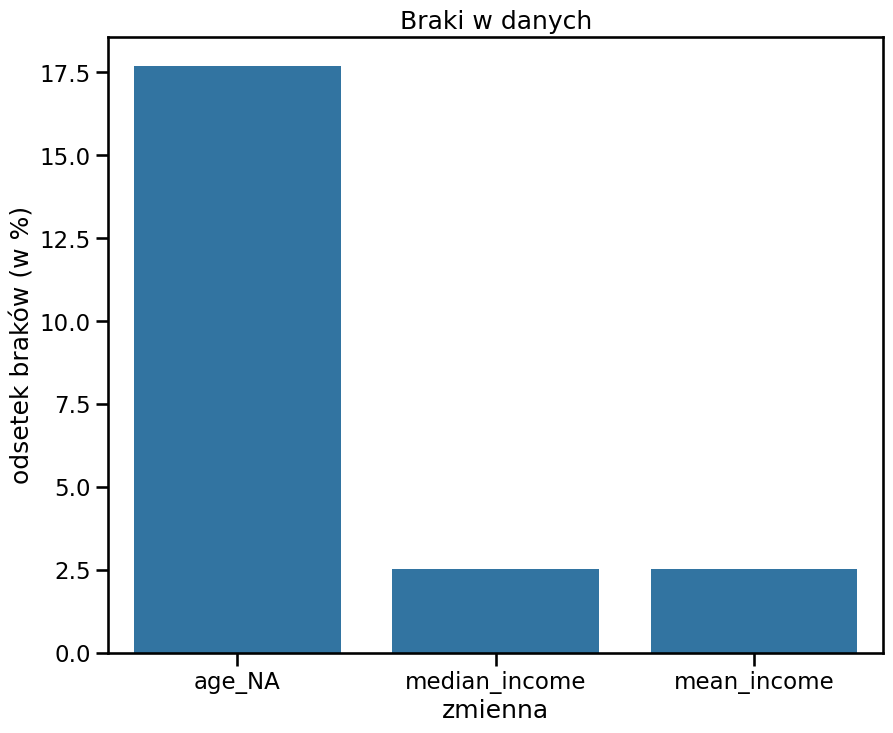

In [45]:
# Obliczenie procentowego udziału brakujących wartości dla zmiennych, które zawierają braki
# Wynik jest sortowany malejąco dla lepszej czytelności (największe braki na początku)
diag = (train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False) / len(train)) * 100

plt.figure(figsize=(10, 8))

# Wizualizacja braków danych na wykresie słupkowym
sns.barplot(diag)

# Opis osi X (nazwy zmiennych) i Y (procent braków)
plt.xlabel('zmienna')
plt.ylabel('odsetek braków (w %)')

# Tytuł wykresu informujący o kompletności zbioru danych
plt.title('Braki w danych')

### Diagnoza braków w badanym zbiorze

W toku analizy zidentyfikowano braki danych w następujących obszarach, klasyfikując je zgodnie z mechanizmem ich powstawania:

* **Zmienne ekonomiczne :** * Odnotowano braki w zmiennych opisujących **medianę oraz średni przychód** na poziomie kodów pocztowych w stanie Kalifornia. 

    * **Klasyfikacja:** Braki te zakwalifikowano jako **MCAR** (*Missing Completely at Random*), ponieważ wynikają one bezpośrednio z luk w danych źródłowych i nie są powiązane z wartościami innych cech w zbiorze.

* **Zmienna Wiek (Age):** 

    * W kolumnie dotyczącej wieku również występują braki danych.
    * **Klasyfikacja:** Podobnie jak w przypadku zmiennych ekonomicznych, jest to mechanizm **MCAR**. W tym konkretnym przypadku braki mają charakter kontrolowany — zostały wprowadzone sztucznie w celach edukacyjnych, aby umożliwić przetestowanie zaawansowanych technik imputacji.

### Strategia Imputacji
Ze względu na charakter braków (MCAR), w kolejnych krokach zostaną zastosowane techniki uzupełniania danych, które pozwolą na zachowanie liczności zbioru bez wprowadzania systematycznego błędu do estymacji parametrów modelu.
___

## 3.2.2. Imputacja brakujących wartości zmiennych ekonomicznych

Ze względu na specyfikę zmiennych ekonomicznych (mediana i średni przychód), które są przypisane do konkretnych jednostek terytorialnych (kody pocztowe), standardowe metody imputacji statystycznej oparte na korelacji z cechami klienta (np. wiek czy typ umowy) mogłyby okazać się mało skuteczne.

### Wybór metody: Spatial K-Nearest Neighbors (KNN)

Zdecydowano się na wykorzystanie **algorytmu najbliższych sąsiadów (KNN)** w oparciu o **koordynaty geograficzne** (szerokość i długość geograficzną). 

**Uzasadnienie merytoryczne:**

* **Zależność przestrzenna:** Wartości ekonomiczne wykazują silną autokorelację przestrzenną (regiony sąsiadujące ze sobą mają zazwyczaj zbliżony status materialny).
* **Średnia przestrzenna:** Metoda ta pozwala na wyliczenie **średniej przestrzennej**, gdzie brakująca wartość jest estymowana jako średnia ważona odległością od najbliższych punktów geograficznych, dla których dane są dostępne.
* **Ograniczenia danych:** Ponieważ zmienne te nie opisują bezpośrednio cech indywidualnych rekordu (klienta), a jedynie kontekst jego miejsca zamieszkania, współrzędne są najbardziej wiarygodnym predyktorem brakujących informacji.

> **Techniczne wykonanie:** Do obliczenia odległości wykorzystana zostanie metryka euklidesowa na znormalizowanych współrzędnych geograficznych

## 3.2.3. Dobór parametrów algorytmu najbliższych sąsiadów

Przed przystąpieniem do imputacji przeprowadzono analizę gęstości danych, aby określić optymalną liczbę sąsiadów oraz promień wyszukiwania.

#### Metodyka: Ball Tree oraz metryka Haversine 
W celu efektywnego przeszukiwania przestrzeni geograficznej wykorzystano algorytm **Ball Tree** wraz z metryką **Haversine**:

* **Ball Tree:** Jest to struktura danych (drzewo metryczne) optymalizująca wyszukiwanie wielowymiarowe. W przeciwieństwie do standardowych metod, Ball Tree grupuje punkty w n-wymiarowe sfery, co czyni go niezwykle wydajnym przy pracy z danymi o strukturze geograficznej.
* **Metryka Haversine:** Pozwala na obliczenie najkrótszej drogi między dwoma punktami na powierzchni kuli (Ziemi) na podstawie ich szerokości i długości geograficznej. Jest to niezbędne, aby uniknąć błędów wynikających z odwzorowania płaskiego przy dużych dystansach.

#### Analiza sąsiedztwa
Przeprowadzono test gęstości, sprawdzając **liczbę sąsiadów w promieniu 20 kilometrów** dla każdego punktu z brakującymi danymi.

> **Cel analizy:** Wybór promienia 20 km pozwala upewnić się, że imputacja "Spatial Average" będzie oparta na punktach o zbliżonej charakterystyce społeczno-ekonomicznej (lokalne sąsiedztwo), co minimalizuje ryzyko wprowadzenia sztucznego błędu do zmiennych przychodu.

quantiles: 

 0.00     0.0
0.03     1.0
0.10     1.0
0.20     2.0
0.50     2.0
0.75     3.0
0.90     8.0
1.00    13.0
Name: neighbors_within_10km, dtype: float64


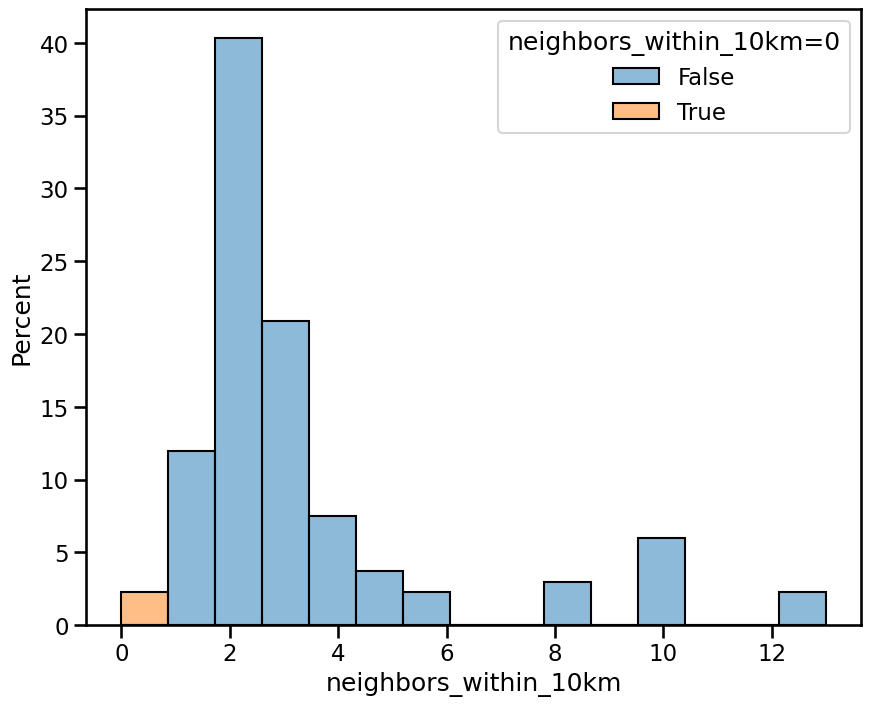

In [46]:
# Wyodrębnienie rekordów z brakującym dochodem i utworzenie flagi binarnej (1 = brak)
tr_inc_miss = train[np.isnan(train['median_income'])]
train['missing_income'] = np.isnan(train['median_income']).astype(int)

# Konwersja współrzędnych na radiany (wymóg metryki haversine w BallTree)
real_ids = tr_inc_miss.index.values
coords = np.radians(tr_inc_miss[['latitude','longitude']])

# Budowa drzewa przestrzennego do szybkiego wyszukiwania sąsiadów na sferze
tree = BallTree(coords, metric='haversine')

# Liczba sąsiadów w promieniu 20 km (promień ziemi ~6371 km)
count = tree.query_radius(coords, r=20/6371, count_only=True)

# Znalezienie najbliższego sąsiada (k=2, bo k=1 to ten sam punkt)
dist, ind = tree.query(coords, k=2)

# Obliczenie odległości do najbliższego sąsiada w kilometrach
tr_inc_miss['distance_to_nearest_neigbor'] = dist[:, 1] * 6371
tr_inc_miss['nearest_neighbor_idx'] = real_ids[ind[:, 1]]
tr_inc_miss['neighbors_within_10km'] = count - 1 # Odjęcie samego siebie

# Przygotowanie ramki z wynikami analizy braków i flagą braku sąsiadów
missing_incomes = tr_inc_miss.loc[np.isnan(tr_inc_miss['median_income']),
    ['median_income','mean_income','nearest_neighbor_idx',
     'distance_to_nearest_neigbor','neighbors_within_10km','city']
].sort_values(by='distance_to_nearest_neigbor', ascending=False)

missing_incomes['neighbors_within_10km=0'] = missing_incomes['neighbors_within_10km'] == 0

# Wizualizacja zagęszczenia sąsiadów dla rekordów z brakującym dochodem
plt.figure(figsize=(10,8))
sns.histplot(data=missing_incomes, x='neighbors_within_10km', 
             hue='neighbors_within_10km=0', bins=15, stat='percent')

# Analiza statystyczna rozkładu kwantyli liczby sąsiadów
print(f'quantiles: \n\n {missing_incomes["neighbors_within_10km"].quantile([0.00,0.03,0.1,0.2,0.5,0.75,0.90,1])}')

Na podstawie przeprowadzonej analizy gęstości, rozkładu kwartyli oraz wizualizacji liczby sąsiadów, podjęto ostateczne decyzje dotyczące hiperparametrów algorytmu imputacji:

* **Wybór $K=2$:** Analiza wykresu oraz kwantyli wskazała, że uwzględnienie dwóch najbliższych sąsiadów zapewnia optymalny balans między wygładzeniem danych a zachowaniem lokalnej specyfiki ekonomicznej. 
* **Imputacja ważona odległością:** * Zastosowano wagowanie odległością, co oznacza, że wpływ każdego z dwóch sąsiadów na wartość zaimputowaną jest odwrotnie proporcjonalny do jego dystansu od punktu z brakiem danych.
    * Dzięki temu sąsiad znajdujący się bliżej ma decydujący wpływ na wynik, co jest kluczowe w analizach przestrzennych, gdzie charakterystyka terenu może się szybko zmieniać.

### Imputacja

In [47]:
imputer = KNNImputer(weights='distance')
scaler = StandardScaler()

X_imp = X_train[['latitude','longitude','median_income','mean_income']]

X_imp_scaled = scaler.fit_transform(X_imp)
imputed_array = imputer.fit_transform(X_imp_scaled)
train['imp_median_income']= scaler.inverse_transform(imputed_array)[:,2]
train['imp_mean_income'] = scaler.inverse_transform(imputed_array)[:,3]
train = train.drop(['mean_income'],axis=1)

###  Walidacja procesu imputacji danych ekonomicznych

Aby upewnić się, że zastosowana metoda **Spatial KNN** nie wprowadziła istotnych obciążeń do zbioru danych, przeprowadzono dwuetapową walidację graficzną:

#### 1. Porównanie rozkładów (Density Plots)
Porównano gęstość rozkładu zmiennych przed i po procesie uzupełniania braków. 

* **Cel:** Sprawdzenie, czy imputacja "Spatial Average" nie spowodowała nienaturalnego spłaszczenia rozkładu lub powstania sztucznych maksimów (pików).
* **Wniosek:** Pokrywanie się krzywych rozkładu świadczy o zachowaniu oryginalnej struktury statystycznej danych przychodowych.

#### 2. Weryfikacja przestrzenna (Geospatial Map Validation)
Wygenerowano mapę punktową (wyrywkowa analiza wizualna), nanosząc zaimputowane wartości na tło geograficzne Kalifornii.

* **Cel:** Weryfikacja, czy wyliczone wartości mają sens w kontekście swojego otoczenia (np. czy zaimputowany przychód w bogatszej dzielnicy nadmorskiej nie został zaniżony przez odległych sąsiadów z uboższych regionów).
* **Wniosek:** Dzięki zastosowaniu wagowania odległością oraz metryki Haversine, zaimputowane wartości płynnie komponują się z trendami lokalnymi, co potwierdza wysoką jakość modelu przestrzennego.

> **Status:** Dane ekonomiczne zostały uznane za kompletne i gotowe do wykorzystania w procesie modelowania predykcyjnego.

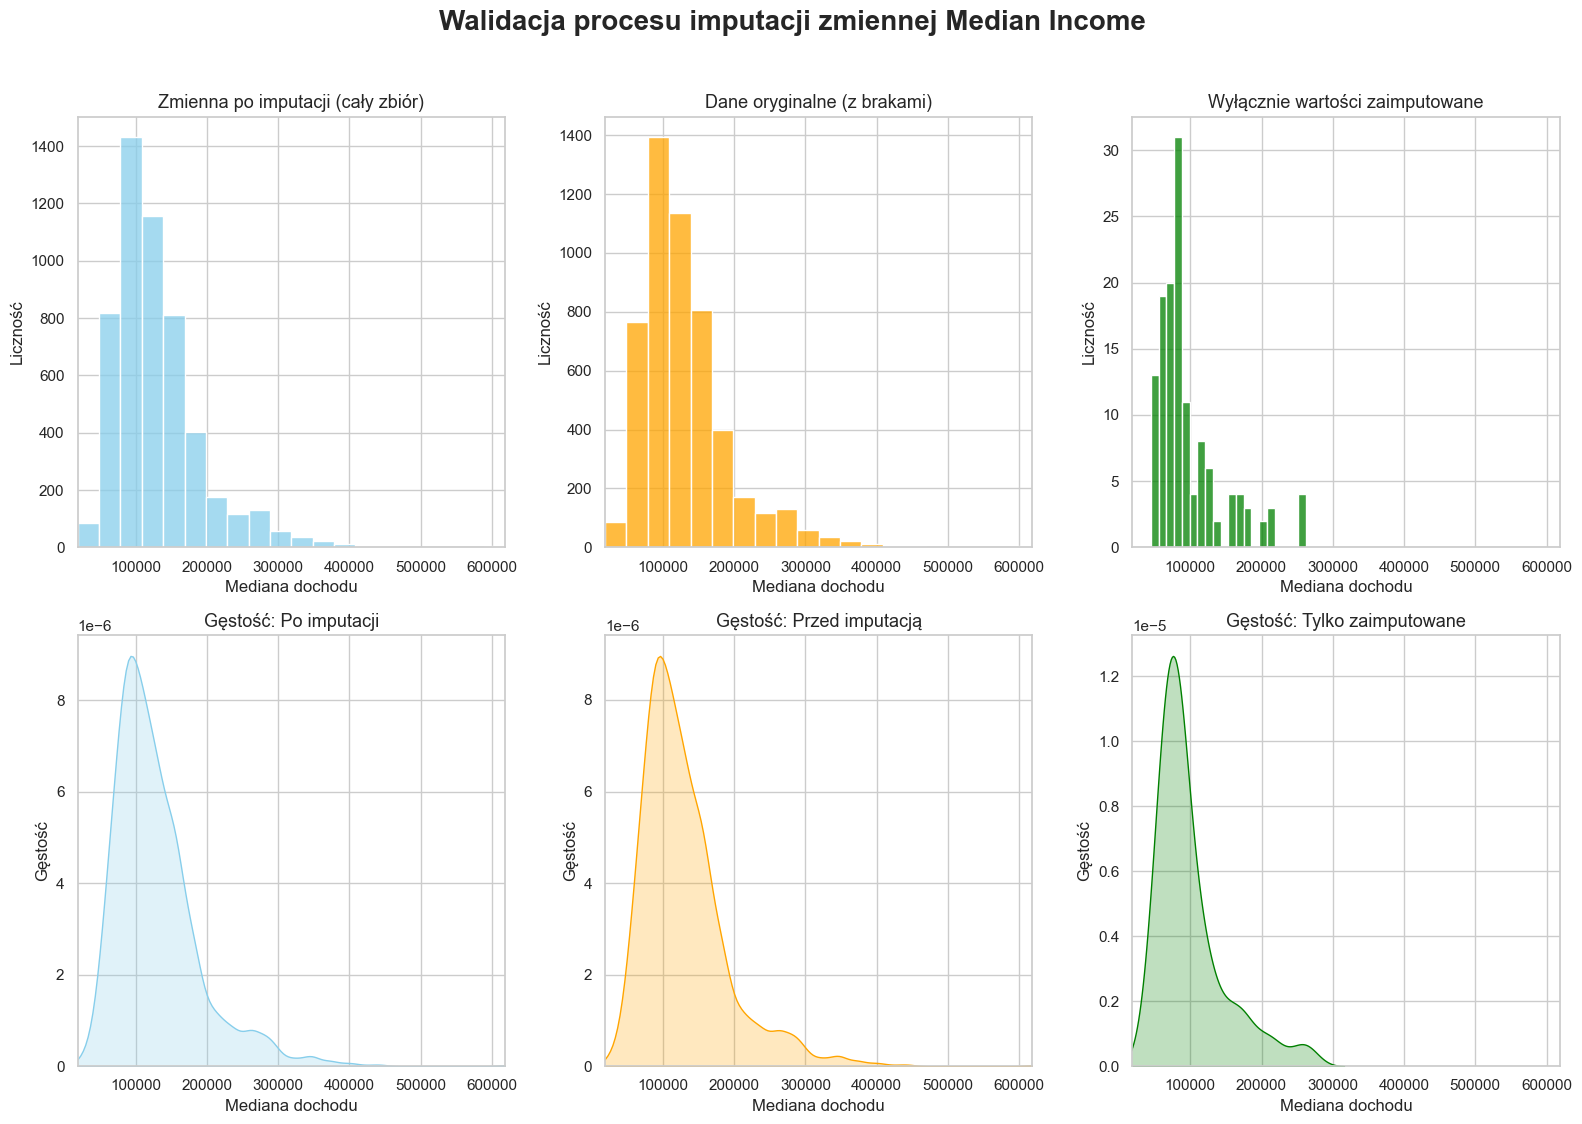

In [48]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(16, 11))
fig.suptitle('Walidacja procesu imputacji zmiennej Median Income', fontsize=20, fontweight='bold', y=1.02)

# Definicja wspólnych parametrów dla porównywalności osi
xlims = (train['imp_median_income'].min(), train['imp_median_income'].max())

# --- RZĄD 1: HISTOGRAMY ---

# 1. Po imputacji (całość)
sns.histplot(data=train, x='imp_median_income', ax=ax[0,0], bins=20, color='skyblue', kde=False)
ax[0,0].set_title('Zmienna po imputacji (cały zbiór)', fontsize=13)
ax[0,0].set_xlabel('Mediana dochodu')
ax[0,0].set_ylabel('Liczność')

# 2. Przed imputacją (oryginalne dane)
sns.histplot(data=train, x='median_income', ax=ax[0,1], bins=20, color='orange', kde=False)
ax[0,1].set_title('Dane oryginalne (z brakami)', fontsize=13)
ax[0,1].set_xlabel('Mediana dochodu')
ax[0,1].set_ylabel('Liczność')

# 3. Tylko wartości zaimputowane
imputed_only = train[train['median_income'].isna()]
sns.histplot(data=imputed_only, x='imp_median_income', ax=ax[0,2], bins=20, color='green', kde=False)
ax[0,2].set_title('Wyłącznie wartości zaimputowane', fontsize=13)
ax[0,2].set_xlabel('Mediana dochodu')
ax[0,2].set_ylabel('Liczność')

# --- RZĄD 2: WYKRESY GĘSTOŚCI (KDE) ---

# 4. Porównanie KDE całego zbioru
sns.kdeplot(data=train, x='imp_median_income', ax=ax[1,0], fill=True, color='skyblue')
ax[1,0].set_title('Gęstość: Po imputacji', fontsize=13)
ax[1,0].set_xlabel('Mediana dochodu')
ax[1,0].set_ylabel('Gęstość')

# 5. Gęstość danych oryginalnych
sns.kdeplot(data=train, x='median_income', ax=ax[1,1], fill=True, color='orange')
ax[1,1].set_title('Gęstość: Przed imputacją', fontsize=13)
ax[1,1].set_xlabel('Mediana dochodu')
ax[1,1].set_ylabel('Gęstość')

# 6. Gęstość tylko zaimputowanych rekordów
sns.kdeplot(data=imputed_only, x='imp_median_income', ax=ax[1,2], fill=True, color='green')
ax[1,2].set_title('Gęstość: Tylko zaimputowane', fontsize=13)
ax[1,2].set_xlabel('Mediana dochodu')
ax[1,2].set_ylabel('Gęstość')

# Ujednolicenie osi X dla wszystkich wykresów w celu rzetelnego porównania
for row in ax:
    for a in row:
        a.set_xlim(xlims)

plt.tight_layout()
plt.show()

plt.rcdefaults() # Reset stylu

### Interpretacja wyników walidacji

Analiza porównawcza rozkładów przed i po procesie uzupełniania danych pozwala na sformułowanie następujących wniosków:

* **Stabilność rozkładu:** Wizualizacja potwierdza, że ogólny kształt rozkładu mediany dochodu pozostał niemal niezmieniony po dokonaniu imputacji. Brak widocznych przesunięć w medianie czy dominancie świadczy o tym, że proces nie zaburzył pierwotnej struktury danych.
* **Wpływ liczności braków:** Niezmienność rozkładu wynika w dużej mierze z relatywnie niewielkiego odsetka brakujących rekordów w skali całego zbioru danych.
* **Jakość estymacji przestrzennej:** Wykresy gęstości (KDE) dla samych wartości zaimputowanych wykazują dużą zbieżność z rozkładem danych oryginalnych. Oznacza to, że średnia przestrzenna oparta na dwóch najbliższych sąsiadach skutecznie odtworzyła charakterystykę ekonomiczną brakujących regionów, nie generując przy tym wartości nietypowych.


In [49]:
# Utworzenie flagi logicznej dla brakujących wartości dochodu
train['missing_income'] = np.isnan(train['median_income'])

# Tworzenie interaktywnej mapy geograficznej
fig = px.scatter_geo(
    train,
    lat='latitude',
    lon='longitude',
    color='missing_income',      # Mapowanie kolorów na podstawie flagi braku danych
    color_discrete_map={
        True: 'red',             # Brakujące dane na czerwono
        False: 'seagreen'        # Kompletne dane na zielono
    },
    hover_name='city',           # Nazwa miasta wyświetlana w nagłówku tooltipa
    hover_data={                 # Konfiguracja danych wyświetlanych po najechaniu kursorem
        'latitude': False,
        'longitude': False,
        'target': ':.0f',        # Formatowanie statusu churn jako liczby całkowitej
        'imp_median_income': ':$,.0f', # Formatowanie dochodu jako waluty ($)
    },
    scope='usa',
    title='Mediana przychodów w podziale na kody pocztowe',
    template='plotly_white',
    width=1000,
    height=800
)

# Konfiguracja powiększenia (zoom) na obszar Kalifornii
fig.update_geos(
    lataxis_range=[32, 42],      # Zakres szerokości geograficznej
    lonaxis_range=[-125, -114],  # Zakres długości geograficznej
    center=dict(lat=37, lon=-119),
    resolution=50,               # Rozdzielczość mapy podkładowej
    showcoastlines=True, 
    coastlinecolor="RebeccaPurple",
    showland=True, 
    landcolor="LightGrey",
)

# Wyświetlenie interaktywnej mapy
fig.show()

### Przestrzenna weryfikacja precyzji imputacji

Powyższa wizualizacja animowana przedstawia mapę stanu Kalifornia z naniesionymi wynikami procesu uzupełniania danych. Pozwala ona na szczegółową ocenę jakości wykonanej pracy:

* **Precyzja lokalna:** Animacja pozwala podejrzeć wyniki imputacji (oznaczone czerwonym kolorem). Po wyrywkowym sprawdzeniu kilkunastu punktów uznaje się wyniki za satysfakcjonujące.
* **Dynamika zmian:** Interaktywny charakter wykresu ułatwia identyfikację regionów, w których zagęszczenie sąsiadów było największe, co bezpośrednio przekłada się na najwyższą ufność wobec zaimputowanych danych.

> **Wniosek końcowy:** Wysoka zbieżność wizualna punktów zaimputowanych z ich naturalnym sąsiedztwem stanowi ostateczne potwierdzenie poprawności przyjętej strategii 

## 3.2.4. Imputacja brakujących wartości zmiennej Wiek (Age)

W przypadku zmiennej dotyczącej wieku proces imputacji jest bardziej złożony niż przy danych dot. uśrednionych dochodów, ponieważ wymagają uwzględnienia wielowymiarowych zależności między cechami klienta.

#### Metodyka: `"Imputacji iteracyjnej, (ang. Iterative Impute)"` & Regresja lasów losowych
Zastosowano modelowanie predykcyjne w celu estymacji brakujących wartości:

* **Iterative Imputer (scikit-learn):** Jest to strategia imputacji wielowymiarowej, która modeluje każdą cechę z brakującymi danymi jako funkcję pozostałych cech. Proces odbywa się iteracyjnie, co pozwala na coraz dokładniejsze przybliżenie brakujących wartości.
* **Random Forest Regressor:** Jako estymator bazowy wykorzystano **las losowy**. Wybór ten podyktowany jest zdolnością algorytmu do wychwytywania nieliniowych zależności oraz brakiem konieczności normalizacji danych wejściowych, co jest kluczowe przy różnorodnych cechach (numerycznych i kategorycznych).

### Selekcja cech: Mutual Information Score
W celu uniknięcia "szumu" i poprawy precyzji modelu, zmienne objaśniające do imputacji wyselekcjonowano za pomocą wskaźnika **Mutual Information (MI)**:

> **Mutual Information Score** to miara zależności statystycznej między dwiema zmiennymi. W przeciwieństwie do korelacji Persona, MI mierzy dowolny rodzaj zależności (również nieliniowe). Wartość ta określa, jak dużo informacji o zmiennej "Wiek" możemy pozyskać, znając wartości innej zmiennej.

Dzięki temu podejściu, do modelu imputacji trafiły tylko te zmienne, które realnie niosą informację o wieku klienta, co znacząco zwiększa wiarygodność oszacowań.

In [50]:
# Przygotowanie zbioru cech (X) poprzez usunięcie kolumn celu, tekstowych oraz tych z brakami
X_train_mi = train[np.isnan(train['age_NA']) == False].drop(['target', 'city', 'churn_reason', 'churn_category', 'age_NA', 'median_income'], axis=1)

# Definicja zmiennej objaśnianej (y) - wiek klienta (bez brakujących wartości)
y_train_mi = train[np.isnan(train['age_NA']) == False]['age_NA']

# Przekodowanie cech kategorycznych (tekstowych) na wartości numeryczne (faktoryzacja)
# Jest to niezbędne, ponieważ algorytm mutual_info_regression wymaga danych liczbowych
for col in X_train_mi.select_dtypes(['object']).columns:
    X_train_mi[col], _ = X_train_mi[col].factorize() 

# Obliczenie współczynnika Mutual Information (MI) między cechami a wiekiem
mutual_info = mutual_info_regression(X_train_mi, y_train_mi, random_state=RANDOM_STATE)

# Przekształcenie wyników w czytelną tabelę DataFrame
mutual_info = pd.DataFrame(mutual_info)
mutual_info.index = X_train_mi.columns
mutual_info.columns = ['mi_score']

# Wyświetlenie 15 cech, które najlepiej tłumaczą zmienność wieku
print('TOP 15 CECH Z NAJWYŻSZYM MI SCORE\n')
print(mutual_info.sort_values(by='mi_score', ascending=False).head(15))

TOP 15 CECH Z NAJWYŻSZYM MI SCORE

                         mi_score
senior                   0.469896
avg_monthly_gb_download  0.344258
internet_type            0.041451
monthly_charge           0.041036
interntet_service        0.036410
streaming_music          0.030263
number_of_dependents     0.029516
dependents               0.027563
total_long_dist_charges  0.023994
is_new_client            0.016148
unlimited_data           0.015722
streaming_tv             0.014574
longitude                0.013772
premium_services         0.013678
cltv                     0.013012


### Selekcja cech do imputacji (Mutual Information Score)

Zanim przystąpiono do modelowania brakujących wartości wieku, przeprowadzono analizę istotności zmiennych przy użyciu miary **Mutual Information (MI)**. 

#### Jak interpretować wyniki Mutual Information?
W przeciwieństwie do klasycznej korelacji (np. Pearsona), która wykrywa jedynie zależności liniowe, `mutual_info_regression` opiera się na teorii informacji (entropii). 

* **Wartość 0:** Oznacza, że zmienne są od siebie całkowicie niezależne — znajomość jednej nie mówi nam absolutnie nic o drugiej.
* **Wartość dodatnia:** Wyższa wartość wskazuje na silniejszą zależność. MI mierzy, o ile zmniejsza się niepewność (entropia) dotycząca zmiennej celu (wiek) po poznaniu wartości danej cechy objaśniającej.
* **Zaleta:** Metoda ta świetnie radzi sobie z wykrywaniem nieliniowych wzorców oraz zależności w danych kategorycznych.

#### Decyzja o wyborze zmiennych
W celu zminimalizowania szumu informacyjnego i poprawy jakości modelu regresyjnego (Random Forest), przyjęto **punkt odcięcia na poziomie 0.02**. Decyzja ta jest również kluczowa w konteście tego, iż imputacja ta będzie wykonywana w Pipeline (ciąg procesów) wiele razy więc nie może być zbyt kosztowna obliczeniowo. 

Zmienne, których wynik MI był niższy od tego progu, uznano za nieistotne statystycznie w kontekście przewidywania wieku i odrzucono.

In [51]:
imputation_columns = ['senior', 'avg_monthly_gb_download', 'monthly_charge', 'internet_type',
       'dependents','age_NA']
X_train_age_imp = train[imputation_columns]

## Zmiana typu zmiennych kategorycznych na faktory numeryczne
for col in X_train_age_imp.select_dtypes(['object']).columns:
    X_train_age_imp[col], _ =X_train_age_imp[col].factorize() # Zmiana typu zmiennych na faktory (tylko na potrzeby MI oraz RandomForest)

## ZDEFINIOWANIE INSTANCJI ITERATIVE IMPUTER
rf_imputer = IterativeImputer(estimator = RandomForestRegressor(n_estimators=50,random_state=RANDOM_STATE,n_jobs=-1, max_depth=10),
                              max_iter=10,random_state=RANDOM_STATE, skip_complete=True)
## DOPASOWANIE MODELU
rf_imputer.fit(X_train_age_imp)
## ZAPISANIE WYNIKÓW IMPUTACJI
imputed_age = rf_imputer.transform(X_train_age_imp)

### IMPUTACJA MEDIANĄ (DLA PORÓWNANIA)
simple_imputer = SimpleImputer(strategy='median')
simple_imputed = simple_imputer.fit_transform(X_train_age_imp)



## 3.2.5. Walidacja imputacji zmiennej Wiek

Aby rzetelnie ocenić jakość działania modelu regresji lasów losowych, proces walidacji podzielono na dwa komplementarne etapy:

### 1. Scenariusz realny (Analiza statystyczna)
W tym kroku traktujemy dane tak, jak w rzeczywistym projekcie, gdzie wartości pierwotne są nieznane:

* **Analiza cech kluczowych (Feature Importance):** Weryfikacja, które zmienne (wyłonione wcześniej przez *MI*) miały największy wpływ na estymację wieku. Pozwala to ocenić logiczną spójność modelu (np. czy staż w firmie lub posiadanie określonych usług korelują z wiekiem w sposób przewidywalny).
* **Porównanie rozkładów:** Analiza wizualna histogramów oraz wykresów gęstości przed i po imputacji w celu sprawdzenia, czy model nie "wyprodukował" nienaturalnych skupień wartości (np. nadmiernej liczby osób w wieku średnim).

### 2. Scenariusz eksperymentalny
Jest to najbardziej precyzyjna metoda walidacji, możliwa dzięki kontrolowanemu usunięciu części danych w celach edukacyjnych:

* **Porównanie z realnymi wartościami:** Ponieważ dysponujemy oryginalnymi wartościami, które zostały celowo ukryte, możemy bezpośrednio porównać wartość teoretyczną ($\hat{y}$) z wartością empiryczną ($y$).
* **Metryki błędu:** Obliczenie wskaźników takich jak **MAE** (*Średni Błąd Bezwzględny*) lub **RMSE** (*Pierwiastek błędu średniokwadratowego*), pozwoli na jednosznaczną odpowiedź, która pozwoli oodpowiedzieć na pytanie: *O ile lat średnio myli się nasz model przy odtwarzaniu wieku klienta?*

___

In [52]:
## ZAPISANIE WYNIKÓW DO RAMEK DANYCH 
# Przekształcenie wyników imputacji (macierzy numpy) na ramki danych DataFrame
out = pd.DataFrame(imputed_age, index=X_train_age_imp.index)
out_simp = pd.DataFrame(simple_imputed, index=X_train_age_imp.index)
# Przypisanie uzupełnionych wartości do głównej ramki danych
# Funkcja .clip() ogranicza wiek do biologicznie realnego zakresu [18, 80]
train['full_imp_col'] = out.iloc[:,5].clip(lower=18, upper=80)
train['full_simp_col'] = out_simp.iloc[:,5]

# Stworzenie kopii danych dla rekordów, które pierwotnie miały braki w wieku
train_imputed = train[np.isnan(train['age_NA'])].copy()
train_imputed['age'] = age[train_imputed.index]

# Ekstrakcja ważności cech z modelu RF (Random Forest) użytego w procesie imputacji
# Pozwala to zrozumieć, które zmienne najlepiej przewidują wiek klienta
feature_imps = rf_imputer.imputation_sequence_[0][2].feature_importances_

# Przygotowanie tabeli istotności cech posortowanej malejąco
feat_imps = pd.DataFrame(data={
    'zmienna': [*X_train_age_imp.columns,][:-1],
    'istotność zmiennej': feature_imps}
).sort_values(by='istotność zmiennej', ascending=False)

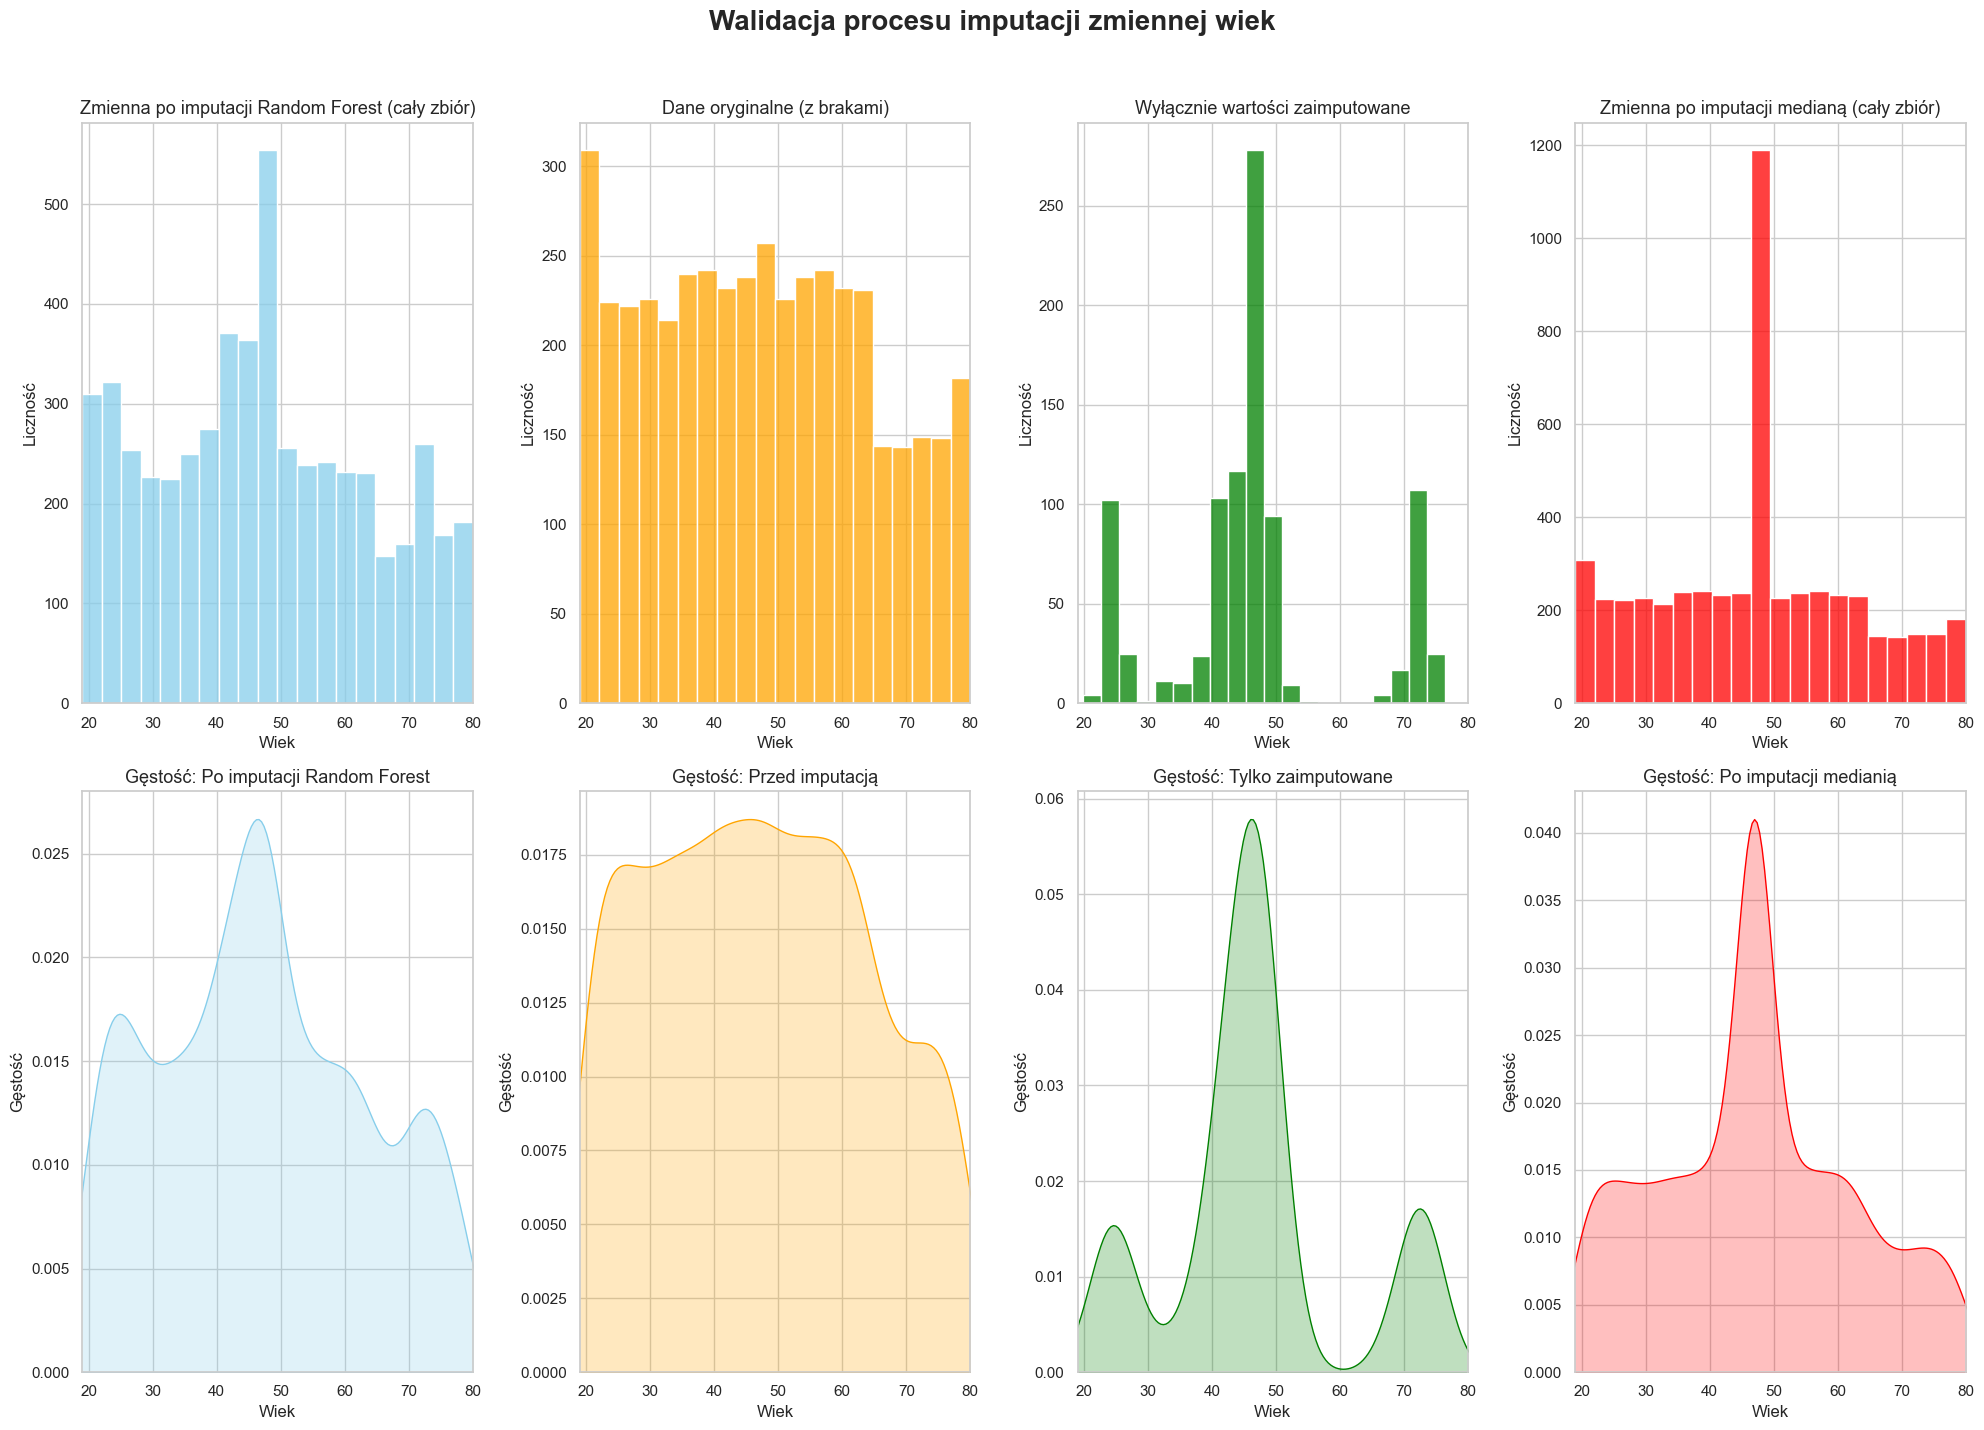

Zestawienie statystyk opisowych: 

        full_imp_col   age_NA  full_simp_col
count       5271.00  4339.00        5271.00
mean          47.06    47.13          47.10
std           16.35    16.86          15.29
min           19.00    19.00          19.00
25%           34.00    33.00          36.00
50%           46.74    47.00          47.00
75%           59.00    60.00          57.00
max           80.00    80.00          80.00


In [53]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(20, 14))
fig.suptitle('Walidacja procesu imputacji zmiennej wiek', fontsize=20, fontweight='bold', y=1.02)

# Definicja wspólnych parametrów dla porównywalności osi
xlims = (train['full_imp_col'].min(), train['full_imp_col'].max())

# --- RZĄD 1: HISTOGRAMY ---

# 1. Po imputacji Forest (Całość)
sns.histplot(data=train, x='full_imp_col', ax=ax[0,0], bins=20, color='skyblue', kde=False)
ax[0,0].set_title('Zmienna po imputacji Random Forest (cały zbiór)', fontsize=13)
ax[0,0].set_xlabel('Wiek')
ax[0,0].set_ylabel('Liczność')

# 2. Przed imputacją (oryginalne dane)
sns.histplot(data=train, x='age_NA', ax=ax[0,1], bins=20, color='orange', kde=False)
ax[0,1].set_title('Dane oryginalne (z brakami)', fontsize=13)
ax[0,1].set_xlabel('Wiek')
ax[0,1].set_ylabel('Liczność')

# 3. Tylko wartości zaimputowane
imputed_only = train[train['age_NA'].isna()]
sns.histplot(data=imputed_only, x='full_imp_col', ax=ax[0,2], bins=20, color='green', kde=False)
ax[0,2].set_title('Wyłącznie wartości zaimputowane', fontsize=13)
ax[0,2].set_xlabel('Wiek')
ax[0,2].set_ylabel('Liczność')

sns.histplot(data=train, x='full_simp_col', ax=ax[0,3], bins=20, color='red', kde=False)
ax[0,3].set_title('Zmienna po imputacji medianą (cały zbiór)', fontsize=13)
ax[0,3].set_xlabel('Wiek')
ax[0,3].set_ylabel('Liczność')

# *** RZĄD 2: WYKRESY GĘSTOŚCI (KDE) ***

# 4. Porównanie KDE całego zbioru
sns.kdeplot(data=train, x='full_imp_col', ax=ax[1,0], fill=True, color='skyblue')
ax[1,0].set_title('Gęstość: Po imputacji Random Forest', fontsize=13)
ax[1,0].set_xlabel('Wiek')
ax[1,0].set_ylabel('Gęstość')

# 5. Gęstość danych oryginalnych
sns.kdeplot(data=train, x='age_NA', ax=ax[1,1], fill=True, color='orange')
ax[1,1].set_title('Gęstość: Przed imputacją', fontsize=13)
ax[1,1].set_xlabel('Wiek')
ax[1,1].set_ylabel('Gęstość')

# 6. Gęstość tylko zaimputowanych rekordów
sns.kdeplot(data=imputed_only, x='full_imp_col', ax=ax[1,2], fill=True, color='green')
ax[1,2].set_title('Gęstość: Tylko zaimputowane', fontsize=13)
ax[1,2].set_xlabel('Wiek')
ax[1,2].set_ylabel('Gęstość')

sns.kdeplot(data=train, x='full_simp_col', ax=ax[1,3], fill=True, color='red')
ax[1,3].set_title('Gęstość: Po imputacji medianią', fontsize=13)
ax[1,3].set_xlabel('Wiek')
ax[1,3].set_ylabel('Gęstość')

# Ujednolicenie osi X dla wszystkich wykresów w celu rzetelnego porównania
for row in ax:
    for a in row:
        a.set_xlim(xlims)

plt.tight_layout()
plt.show()

plt.rcdefaults() # Reset stylu


print(f"Zestawienie statystyk opisowych: \n\n {train[['full_imp_col','age_NA','full_simp_col']].describe().round(2)}")


Text(0.5, 1.0, 'Istotność zmiennych w modelu Random Forest')

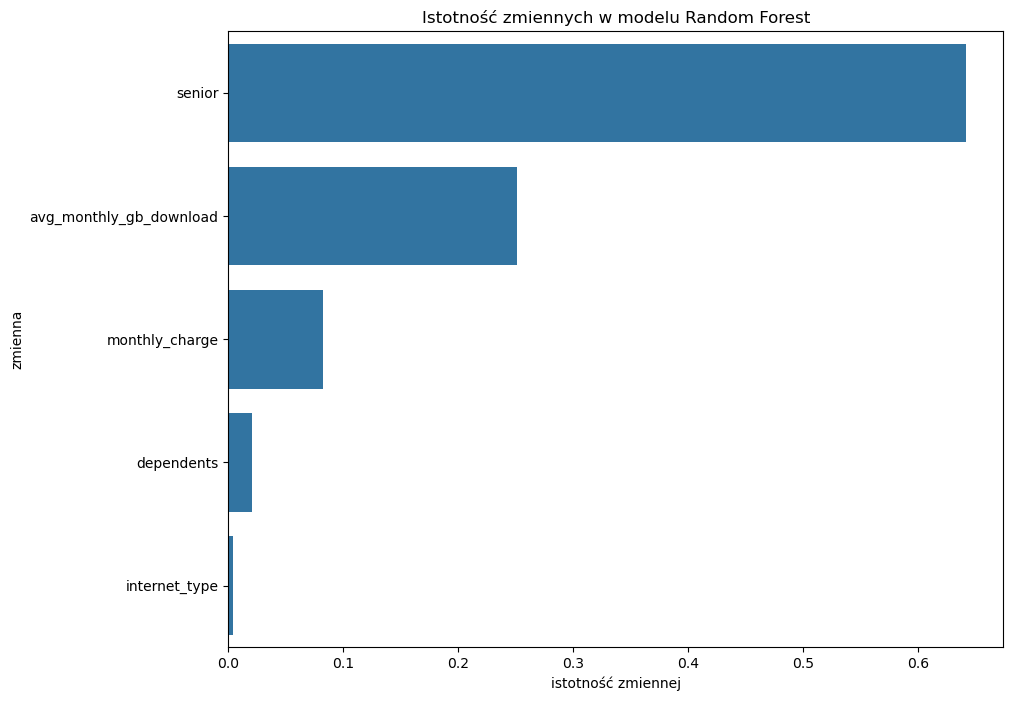

In [54]:
plt.figure(figsize= (10,8))
sns.barplot(data = feat_imps, x='istotność zmiennej', y = 'zmienna')
plt.title('Istotność zmiennych w modelu Random Forest')


### Ocena imputacji: Scenariusz realny

Po przeprowadzeniu imputacji zmiennej `Wiek` przy użyciu algorytmu Random Forest w ramach *Iterative Imputer*, sformułowano następujące wnioski:

* **Stabilność statystyczna:** Mimo wysokiego poziomu braków (20%), parametry rozkładu (średnia oraz odchylenie standardowe) przed i po imputacji pozostają niemal identyczne. Jest to bardzo obiecujący wynik, świadczący o tym, że model nie zniekształcił ogólnej struktury demograficznej zbioru.
* **Rozpoznanie grup wiekowych:** Analiza histogramu wartości zaimputowanych wykazuje, że model poprawnie zidentyfikował segment seniorów (65+). Świadczy to o tym, że cechy użyte do imputacji niosły wystarczający sygnał do odróżnienia tej grupy od pozostałych klientów.
* **Konserwatyzm modelu:** Średni wiek w zbiorze wynosił ok. 47 lat. Zauważono, że w przypadkach o najwyższej niepewności, model najczęściej estymował wartości zbliżone do średniej. Jest to bezpieczne zachowanie algorytmu, który unika generowania wartości skrajnych bez wyraźnych przesłanek w danych.
* **Przewaga nad metodami prostymi:** Choć imputacja nie jest perfekcyjna, jej wynik wizualnie lepiej odwzorowuje pierwotny rozkład zmiennej niż prosta imputacja medianą, która powoduje nienaturalny szczyt w rozkładzie.
* **Istotność cech (Feature Importance):** 

    * **Senior:** Zgodnie z wynikami *MI Score*, była to kluczowa zmienna. Potwierdza to logiczną spójność modelu.
    * **Avg Monthly Download:** Druga w kolejności zmienna. Model słusznie zidentyfikował zależność, w której intensywność korzystania z danych maleje wraz z wiekiem użytkownika.

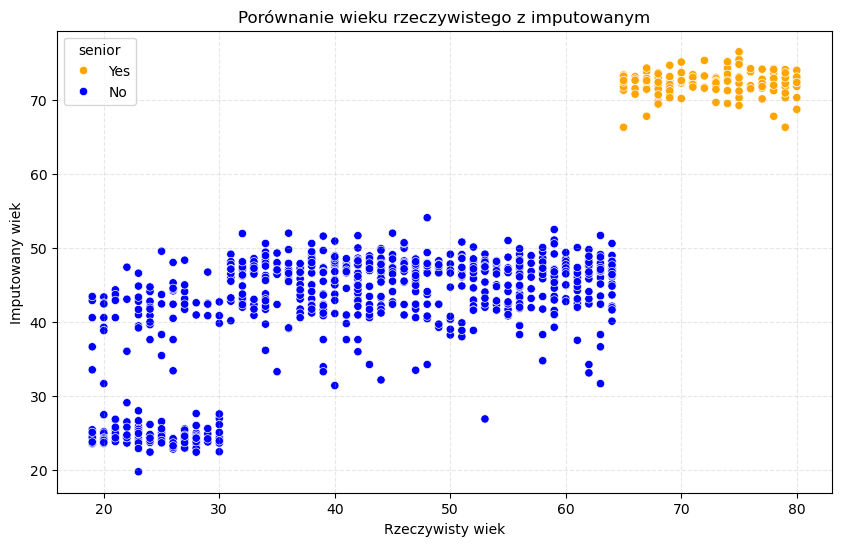

In [55]:
# Definicja spójnej palety kolorystycznej dla statusu seniora
custom_palette = {'Yes': 'orange', 'No': 'blue'}

plt.figure(figsize=(10, 6))

# Wykres rozrzutu porównujący wiek rzeczywisty z wartościami uzyskanymi z imputacji
# Kolorowanie (hue) pozwala sprawdzić, czy model poprawnie sklasyfikował seniorów
sns.scatterplot(
    data=train_imputed, 
    x='age', 
    y='full_imp_col', 
    hue='senior', 
    palette=custom_palette
)

# Konfiguracja estetyki: tytuł, opisy osi oraz delikatna siatka pomocnicza
plt.title('Porównanie wieku rzeczywistego z imputowanym')
plt.xlabel('Rzeczywisty wiek')
plt.ylabel('Imputowany wiek')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

In [56]:
rmse_rf = root_mean_squared_error(train_imputed[train_imputed['age']<=60]['age'], train_imputed[train_imputed['age']<=60]['full_imp_col'])
mae_rf = mean_absolute_error(train_imputed[train_imputed['age']<=60]['age'], train_imputed[train_imputed['age']<=60]['full_imp_col'])
rmse_med = root_mean_squared_error(train_imputed[train_imputed['age']<=60]['age'], train_imputed[train_imputed['age']<=60]['full_simp_col'])
mae_med = mean_absolute_error(train_imputed[train_imputed['age']<=60]['age'], train_imputed[train_imputed['age']<=60]['full_simp_col'])
print("GRUPA 60+")
print(f" RMSE RANDOM FOREST: {rmse_rf} \n MAE RANDOM FOREST: {mae_rf} \n\n RMSE MEDIANA: {rmse_med} \n MAE MEDIANA: {mae_med} ")

GRUPA 60+
 RMSE RANDOM FOREST: 9.741876161947738 
 MAE RANDOM FOREST: 7.882980789345254 

 RMSE MEDIANA: 14.254873853227483 
 MAE MEDIANA: 11.767142857142858 


In [57]:
print("GRUPA <30")

rmse_rf = root_mean_squared_error(train_imputed[train_imputed['age']<=30]['age'], train_imputed[train_imputed['age']<=30]['full_imp_col'])
mae_rf = mean_absolute_error(train_imputed[train_imputed['age']<=30]['age'], train_imputed[train_imputed['age']<=30]['full_imp_col'])
rmse_med = root_mean_squared_error(train_imputed[train_imputed['age']<=30]['age'], train_imputed[train_imputed['age']<=30]['full_simp_col'])
mae_med = mean_absolute_error(train_imputed[train_imputed['age']<=30]['age'], train_imputed[train_imputed['age']<=30]['full_simp_col'])

print(f" RMSE RANDOM FOREST: {rmse_rf} \n MAE RANDOM FOREST: {mae_rf} \n\n RMSE MEDIANA: {rmse_med} \n MAE MEDIANA: {mae_med} ")

GRUPA <30
 RMSE RANDOM FOREST: 10.99697864111851 
 MAE RANDOM FOREST: 8.200506863799637 

 RMSE MEDIANA: 22.877431770679824 
 MAE MEDIANA: 22.623115577889447 


In [58]:
print("GRUPA 30-60")

# Filtrowanie danych dla przedziału (30, 60]
group_mask = (train_imputed['age'] > 30) & (train_imputed['age'] <= 60)

rmse_rf = root_mean_squared_error(train_imputed[group_mask]['age'], train_imputed[group_mask]['full_imp_col'])
mae_rf = mean_absolute_error(train_imputed[group_mask]['age'], train_imputed[group_mask]['full_imp_col'])
rmse_med = root_mean_squared_error(train_imputed[group_mask]['age'], train_imputed[group_mask]['full_simp_col'])
mae_med = mean_absolute_error(train_imputed[group_mask]['age'], train_imputed[group_mask]['full_simp_col'])

print(f" RMSE RANDOM FOREST: {rmse_rf} \n MAE RANDOM FOREST: {mae_rf} \n\n RMSE MEDIANA: {rmse_med} \n MAE MEDIANA: {mae_med} ")

GRUPA 30-60
 RMSE RANDOM FOREST: 9.195930226808105 
 MAE RANDOM FOREST: 7.756857657975151 

 RMSE MEDIANA: 8.719285985893135 
 MAE MEDIANA: 7.455089820359281 


In [59]:
print("PEŁNA PRÓBA Z BRAKAMI")

rmse_rf = root_mean_squared_error(train_imputed['age'], train_imputed['full_imp_col'])
mae_rf = mean_absolute_error(train_imputed['age'], train_imputed['full_imp_col'])
rmse_med = root_mean_squared_error(train_imputed['age'], train_imputed['full_simp_col'])
mae_med = mean_absolute_error(train_imputed['age'], train_imputed['full_simp_col'])

print(f" RMSE RANDOM FOREST: {rmse_rf} \n MAE RANDOM FOREST: {mae_rf} \n\n RMSE MEDIANA: {rmse_med} \n MAE MEDIANA: {mae_med} ")

PEŁNA PRÓBA Z BRAKAMI
 RMSE RANDOM FOREST: 10.0864481914633 
 MAE RANDOM FOREST: 8.058169190439237 

 RMSE MEDIANA: 16.8639786771697 
 MAE MEDIANA: 14.3637339055794 


### Wnioski ze scenariusza eksperymentalnego

Najważniejszym etapem walidacji było porównanie wartości zaimputowanych z empirycznymi. Analiza błędu bezwzględnego (MAE) oraz błędu średniokwadratowego (RMSE) jednoznacznie potwierdza przewagę modelu Random Forest nad metodą naiwną (medianą)

### 1. Analiza skupień na wykresie rozrzutu
Na wykresie rozrzutu wartości rzeczywistych do przewidzianych zaobserwowano trzy charakterystyczne segmenty:

* **Grupa młodych (< 30 lat):** Model wykazał się wysoką precyzyją. Zmienne behawioralne (wydatki, zużycie danych) pozwoliły na relatywnie skuteczną stratyfikację tej grupy, co skutkuje blisko dwukrotnie mniejszym błędem niż w przypadku mediany.
* **Grupa średnia (30-60 lat):** Najliczniejszy segment, w którym model przyjął podejście konserwatywne, skupiając predykcje wokół średniej. W tym przedziale wyniki są zbliżone do imputacji medianą.
* **Grupa seniorów (60+):** Tutaj model ponownie ma przewagę, znacznie lepiej radząc sobie z identyfikacją osób starszych niż statyczna mediana.

### 2. Porównanie metryk błędu w podziale na segmenty

Poniższa tabela przedstawia szczegółowe porównanie skuteczności imputacji **Random Forest** względem **Imputacji Medianą**. Wyniki bazują na błędzie średniokwadratowym (**RMSE**) oraz średnim błędzie bezwzględnym (**MAE**).

| Segment wiekowy | RMSE (Random Forest) | MAE (Random Forest) | RMSE (Mediana) | MAE (Mediana) |
| :---: | :---: | :---: | :---: | :---: |
| **Ludzie młodzi (< 30)** | **10.00** | **8.20** | 22.00 | 22.00 |
| **Wiek średni (30-60)** | 9.19 | 7.45 | **8.71** | **7.45** |
| **Seniorzy (60+)** | **9.74** | **7.88** | 14.25 | 11.77 |
| **PEŁNA PRÓBA** | **10.09** | **8.06** | 16.86 | 14.36 |


* **Wynik globalny:** Patrząc na cały zbiór, **Random Forest redukuje średni błąd (MAE) oraz pierwiastek błędu średniokwadratowego (RMSE) średnio o ok. 6 lat** względem prostej imputacji medianą.

###  Decyzja projektowa i dalsze kroki
Na podstawie przeprowadzonej walidacji (scenariusz realny oraz eksperymentalny), podjęto następujące decyzje dotyczące zmiennej `Wiek`:

1.  **Zatwierdzenie imputacji:** Wyniki uzyskane za pomocą algorytmu Random Forest uznaje się za wystarczające. Braki danych zostaną trwale zastąpione wartościami wygenerowanymi przez model, co pozwoli na zachowanie pełnej liczności zbioru treningowego.
2.  **Dyskretyzacja:** W celu zniwelowania błędu predykcji punktowej, zmienna wiek zostanie poddana procesowi binowania. Przekształcenie wieku numerycznego na przedziały pozwoli na stworzenie bardziej stabilnych i odpornych na szum kategorii.
3.  **Wprowadzenie flagi `missing_age`:** Do zbioru danych zostanie dodana nowa zmienna binarna (0/1).

    * Będzie ona informować przyszły model predykcyjny, czy dana wartość wieku była oryginalna, czy pochodzi z imputacji. 
    * Pozwoli to algorytmowi uczenia maszynowego na ewentualne skorygowanie wagi tych rekordów i "zrozumienie" kontekstu pochodzenia danych.

> **Podsumowanie:** wielopoziomowe podejście (imputacja + dyskretyzacja + flaga) ma na celu minimalizacje ryzyka wprowadzenia błędu systematycznego do modelu docelowego, zachowując jak największą część obserwacji oraz wartości informacyjnej zmiennej. 

## Dyskretyzacja

Text(0, 0.5, 'Liczność')

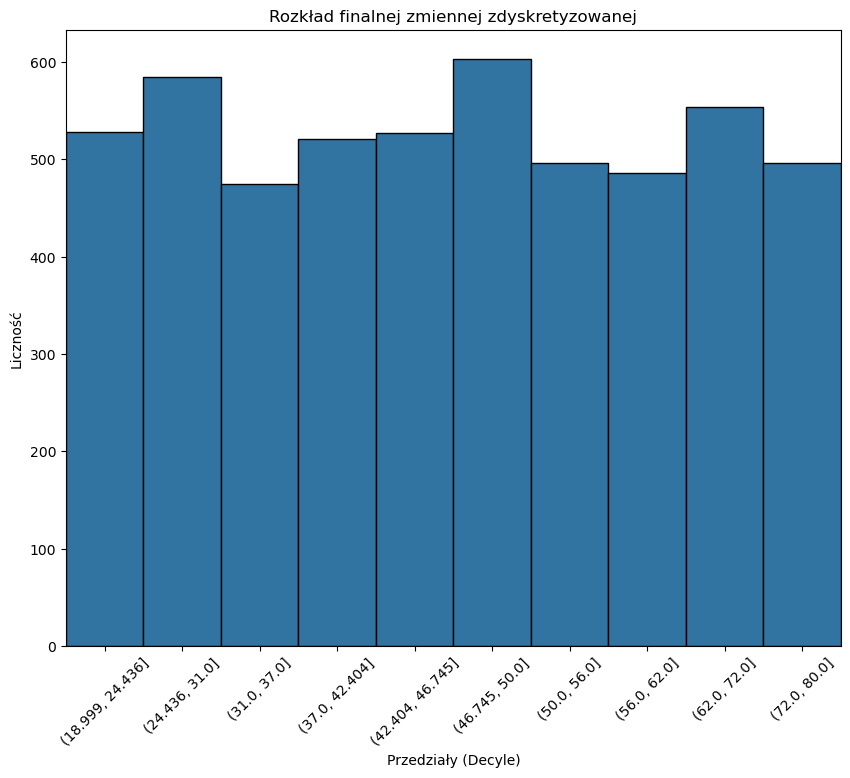

In [62]:
# Dyskretyzacja wieku na 10 równolicznych przedziałów (decyle)
# qcut dba o to, aby w każdym przedziale znalazła się zbliżona liczba klientów
train['age_binned'] = pd.qcut(train['full_imp_col'], q=10)

plt.figure(figsize=(10, 8))

# Wykres liczebności dla nowo utworzonych przedziałów wiekowych
# width=1.0 i edgecolor sprawiają, że wykres przypomina klasyczny histogram
sns.countplot(train, x='age_binned', width=1.0, edgecolor='black')

# Rotacja etykiet osi X o 45 stopni, aby uniknąć ich nakładania się
plt.tick_params(axis='x', rotation=45)

# Opisy osi i tytuł dokumentujący rozkład zmiennej po imputacji i dyskretyzacji
plt.title('Rozkład finalnej zmiennej zdyskretyzowanej')
plt.xlabel('Przedziały (Decyle)')
plt.ylabel('Liczność')

### Efekt dyskretyzacji
* **Wygładzenie rozkładu:** Podział na decyle pozwolił na zniwelowanie drobnych błędów predykcji punktowej modelu Random Forest. Dzięki temu rozkład po imputacji sbliżył się do pierwotnego rozkładu zmiennej sprzed imputacji.


### Utworzenie flagi "brakujący wiek"

___

In [63]:
train['missing_age'] = np.isnan(train['age_NA']).astype(int)
train['age_NA'] = round(train['age_NA'].fillna(train['full_imp_col'])) # Finalne wypełnienie braków

## 3.3. Analiza geograficzna 

In [64]:
# Tworzenie interaktywnej mapy gęstości (Heatmap) populacji klientów
fig = px.density_map(
    train, 
    lat='latitude', 
    lon='longitude', 
    radius=4,               # Rozmiar punktu wpływającego na "ciepło" mapy
    center=dict(lat=36.7783, lon=-119.4179), # Środek mapy (Kalifornia)
    zoom=5,
    map_style="open-street-map",
    hover_name='city',
    hover_data={
        'latitude': False,
        'longitude': False,
        'monthly_charge': ':$.2f', # Formatowanie walutowe w okienku hover
        'age_NA': True,            # Wyświetlanie wieku (z flagą braków)
        'target': True             # Wyświetlanie statusu churn
    },
    color_continuous_scale="Viridis", # Czytelna skala barwna od fioletu do żółci
    title='Gęstość populacji klientów w Kalifornii',
    width=1000,
    height=800
)

# Optymalizacja marginesów i opisu legendy koloru
fig.update_layout(
    margin=dict(b=0, t=40, l=0, r=0),
    coloraxis_colorbar=dict(title="Zagęszczenie populacji")
)

fig.show()

Wizualizacja rozmieszczenia klientów na mapie stanu Kalifornia pozwala na sformułowanie kluczowych wniosków dotyczących struktury geograficznej bazy:

* **Szeroka ekspozycja:** Klienci są rozproszeni systematycznie na terenie całego stanu, co świadczy o dużej dostępności usług operatora zarówno w regionach zurbanizowanych, jak i słabiej zaludnionych.
* **Kluczowe aglomeracje:** Mimo ogólnego rozproszenia, na mapie wyraźnie zarysowują się cztery główne ośrodki koncentracji użytkowników:

    1.  **Los Angeles** (największe skupienie w południowej części stanu),
    2.  **San Francisco** 
    3.  **Sacramento** (znacząca baza w stolicy stanu),
    4.  **Fresno** (główny punkt centralnej części Kalifornii).
    
* **Potencjał biznesowy:** Identyfikacja tych ośrodków jest kluczowa dla planowania lokalnych strategii marketingowych. Pozwala na optymalizację kosztów logistycznych oraz lepsze targetowanie kampanii promocyjnych (np. dedykowane oferty regionalne dla mieszkańców dużych miast).


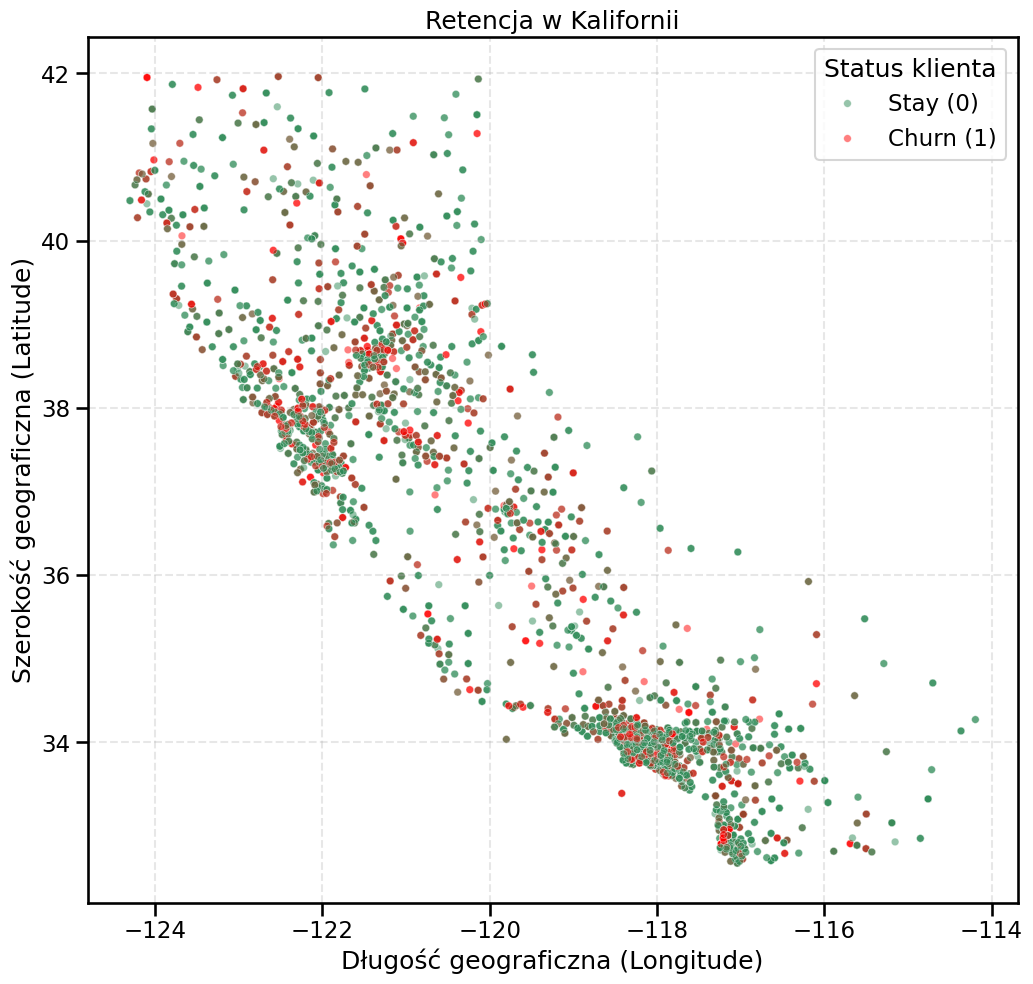

In [65]:
plt.figure(figsize=(12, 14))

# Ustawienie kontekstu "talk" dla lepszej czytelności etykiet w raporcie
sns.set_context("talk")

# Wykres punktowy: Longitude na osi X, Latitude na osi Y
# Używamy kolorów: zielony dla lojalnych, czerwony dla tych, którzy odeszli
ax = sns.scatterplot(data=train, x='longitude', y='latitude', hue='target', 
                    palette={0: 'seagreen', 1: 'red'}, alpha=0.5, s=30)

# Ręczna modyfikacja legendy, aby była czytelna dla odbiorcy biznesowego
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Stay (0)', 'Churn (1)'], title="Status klienta", loc='upper right')

# Zablokowanie proporcji osi, aby mapa nie była nienaturalnie rozciągnięta
plt.gca().set_aspect('equal', adjustable='box')

plt.title('Retencja w Kalifornii')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('Długość geograficzna (Longitude)')
plt.ylabel('Szerokość geograficzna (Latitude)')
plt.show()

In [66]:
coords = np.radians(train[['latitude','longitude']])
tree = BallTree(coords, metric='haversine')
count = tree.query_radius(coords, r=10/6371, count_only=True)
train['neighbors_within_10km'] = count -1 

Po naniesieniu danych o statusie klientów na mapę geograficzną stanu Kalifornia, przeprowadzono analizę przestrzenną zjawiska retencji:

* **Brak dominujących trendów regionalnych:** Analiza wizualna nie wykazuje występowania specyficznych "stref podwyższonego ryzyka". Rezygnacje nie kumulują się w wybranych hrabstwach ani nie korelują bezpośrednio z szerokością geograficzną (północ vs. południe).
* **Równomierny rozkład rezygnacji:** odejście wydaje się być rozłożone proporcjonalnie do gęstości zaludnienia w całym stanie. Oznacza to, że klienci odchodzą z podobną częstotliwością zarówno w dużych metropoliach (jak Los Angeles czy San Francisco), jak i w mniejszych ośrodkach miejskich.
* **Wniosek strategiczny:** Brak lokalnych trendów sugeruje, że powody odejść mają charakter **ogólnosystemowy** i nie są związane z lokalnymi problemami technicznymi (np. awarie infrastruktury w konkretnym regionie).



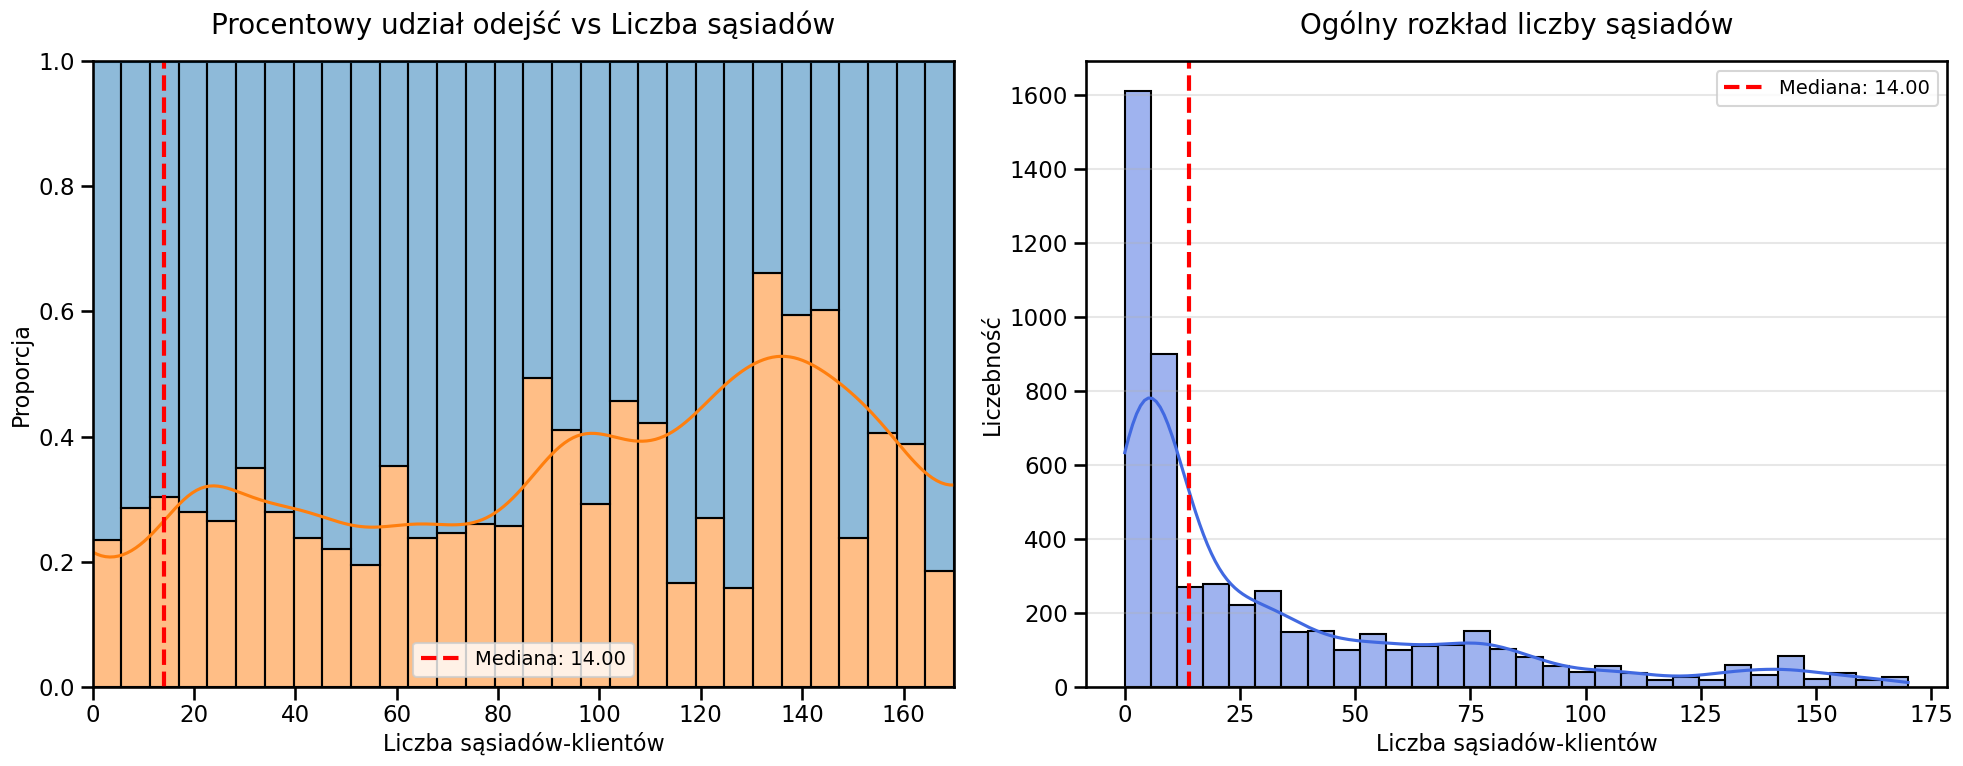

In [67]:
# Ustawienie stylu i bazowego kontekstu dla większych czcionek
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

sns.set_context("talk") # Automatycznie powiększa czcionki dla "prezentacji"
# *** WYKRES 1: Procentowy (Stacked/Fill) ***
sns.histplot(train, x='neighbors_within_10km', kde=True, bins=30, 
             hue='target', multiple='fill', ax=ax[0])

median_val = train['neighbors_within_10km'].median()
ax[0].axvline(median_val, color='red', lw=3, linestyle='--', 
              label=f'Mediana: {median_val:.2f}')

ax[0].set_title('Procentowy udział odejść vs Liczba sąsiadów', fontsize=20, pad=20)
ax[0].set_xlabel('Liczba sąsiadów-klientów', fontsize=16)
ax[0].set_ylabel('Proporcja', fontsize=16)
ax[0].legend(fontsize=14)

# *** WYKRES 2: Rozkład liczebności ***
sns.histplot(train, x='neighbors_within_10km', kde=True, bins=30, 
             ax=ax[1], color='royalblue')

ax[1].axvline(median_val, color='red', lw=3, linestyle='--', 
              label=f'Mediana: {median_val:.2f}')

ax[1].set_title('Ogólny rozkład liczby sąsiadów', fontsize=20, pad=20)
ax[1].set_xlabel('Liczba sąsiadów-klientów', fontsize=16)
ax[1].set_ylabel('Liczebność', fontsize=16)
ax[1].legend(fontsize=14)

# Estetyka siatki
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()


### Analiza Sąsiedztwa

W celu pogłębienia analizy geograficznej sprawdzono, czy gęstość zaludnienia (definiowana jako liczba sąsiadów w promieniu 10 km, analogicznie do parametrów użytych przy imputacji KNN) wpływa na skłonność klientów do rezygnacji.

#### Obserwacje:

* **Trend wzrostowy:** Analiza procentowego udziału rezygnacji w poszczególnych przedziałach gęstości wskazuje na pewną tendencję wzrostową — teoretycznie im więcej sąsiadów w okolicy, tym wyższe prawdopodobieństwo odejścia klienta.
* **Weryfikacja istotności:** Mimo zauważalnego trendu, analiza histogramu rozkładu liczebności grup podważa wagę tego wniosku. 
* **Brak silnego sygnału:** Wzrost proporcji osób, które odeszły dotyczy segmentów o bardzo niskiej liczebności (mała reprezentacja klientów w skrajnie gęsto zaludnionych obszarach). Oznacza to, że sygnał ten jest zbyt słaby i niestabilny, aby można było na jego podstawie definiować wiarygodne reguły biznesowe lub marketingowe.

## 3.4. Analiza korelacji i współzależności cech

Analiza korelacji stanowi kluczowy etap selekcji cech. Pozwala ona na zrozumienie wewnętrznych struktur danych oraz optymalizację wektora wejściowego dla modelu predykcyjnego.

### Cele analizy korelacji:

1. **Identyfikacja predyktorów:** Wskazanie zmiennych wykazujących najsilniejszy związek ze zmienną zależną. Pozwala to na usunięcie cech statystycznie nieistotnych, które wprowadzają szum informacyjny.
2. **Eliminacja multikolinearności:** Wykrycie par cech objaśniających, które są ze sobą silnie skorelowane (powyżej ustalonego poziomu). Usunięcie jednej z takich cech zapobiega dublowaniu informacji i stabilizuje proces uczenia modelu (szczególnie w przypadku modeli liniowych i regresji logistycznej).
3. **Redukcja wymiarowości:** Usunięcie zbędnych wymiarów nie tylko przyspiesza proces obliczeniowy, ale również przeciwdziała zjawisku "przekleństwa wymiarowości", poprawiając zdolności generalizacyjne modelu.



### Zastosowane metody:
W zależności od charakteru danych (numeryczne vs. kategoryczne), w dalszej części wykorzystano:

* **Korelację Persona** dla zmiennych ciągłych.
* **Współczynnik Phik** lub **Phik ($\phi_k$)** dla **wszystkich** typów zmiennych.
* **Mutual Information Score** jako dodatkowa metoda weryfikacji związku pomiędzy regresorami, a zmienną zależną

## 3.4.1. Współczynnik korelacji liniowej Pearsona ($r$)

Współczynnik korelacji Pearsona jest klasyczną metodą statystyczną służącą do badania siły i kierunku **liniowego związku** pomiędzy dwiema zmiennymi ilościowymi. Przyjmuje wartości z przedziału $[-1, 1]$, gdzie:

* **$1$:** oznacza idealną korelacje dodatnią,
* **$-1$:** oznacza idealną korelację ujemną,
* **$0$:** oznacza brak liniowej zależności.


#### Ograniczenia metody:
Pomimo swojej powszechności, metoda ta posiada istotne wady, które należy uwzględnić w procesie analizy:
|
* **Nieliniowość:** Korelacja Pearsona nie wykrywa zależności o charakterze nieliniowym. Zmienne mogą być od siebie silnie zależne, a współczynnik ten nadal może wynosić blisko 0.
* **Typ danych:** Metoda ta jest przeznaczona wyłącznie dla zmiennych ciągłych (numerycznych). Nie nadaje się do badania cech kategorycznych (nominalnych) ani porządkowych bez ich wcześniejszej transformacji.
* **Wrażliwość na wartości odstające:** Pojedyncze, skrajne obserwacje (*outliers*) mogą drastycznie zmienić wartość współczynnika, prowadząc do błędnych wniosków.

> **Wniosek projektowy:** W niniejszym raporcie korelacja Pearsona służy jedynie jako wstępny filtr dla zmiennych numerycznych. Aby uzyskać pełniejszy obraz współzależności, w kolejnych krokach zastosowano metody bardziej odporne na powyższe ograniczenia.

In [68]:
train['median_income'] = train['median_income'].fillna(train['imp_median_income']) # Pozostawienie jednej zmiennej opisującej przychód
train_trim = train.drop(['full_simp_col','full_imp_col','imp_mean_income','customer_id','zip_code','satisfaction_score','churn_reason','churn_category','imp_median_income'], axis=1)

In [69]:

# 1. Obliczamy korelację
corr_matrix = train_trim.corr(numeric_only=True)

# 2. Tworzymy heatmapę
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',       # Ograniczamy do 2 miejsc po przecinku dla przejrzystości
    aspect="auto",
    color_continuous_scale='RdBu_r', # Klasyczne kolory: czerwony (+) vs niebieski (-)
    zmin=-1, zmax=1,       # Stała skala korelacji
    title='Macierz korelacji Pearsona (zmienne numeryczne)',
    width=1200,
    height=1200
)

# 3. Tuning czytelności tekstu i osi
fig.update_layout(
    font=dict(size=10),              # Globalne zmniejszenie czcionki
    title_font_size=24,
    xaxis_tickangle=-45,             # Obrót etykiet na osi X
)

# 4. Kluczowe: Zmniejszenie czcionki wartości wewnątrz komórek
fig.update_traces(
    textfont=dict(size=9),           # Mniejszy tekst wewnątrz kwadratów
    hovertemplate='Zmienna X: %{x}<br>Zmienna Y: %{y}<br>Korelacja: %{z:.4f}<extra></extra>'
)

fig.show()

In [70]:
# Resetujemy indeks, aby nazwy zmiennych z wierszy stały się kolumną
corr_matrix_flat = corr_matrix.reset_index()
# Topimy tabelę
corr_tab = pd.melt(corr_matrix_flat, id_vars='index')
# Zmieniamy nazwy 
corr_tab.columns = ['var_1', 'var_2', 'korelacja']

In [71]:
# Sprawdzenie, jakie zmienne są ze sobą bardzo silnie skorelowane r > 0.9
print(corr_tab[(np.abs(corr_tab['korelacja'])>0.9) & (np.abs(corr_tab['korelacja'])<1)])

             var_1          var_2  korelacja
211  total_revenue  total_charges   0.970512
295  total_charges  total_revenue   0.970512


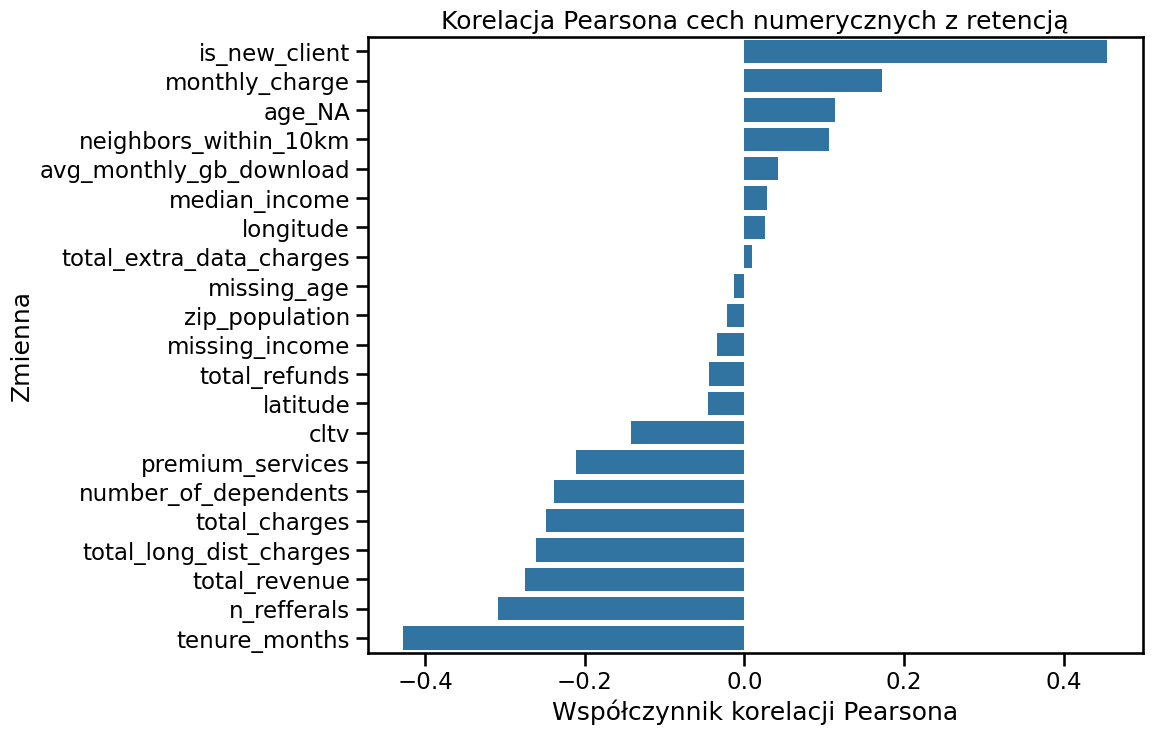

In [72]:
# Wyodrębnienie korelacji zmiennych z celem (target), pomijając korelację targetu z samym sobą [1:]
targ_corr = corr_matrix['target'].sort_values(ascending=False)[1:]

plt.figure(figsize=(10, 8))

# Wykres słupkowy pokazujący siłę i kierunek (dodatni/ujemny) korelacji
sns.barplot(y=targ_corr.index, x=targ_corr.values)

# Tytuł i opisy osi dokumentujące wpływ zmiennych numerycznych na churn
plt.title("Korelacja Pearsona cech numerycznych z retencją")
plt.xlabel("Współczynnik korelacji Pearsona")
plt.ylabel('Zmienna')

plt.show()

### Wnioski z analizy korelacji pearsona

### 1. Wysoce skorelowane predyktory (Multikolinearność)
Zidentyfikowano silną zależność między zmiennymi **Całkowite opłaty** (*Total Charges*) oraz **Całkowity wpływ finansowy klienta** (*Total Revenue*).

* **Współczynnik korelacji:** 0.97.
* **Interpretacja:** Jest to zależność logiczna – całkowity przychód z klienta jest bezpośrednio determinowany przez sumę wszystkich wniesionych przez niego opłat w trakcie trwania umowy.
* **Decyzja projektowa:** Aby uniknąć multikolinearności, jedna z tych zmiennych zostanie usunięta. Ostateczny wybór zostanie podjęty na podstawie kryterium **Mutual Information (MI)** w relacji do zmiennej celu. Wstępna analiza korelacją Pearsona sugeruje, że silniejszy związek z targetem wykazuje zmienna *Total Revenue*.

### 2. Korelacje ze zmienną celu
Najsilniejsze zaobserwowane związki ze zmienną celu mają charakter umiarkowany (maksymalnie $r \approx |0.4|$):

* **Staż klienta (Tenure):** Zmienne `staż w miesiącach` oraz `flaga reprezentująca nowego klienta` wskazują, że wraz ze wzrostem stażu klienta w firmie maleje prawdopodobieństwo rezygnacji (*churn*). Jest to typowe zjawisko budowania lojalności w czasie.
* **Liczba poleceń (Referrals):** Istnieje wyraźny związek między liczbą poleceń a retencją. Wraz ze wzrostem liczby osób, którym klient polecił usługi, maleje prawdopodobieństwo jego odejścia. Wniosek ten jest intuicyjny – zadowolony klient chętniej poleca markę i rzadziej planuje rezygnację z usług.

***

### Dalsze kroki
Biorąc pod uwagę specyficzne ograniczenia współczynnika korelacji liniowej, zdecydowano się zweryfikować powyższe zależności za pomocą dwóch dodatkowych metod:

___

## 3.4.2. Współczynnik korelacji $\phi_k$ (Phi K)

Współczynnik korelacji **$\phi_k$** to nowoczesna metoda badania zależności między zmiennymi, opracowana w 2018 roku przez Martina Baaka i jego zespół. Jej główną przewagą nad tradycyjnymi metodami jest uniwersalność – nie wymaga ona restrykcyjnych założeń dotyczących skali pomiarowej zmiennych oraz bez problemu radzi sobie z wykrywaniem nieliniowych związków.

### Mechanizm działania
Algorytm bazuje na teście statystycznym $\chi^2$. W uproszczeniu porównuje on dwa rozkłady: **wartości obserwowane** (rzeczywiste dane) oraz **wartości oczekiwane** (wynikające z założenia całkowitej losowości i braku zależności między zmiennymi).

***

### Proces obliczania współczynnika

1. **Dyskretyzacja**: Nawet w przypadku zmiennych ciągłych, algorytm dzieli je na przedziały, przekształcając je w zmienne o charakterze porządkowym.
2. **Tabela kontyngencji**: Tworzona jest macierz zliczeń, która sprawdza, ile obserwacji wpada w każdą kombinację kategorii zmiennej A i zmiennej B.
3. **Statystyka $\chi^2$**: Algorytm oblicza, jak bardzo zaobserwowana tabela różni się od modelu teoretycznej niezależności.
4. **Normalizacja i korekta**: Stosowana jest korekta oparta na dwuwymiarowym rozkładzie normalnym. Dzięki temu wynik końcowy zawsze mieści się w przedziale $[0, 1]$ i jest porównywalny niezależnie od typu danych.

***

### Kluczowe zalety

* **Wszechstronność**: Obsługuje wszystkie kombinacje typów danych (kategoryczne-kategoryczne, ciągłe-ciągłe, kategoryczne-ciągłe).
* **Zależności nieliniowe**: W przeciwieństwie do korelacji Pearsona, $\phi_k$ skutecznie wykrywa związki, które nie są liniowe.
* **Odporność**: Wykazuje dużą niewrażliwość na wartości odstające (*outliery*).

***

### Interpretacja wyników

| Wartość $\phi_k$ | Interpretacja |
| :--- | :--- |
| **0.0 – 0.1** | Brak lub bardzo słaby związek. |
| **0.1 – 0.3** | Słaby związek (często pomijalny w modelowaniu). |
| **0.3 – 0.7** | Umiarkowany do silnego związku (zmienne istotne dla modelu). |
| **0.7 – 0.9** | Bardzo silny związek (ryzyko współliniowości lub *przeciek danych*). |
| **1.0** | Zależność doskonała (zazwyczaj zmienne są swoimi pochodnymi). |

In [73]:
# W CELU OBLICZENIA PHI K NALEŻY WSKAZAĆ METODZIE, KTÓRE ZMIENNE SĄ NUMERYCZNE 
interval_cols = []
for col in train_trim.columns:
    if (train_trim[col].dtype in ['float64','int64']) and (len(train_trim[col].unique())>2):
        interval_cols.append(col)


In [74]:
# 1. Obliczamy korelację
phik_mat = train_trim.phik_matrix(interval_cols=interval_cols)

# 2. Tworzymy heatmapę
fig = px.imshow(
    phik_mat,             # Włączyłem wyświetlanie liczb (2 miejsca po przecinku)
    aspect="auto",
    # Zmiana: 'Reds' sprawia, że 0 jest białe, a 1 ciemnoczerwone
    color_continuous_scale='Reds', 
    zmin=0, zmax=1, 
    title='Macierz korelacji phi_k',
    width=1200,
    height=1200
)

# 3. Tuning układu
fig.update_layout(
    font=dict(size=10),
    title_font_size=24,
    xaxis_tickangle=-45,
    # Poprawa tytułu, bo to już nie Pearson
    title_text='Macierz korelacji phi-k'
)

# 4. Detale tekstu
fig.update_traces(
    textfont=dict(size=8),         # Mniejsza czcionka, żeby liczby się zmieściły
    hovertemplate='Zmienna X: %{x}<br>Zmienna Y: %{y}<br>Korelacja: %{z:.4f}<extra></extra>'
)

fig.show()

In [75]:
# Zresetowanie indeksu macierzy korelacji phik, aby nazwy zmiennych stały się kolumną
phik_mat_melted = phik_mat.reset_index()

# Przekształcenie macierzy (pivot table) w format długi (melted)
# id_vars='index' oznacza, że nazwy zmiennych z wierszy pozostają jako stałe punkty odniesienia
phik_mat_melted = pd.melt(phik_mat_melted, id_vars='index')

# Nadanie czytelnych nazw kolumnom: pierwsza zmienna, druga zmienna oraz ich współczynnik korelacji
phik_mat_melted.columns = ['var_1', 'var_2', 'korelacja']

In [76]:
# Filtrowanie par zmiennych o bardzo wysokiej korelacji (bezwzględna wartość > 0.9)
# Wykluczamy korelację równą 1.0, która dotyczy tych samych zmiennych
large_phis = phik_mat_melted[(np.abs(phik_mat_melted['korelacja']) > 0.9) & (np.abs(phik_mat_melted['korelacja']) < 1)]

# Tworzenie unikalnego identyfikatora dla pary zmiennych (sortowanie zapobiega dublowaniu par A-B i B-A)
large_phis['pair_id'] = large_phis.apply(lambda x: "-".join(sorted([x['var_1'], x['var_2']])), axis=1)

# Usunięcie zduplikowanych par, aby otrzymać czystą listę najsilniejszych powiązań w zbiorze
unique_pairs = large_phis.drop_duplicates(subset='pair_id')

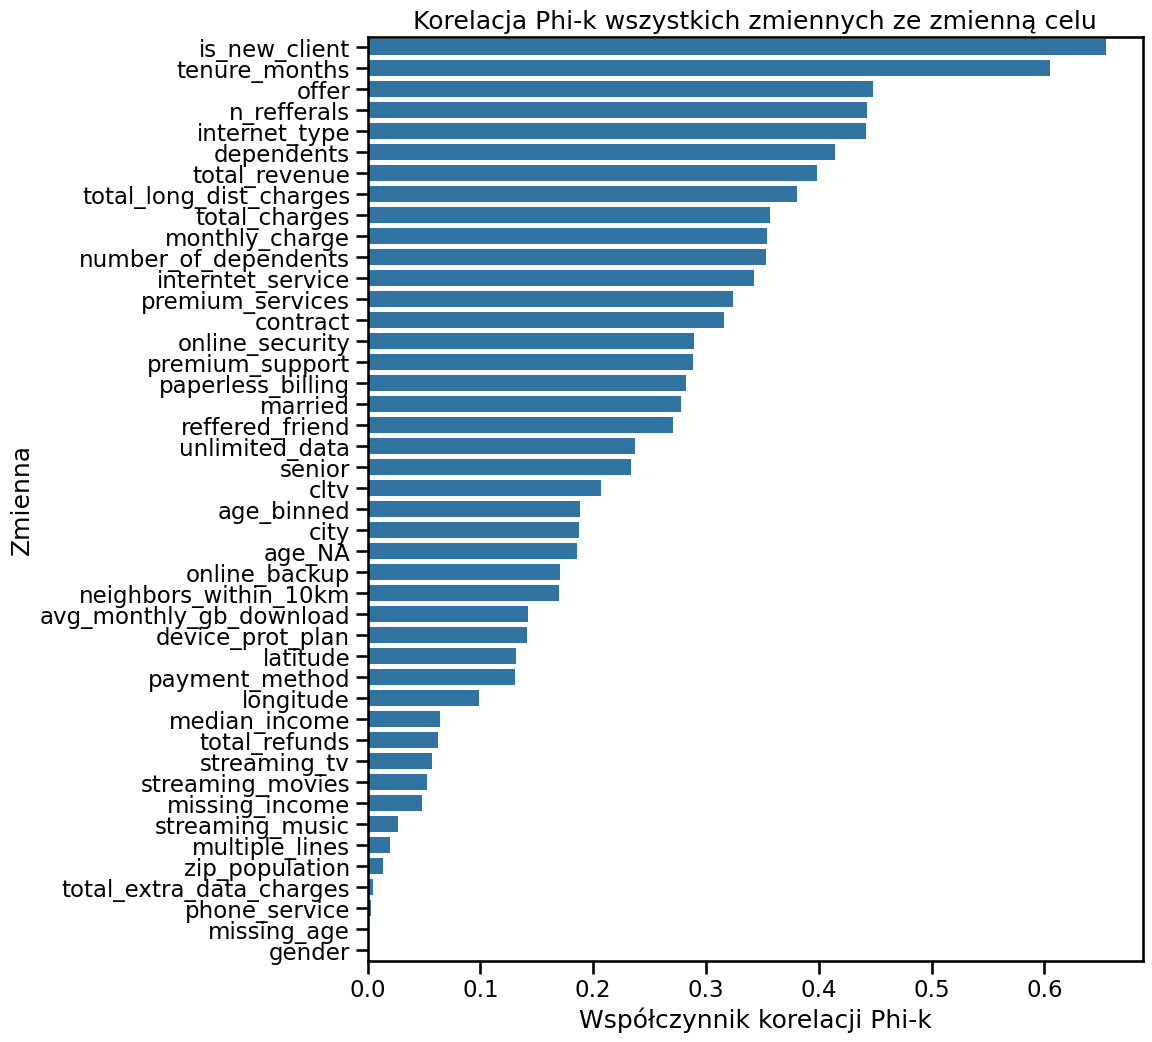

In [77]:
# Pobranie korelacji wszystkich zmiennych względem 'target' (bez korelacji własnej)
# Sortowanie malejące pozwala od razu zobaczyć najsilniejsze predyktory churnu
target_corr = phik_mat.sort_values(by='target', ascending=False)['target'][1:]

plt.figure(figsize=(10, 12))

# Wizualizacja siły powiązań cech ze zmienną celu na wykresie słupkowym
sns.barplot(y=target_corr.index, x=target_corr.values)

# Konfiguracja tytułu i etykiet osi dla raportu
plt.title("Korelacja Phi-k wszystkich zmiennych ze zmienną celu")
plt.xlabel("Współczynnik korelacji Phi-k")
plt.ylabel('Zmienna')

plt.show()

In [78]:
print(target_corr[target_corr < 0.1])

longitude                   0.098475
median_income               0.064662
total_refunds               0.062698
streaming_tv                0.056722
streaming_movies            0.052576
missing_income              0.047853
streaming_music             0.027041
multiple_lines              0.019896
zip_population              0.014089
total_extra_data_charges    0.005077
phone_service               0.003122
missing_age                 0.000000
gender                      0.000000
Name: target, dtype: float64


### Wnioski z analizy współczynnika $\phi_k$

Analiza dostarczyła istotnych informacji na temat struktury danych, potwierdzając wiele hipotez postawionych podczas wstępnej eksploracji (EDA).

### Kluczowe obserwacje:

* **Szeroka istotność predyktorów**: Większość zmiennych wykazuje istotny związek ze zmienną celu. Jedynie 14 predyktorów cechuje się współczynnikiem niższym niż 0.1, co sugeruje bogaty potencjał informacyjny zbioru danych.
* **Spójność metodologiczna**: W przypadku cech numerycznych wyniki $\phi_k$ są zbieżne z wynikami korelacji Pearsona, co zwiększa zaufanie do otrzymanych miar.
* **Potwierdzenie zależności kategorycznych**:

    * **Oferta i typ internetu**: Odnotowano umiarkowany związek między tymi cechami a zmienną celu. Potwierdza to numerycznie obserwacje z etapu EDA, gdzie te grupy wyraźnie różniły się pod kątem prawdopodobieństwa odejścia.
    * **Wiek (zdyskretyzowany)**: Zmienna wiek po podziale na przedziały okazuje się istotnym predyktorem w ujęciu $\phi_k$.
    * **Płeć**: Współczynnik potwierdza wcześniejsze założenia – płeć nie wykazuje niemal żadnego związku z targetem i nie stratyfikuje zbioru, co sugeruje jej niską przydatność w modelu.

***

### Dalsze działania i strategia selekcji cech

Pomimo zidentyfikowania zmiennych o niskiej korelacji, proces przygotowania danych będzie przebiegał według następujących zasad:

1. **Zastosowanie MI Score (Mutual Information)**:
   Metoda ta zostanie wykorzystana do ostatecznego rozstrzygnięcia, które zmienne usunąć w przypadku wystąpienia wysokiej współliniowości (np. wybór między *Total Charges* a *Total Revenue*).

2. **Konserwatywne podejście do usuwania cech**:
   Podjęto decyzję o **nieusuwaniu** cech o niskim natężeniu związku z targetem (z wyjątkiem tych o wartościach zerowych). 

> **Uzasadnienie**: Nowoczesne algorytmy, w tym **sieci neuronowe**, doskonale radzą sobie z wykrywaniem złożonych interakcji między cechami. Zmienna, która sama w sobie jest słabo skorelowana z targetem, może stać się kluczowa w połączeniu z innym predyktorem, znacząco wpływając na finalną precyzję modelu. Oczywiście po wstępnym etapie modelowania i analizie błędów może być konieczne usuwanie zmiennych (np. przez zjawisko przeuczenia).

## MISCORE 
Usuniete zostana zmienne o nizszej sile informacyjnej z par wspoliniowych oraz zmienne o nizzsyzm mi score niz losowy szum

In [79]:
# Ustawienie ziarna losowości dla powtarzalności wyników
np.random.seed(RANDOM_STATE)

# Dodanie kolumny z czystym szumem losowym jako punktu odniesienia (benchmark)
# Jeśli cecha ma MI score niższy niż ten szum, prawdopodobnie nie wnosi żadnej informacji
train_trim['random_noise'] = np.random.rand(len(train))

# Konwersja pozostałych zmiennych kategorycznych na format numeryczny (faktoryzacja)
# Niezbędne dla poprawnego działania algorytmu mutual_info_classif
for col in train_trim.select_dtypes(['object', 'category']).columns:
    train_trim[col], _ = train_trim[col].factorize()

# Podział na macierz cech i zmienną celu (target)
X_tt_mi = train_trim.drop(['target'], axis=1)
y_tt_mi = train_trim['target']

# Obliczenie Mutual Information (MI) dla klasyfikacji
# Mierzy zależność między zmiennymi a prawdopodobieństwem churnu
mutual_info = mutual_info_classif(X_tt_mi, y_tt_mi, random_state=RANDOM_STATE)

# Przekształcenie wyników w czytelną tabelę DataFrame i sortowanie
mutual_info = pd.DataFrame(mutual_info)
mutual_info.index = X_tt_mi.columns
mutual_info.columns = ['mi_score']
mi_score = mutual_info.sort_values(by='mi_score', ascending=False)

In [80]:
print(unique_pairs)

                var_1              var_2  korelacja  \
82             age_NA             senior   0.995284   
87         age_binned             senior   0.994035   
100   reffered_friend            married   0.996314   
580     is_new_client      tenure_months   0.976524   
746    unlimited_data  interntet_service   0.923235   
750    monthly_charge  interntet_service   0.998992   
791    unlimited_data      internet_type   0.923217   
1105  streaming_music   streaming_movies   0.969711   
1430    total_revenue      total_charges   0.931621   
1707       age_binned             age_NA   0.991453   

                               pair_id  
82                       age_NA-senior  
87                   age_binned-senior  
100            married-reffered_friend  
580        is_new_client-tenure_months  
746   interntet_service-unlimited_data  
750   interntet_service-monthly_charge  
791       internet_type-unlimited_data  
1105  streaming_movies-streaming_music  
1430       total_charges-

In [81]:
print(mi_score)

                          mi_score
tenure_months             0.159760
contract                  0.150037
is_new_client             0.095944
total_charges             0.093570
total_revenue             0.093285
total_long_dist_charges   0.082688
n_refferals               0.067547
offer                     0.056999
number_of_dependents      0.047010
monthly_charge            0.046788
dependents                0.046751
internet_type             0.044284
interntet_service         0.037654
avg_monthly_gb_download   0.035580
payment_method            0.034623
latitude                  0.032782
longitude                 0.031383
neighbors_within_10km     0.030695
premium_services          0.028815
median_income             0.026410
premium_support           0.024328
unlimited_data            0.018222
married                   0.017580
reffered_friend           0.017299
online_security           0.017130
paperless_billing         0.017100
streaming_tv              0.015239
cltv                

In [83]:
train_trim = train_trim.drop(['age_NA','senior','married','is_new_client',
                              'interntet_service','unlimited_data','streaming_music',
                              'total_revenue','gender','phone_service','random_noise'], axis=1)

### Usuwanie zmiennych o wysokiej współliniowości

Na podstawie analizy macierzy korelacji $\phi_k$ oraz wyników Mutual Information (MI Score), podjęto decyzję o usunięciu nadmiarowych predyktorów. Celem jest uproszczenie modelu i usunięcie zmiennych niosących praktycznie te same informacje.

### 1. Grupa zmiennych demograficznych (Wiek)
Zmienne `Wiek`, `Senior` oraz `Wiek przedziały` są bezpośrednimi pochodnymi wieku.

* **Decyzja:** Usuwamy zmienne `Wiek` oraz `Senior`.
* **Uzasadnienie:** Pozostawienie zmiennej zbinowanej (pogrupowanej w przedziały) pozwala lepiej uchwycić nieliniowe zależności związane z grupami wiekowymi.

### 2. Relacja małżeństwa i poleceń
Analiza wykazała, że zmienne `W związku małżeńskim` oraz `Polecił znajomego` są niemal identyczne (praktycznie każda osoba w małżeństwie poleciła usługi).

* **Decyzja:** Usuwamy zmienną `W związku małżeńskim`.
* **Uzasadnienie:** Zmienna `Polecił znajomego` jest bezpośrednio powiązana z liczbą poleceń (`Liczba poleceń`), co czyni ją bardziej wartościową w kontekście analizy zachowań klientów.

### 3. Staż klienta
Zmienna `Jest nowym klientem` świetnie stratyfikuje zbiór, ale jest całkowicie redundantna względem czasu trwania umowy.

* **Decyzja:** Usuwamy zmienną `Jest nowym klientem`.
* **Uzasadnienie:** Informacja o "nowości" klienta wynika bezpośrednio z niskich wartości w zmiennej `Miesiące stażu`.

### 4. Usługi internetowe i pakiety danych
Zidentyfikowano silną korelację między typem internetu, pakietem nielimitowanym a opłatami miesięcznymi.

* **Decyzja:** Usuwamy zmienne `Usługa internetowa` oraz `Nielimitowane dane`.
* **Uzasadnienie:** Pozostawienie zmiennej `Opłaty miesięczne` oraz typu połączenia pozwala zachować wyższą wartość informacyjną przy mniejszej liczbie wymiarów.

### 5. Usługi streamingowe
Zmienne `Streaming muzyki` oraz `Streaming filmów` niosą bardzo podobną informację.

* **Decyzja:** Usuwamy zmienną `Streaming muzyki`.

### 6. Przychody i opłaty całkowite
Pary zmiennych `Całkowity przychód` oraz `Opłaty całkowite` wykazały korelację na poziomie 0.97.

* **Decyzja:** Usuwamy zmienną `Całkowity przychód`.
* **Uzasadnienie:** Obie zmienne mają zbliżony wynik MI Score, jednak `Opłaty całkowite` wykazują nieco wyższą stabilność w relacji do pozostałych predyktorów.

___

## Usuwanie szumu informacyjnego (MI Score = 0)
Po przeprowadzeniu analizy ważności cech metodą Mutual Information, zauważono, że niektóre zmienne stanowią jedynie losowy szum i nie niosą żadnej wartości prognostycznej dla modelu.

* **Decyzja:** Usuwamy wszystkie zmienne, dla których współczynnik MI Score wynosi 0.
* **Wyjątek:** Zmienna `Brakujący wiek` zostaje zachowana w zbiorze danych.
* **Uzasadnienie:** Mimo zerowej korelacji bezpośredniej, zmienna ta jest kluczowym indykatorem technicznym informującym model o tym, że w danym rekordzie dokonano imputacji danych . Może to mieć znaczenie dla interpretacji wiarygodności pozostałych cech demograficznych przez algorytm.

___


#### Model miał problem z eksplodującym gradientem. a potem poprostu z underfittingiem. Przy 100 epokach funkcja kosztu w zasadzie stała w miejscu. Przyczyny upatruje się w zbyt dużej ilości cech jak na liczbę obserwacji.

Dodatkowa selekcja obejmie budowę modela random forest w celu poznania względnej istotności cech

## 3.5. WARTOŚCI ODSTAJĄCE 

Analiza wartości nietypowych (outlierów) jest kluczowym etapem przygotowania danych, gdy celem jest modelowanie predykcyjne. Wartości odstające potrafią znacząco zaburzyć rozkład cech, co prowadzi do błędnej estymacji parametrów statystycznych (np. średniej i wariancji) i utrudnia modelowi wyłapanie generalnych trendów. W efekcie może to skutkować **overfittingiem** (przeuczeniem) lub niską precyzją modelu na danych testowych.

W niniejszym projekcie wykorzystano algorytm **Isolation Forest** (Las Izolacyjny), który wyróżnia się unikalnym podejściem do detekcji anomalii:

#### Mechanizm działania:

* **Izolacja zamiast modelowania profilu:** W przeciwieństwie do tradycyjnych metod (np. opartych na odległościach czy gęstości), las izolacji nie próbuje definiować "normalności". Zamiast tego skupia się bezpośrednio na izolowaniu anomalii.
* **Struktura drzewiasta:** Algorytm buduje strukturę drzew binarnych. Dla każdego podziału losowana jest cecha, a następnie losowana jest wartość podziału z zakresu między wartością minimalną a maksymalną tej cechy.
* **Kryterium decyzji:** Ponieważ wartości odstające zazwyczaj posiadają nietypowe wartości cech, wymagają one znacznie mniejszej liczby podziałów, aby zostać odizolowanymi od reszty zbioru. Oznacza to, że znajdują się one bliżej korzenia drzewa (mają krótszą tzw. *ścieżkę średnią*).



#### Uzasadnienie wyboru metody

1. **Wysoka wymiarowość:** Zbiór zawiera wiele wymiarów (po selekcji cech = 35). Algorytm ten zachowuje wysoką wydajność obliczeniową nawet przy dużej liczbie zmiennych.
2. **Brak założeń o rozkładzie:** Metoda ta nie wymaga, aby dane miały rozkład normalny, co jest istotne w przypadku zmiennych takich jak miesięczne opłaty, która wykazuje silną prawostronną asymetrię.
3. **Globalne spojrzenie:** Metoda potrafi wykrywać w

#### Znaczenie w kontekście Sieci Neuronowych:
Wybór Isolation Forest jako narzędzia do czyszczenia danych jest szczególnie istotny w przypadku planowanego wykorzystania **Głębokiego Uczenia**:

* **Stabilność Gradientu:** Sieci neuronowe uczą się poprzez minimalizację funkcji straty (np. Binary Cross-Entropy). Obserwacje o ekstremalnych wartościach generują bardzo duże błędy, co prowadzi do gwałtownych skoków gradientu. Może to spowodować tzw. *exploding gradient problem* lub sprawić, że proces optymalizacji nigdy nie osiągnie globalnego minimum.
* **Wpływ na Normalizację:** Sieci neuronowe wymagają skalowania danych. Pojedyncza, ekstremalna wartość odstająca może "scisnąć" pozostałe 99% danych do bardzo wąskiego zakresu (np. [0, 0.01]), co drastycznie ogranicza zdolność sieci do rozróżniania istotnych cech klientów Telco.

#### Interpretacja i wdrożenie:
Po uruchomieniu algorytmu, każda obserwacja otrzymuje **Anomaly Score**. Wartości poniżej bliskie 0 wskazują na anomalie, natomiast te bliżej 1 oznaczają wartości typowe. Rekordy zaklasyfikowane jako outliery zostaną poddane szczegółowej analizie w celu podjęcia decyzji o ich usunięciu lub odpowiedniej transformacji.

In [ ]:
# wszystkie usuniete kolumny
['full_simp_col','full_imp_col','imp_mean_income','customer_id','zip_code','satisfaction_score','churn_reason','churn_category','imp_median_income']
['age_NA','senior','married','is_new_client','interntet_service','unlimited_data','streaming_music','total_revenue']

## 3.5.1. Analiza wizualna i ograniczenia metod klasycznych

In [ ]:
# Przygotowanie ostatecznego zbioru danych na podstawie wcześniej wyselekcjonowanych kolumn
train_fin = train[train_trim.columns]

# Wyłonienie wyłącznie kolumn numerycznych do analizy statystycznej
numcols = [numcol for numcol in train_fin.select_dtypes(['int64', 'float64'])]
train_numeric = train_trim[numcols]

# Inicjalizacja siatki wykresów (3 wiersze na 6 kolumn)
fig, ax = plt.subplots(ncols=6, nrows=3, figsize=(15, 10))

# Spłaszczenie tablicy osi z formatu (3, 6) do (18,), co pozwala na użycie jednego indeksu w pętli
ax = ax.flatten()

# Iteracja po słowniku kolumn (k - nazwa, v - wartości)
idx = 0
for k, v in train_numeric.items():
    # Rysowanie wykresu pudełkowego dla każdej zmiennej numerycznej
    sns.boxplot(y=k, data=train_numeric, ax=ax[idx])
    idx += 1

# Automatyczne dopasowanie układu, aby uniknąć nakładania się opisów osi
plt.tight_layout()

Na wygenerowanej siatce wykresów pudełkowych można zauważyć, że wiele zmiennych dotyczy problem wartości skrajnych według standardowego kryterium $1.5 \times IQR$ (rozstępu kwartylowego). Należy jednak podejść do nich z dużą ostrożnością:

* **Specyfika zmiennych:** Wartości skrajne w zmiennych takich jak `liczba osób korzystających z umowy (var. Number of Dependents)`, `Całkowite dodatkowe opłaty za dane (var. Total Extra Data Charges)` czy `populacja per kod pocztowy (var. Zip Population)` nie muszą oznaczać błędów czy niepożądanych anomalii. 
* **Problem dominanty i asymetrii:** W przypadku tych cech dominanta jest silnie skupiona wokół zera, a rozkłady są **silnie prawostronnie asymetryczne**. 
* **Przykład `Total Refunds`:** Metoda IQR uznała niemal wszystkie wartości różne od zera za odstające. Wynika to z faktu, że większość klientów nie otrzymuje zwrotów. Zastosowanie w tym przypadku **winsoryzacji** lub usuwania rekordów skutkowałoby utratą cennych informacji, które są naturalnym elementem procesów biznesowych.


#### Kluczowe wnioski z analizy lokalnej:
Wykresy skrzynkowe obrazują outliery jedynie w **ujęciu lokalnym** (analiza jednowymiarowa rozkładu konkretnej cechy). Ich główną wadą w kontekście sieci neuronowych jest:

1. **Brak kontekstu wielowymiarowego:** Nie uwzględniają współwystępowania zmiennych (np. wysoka opłata dodatkowa może być anomalią dla klienta z niskim abonamentem, ale być normą dla klienta biznesowego).
2. **Ryzyko utraty sygnału:** Agresywne czyszczenie danych na podstawie samych boxplotów mogłoby pozbawić model kluczowych informacji o zachowaniach klientów rezygnujących (Churn).

Dlatego też, zamiast prostych metod statystycznych, w dalszej części zdecydowano się na wykorzystanie wspomnianego wcześniej algorytmu **Lasu izolacji**, który analizuje outliery w przestrzeni wielowymiarowej.
___

## 3.5.2. Budowa modelu 

Las izolacji (**Isolation Forest**) jest metodą nienadzorowaną, co oznacza, że nie posiada on etykiet pozwalających na bezpośrednią obiektywną ocenę dokładności. Z tego powodu wybór optymalnego modelu wymaga alternatywnych podejść. W niniejszej analizie wykorzystano **metodę graficzną**, która polega na wizualizacji rozkładu współczynnika anomalii (ang. Anomaly Score).

#### Podstawy matematyczne
Oryginalna formuła współczynnika anomalii, zaproponowana przez autorów metody, zdefiniowana jest jako:

$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$

Gdzie:

* $h(x)$: długość ścieżki punktu danych $x$ w danym drzewie izolacji.
* $E(h(x))$: wartość oczekiwana długości ścieżki ze wszystkich drzew w lesie dla danego punktu x.
* $c(n)$: średnia długość ścieżki dla nieudanego wyszukiwania w binarnym drzewie poszukiwań (BST), służąca jako baseline do normalizacji przy wielkości próbki $n$.



#### Implementacja w bibliotece Scikit-Learn
W wykorzystanej bibliotece formuła ta została zmodyfikowana, aby ułatwić interpretację wyników. Wynik jest wycentrowany wokół zera:

$$\text{score} = 0.5 - s(x, n)$$

Dzięki temu:

* **Wartości ujemne:** oznaczają outliery (punkty o krótkich ścieżkach).
* **Wartości dodatnie:** oznaczają typowe obserwacje (normalne).

Podczas analizy wykresu szukamy tzw. **punktu załamania**  – momentu, w którym następuje gwałtowny skok lub spadek wartości współczynnika, co sugeruje naturalną granicę między szumem a poprawnymi danymi.

***

### Najważniejsze hiperparametry modelu Isolation Forest

W celu optymalizacji procesu detekcji anomalii kluczowe jest skonfigurowanie parametrów wpływających na proces budowy drzew:

* **`n_estimators`**: Liczba drzew izolacyjnych w lesie. 

    * Większa liczba drzew prowadzi do stabilniejszych wyników poprzez "wygładzenie" rozkładu ocen, jednak zwiększa koszt obliczeniowy. Wartości rzędu 100–200 są zazwyczaj wystarczające do uzyskania konwergencji.
    
* **`contamination`**: Określa oczekiwaną proporcję wartości odstających w zbiorze. Jest to najważniejszy hiperparametr, który będzie optymalizowany

    * `'auto'`: Poziom ustalany na podstawie wzorów z pierwotnej pracy naukowej.
    * `float (0.0, 0.5]`: Pozwala ręcznie zdefiniować dopuszczalny procent outlierów (np. 0.05 dla 5% danych).

***

W niniejszym etapie zmienne zostaną zakodowane przy użyciu **Kodowania ordynarnego**. Na pierwszy rzut oka może się to wydawać nieintuicyjne, ponieważ zmienne nominalne (nieposiadające naturalnej kolejności) są standardowo kodowane metodą *One-Hot Encoding*. Jednak w przypadku modeli opartych na strukturach drzewiastych, takich jak **Isolation Forest** czy **Random Forest**, zastosowanie kodowania porządkowego jest nie tylko dopuszczalne, ale często bardziej efektywne z kilku kluczowych powodów:

#### 1. Mechanizm podziału węzła
W przeciwieństwie do modeli liniowych, drzewa decyzyjne nie przypisują wag cechom w sposób ciągły i nie zakładają relacji liniowej między wartościami. Drzewo dzieli przestrzeń cech na podzbiory poprzez progi (np. $x < 2.5$). Dzięki temu algorytm jest w stanie "wyizolować" konkretną kategorię ukrytą pod liczbą całkowitą, wykonując sekwencję odpowiednich podziałów. Pozwala to modelowi na grupowanie kategorii o podobnej charakterystyce bez konieczności tworzenia osobnych wymiarów.

#### 2. Unikanie "Klątwy Wymiarowości"
Stosowanie **One-Hot Encodingu** przy zmiennych o wysokiej kardynalności prowadzi do powstania ogromnej liczby rzadkich kolumn, składających się głównie z zer. Ma to negatywne skutki:

* **Rozproszenie znaczenia cechy:** Informacja o jednej zmiennej zostaje rozbita na wiele słabych cech, co utrudnia drzewom znalezienie optymalnych punktów podziału.
* **Obciążenie obliczeniowe:** Znacząco zwiększa się zapotrzebowanie na pamięć RAM i czas procesora, co jest nieefektywne przy dużych lasach izolacji.

In [ ]:
# Wyłonienie zmiennych kategorycznych do zakodowania (Ordinal Encoding)
catcols = [col for col in train_fin.select_dtypes(['object', 'category'])]

# Podział na macierz cech (X) i zmienną celu (y)
X_fin = train_fin.drop(['target'], axis=1)
y_fin = train_fin['target']

# Konfiguracja transformatora: kodowanie porządkowe dla kategorii, reszta zmiennych bez zmian
ct = ColumnTransformer(
    transformers=[
        ('encoder', OrdinalEncoder(), catcols) 
    ], 
    verbose_feature_names_out=False,
    remainder='passthrough'
)

# Transformacja danych do postaci numerycznej akceptowanej przez model
X_enc = ct.fit_transform(X_fin)

# Inicjalizacja Isolation Forest: 
# contamination=0.02 oznacza, że spodziewamy się około 2% anomalii w zbiorze
iforest = IsolationForest(n_estimators=500, contamination=0.02, random_state=RANDOM_STATE)
iforest.fit(X_enc)

# Predykcja: 1 dla normalnych rekordów, -1 dla wykrytych anomalii
y_pred = iforest.predict(X_enc)

# Dodanie wyników do głównej ramki: 
# 'anom_scores' – im niższy wynik, tym bardziej rekord jest anomalny
train_fin['anom_scores'] = iforest.decision_function(X_enc)
train_fin['anomaly_label'] = y_pred

# Wyświetlenie liczby zidentyfikowanych outlierów
print(f'Outliers: {train_fin[train_fin["anomaly_label"]==-1].shape[0]}')

## 3.5.3. Dobór parametru Zanieczyszczenia (ang. Contamination)

Pierwszym etapem optymalizacji modelu jest wybór kluczowego parametru **`contamination`**, który determinuje czułość algorytmu na anomalie. W procesie wstępnej eksploracji danych (EDA) stwierdzono, że zbiór jest relatywnie czysty i wolny od skrajnie dużych odchyleń, co sugeruje potrzebę zachowania ostrożności przy usuwaniu rekordów.

#### Pierwsza iteracja modelu:
W pierwszej próbie parametr `contamination` ustawiono na wartość **0.05 (5%)**. Liczbę estymatorów ustalono na **500**.

![Rozkład anom scores wg isoforest](../data/report_materials/fig1.png)

**Wnioski z pierwszej iteracji:**
Na powyższym wykresie zaobserwowano, że granica 5% została dobrana **zbyt agresywnie**. Wartości uznane za normalne przechodzą w outliery w sposób bardzo płynny, bez wyraźnej separacji. Takie podejście niesie ryzyko usunięcia poprawnych, choć rzadszych profili klientów (co w przypadku modelu Churn może prowadzić do utraty kluczowych wzorców rezygnacji).

#### Dobór parametrów końcowych:
Zauważono jednak istotny uskok w rozkładzie punktów, znajdujący się nieco dalej na osi wyników. W związku z tym:

* Podjęto decyzję o zmianie parametru `contamination` na poziom **0.02 (2%)**.
* Pozwala to na uchwycenie jedynie najbardziej odizolowanych punktów, gdzie na granicy obu grup widoczny jest wyraźny skok wartości współczynnika.
* Takie podejście minimalizuje ryzyko utraty sygnału przy jednoczesnym zabezpieczeniu sieci neuronowej przed najbardziej skrajnymi przypadkami.

### Wykres przedstawiający Finalną klasyfikację obserwacji nietypoweych

In [ ]:
train_fin['anomaly'] = train_fin['anomaly_label'].apply(lambda x: 'outlier' if x==-1 else 'inliner')

fig=px.histogram(train_fin, x='anom_scores',color='anomaly',
                 height=800,
                 width=1200)
fig.show()
# fig.write_image("../fig1.png")


## 3.5.4. Interpretacja i zrozumienie modelu 

Zaawansowane algorytmy uczenia maszynowego, takie jak **Random Forest**, **Isolation Forest** czy **Sztuczne Sieci Neuronowe (ANN)**, są niezwykle potężnymi narzędziami, jednak nie są pozbawione wad. Ich głównym ograniczeniem jest ograniczona interpretowalność w przeciwieństwie do klasycznych metod statystycznych, takich jak **GLM** (uogólnione modele liniowe), mechanizm podejmowania decyzji przez te modele jest znacznie trudniejszy do bezpośredniego prześledzenia przez analityka.

#### Dekompozycja "Czarnej Skrzynki"
Pierwszym krokiem, który pozwala przybliżyć zasadę działania lasu izolacji (choć nie stanowi pełnej interpretacji modelu), jest **wizualizacja pojedynczego drzewa izolacyjnego**. Pozwala to na naoczne sprawdzenie, w jaki sposób algorytm dokonuje losowych podziałów przestrzeni cech w celu odseparowania obserwacji.



Wizualizacja ta pozwala zrozumieć:

* **Proces izolacji:** Jak szybko (na jakiej głębokości) poszczególne rekordy trafiają do liści.
* **Strukturę podziałów:** Które cechy zostały wylosowane jako pierwsze w danym drzewie.
* **Koncepcję krótkiej ścieżki:** Dlaczego punkty znajdujące się bliżej korzenia (wymagające mniejszej liczby pytań/podziałów) są klasyfikowane jako anomalie.

Chociaż pojedyncze drzewo jest tylko ułamkiem całego modelu, jego analiza pomaga zwizualizować intuicję stojącą za tym jak działa model 

> Podkreśla się, że wartości zmiennych kategorycznych na wykresie wyrażone są liczbowo, przez 
***

In [ ]:
# Wybranie konkretnego estymatora (drzewa nr 450) z wytrenowanego lasu
estimator = iforest.estimators_[450]

# Eksport struktury drzewa do formatu .dot (ograniczony do głębokości 3 dla czytelności)
# max_depth=3 pozwala skupić się na najważniejszych, początkowych podziałach
export_graphviz(estimator, out_file='tree.dot', max_depth=3,
                feature_names=X_enc.columns, filled=True,
                special_characters=True, rounded=True, precision=2)

# Wywołanie systemowe narzędzia Graphviz w celu wygenerowania pliku PNG o wysokiej rozdzielczości (600 DPI)
call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

# Wyświetlenie wygenerowanego rysunku drzewa bezpośrednio w notatniku/raporcie
Image(filename='tree.png')

Na powyższym wykresie zauważyć można przykładową strukturę drzewa z lasu izolacji. Ponadto widoczna na nim jest ścieżka, która doprowadziła do wyizolowania pojedynczej obserwacji. 

**Wnioski:**

* **Interpretacja a kodowanie:** Jak wspomniano wcześniej, model był trenowany na danych przetworzonych za pomocą `OrdinalEncoder`. Powoduje to, że bezpośrednia interpretacja wartości numerycznych w węzłach (np. *City < 9.89*) jest utrudniona bez odwołania się do słownika kodowań.
* **Logika anomalii:** W skrócie, algorytm wykrył, że specyficzna kombinacja cech — w tym przypadku konkretnego miasta oraz typu oferty występuje w zbiorze na tyle rzadko, że wyróżnia się na tle całej populacji. 
* **Wielowymiarowość:** Jest to doskonały przykład przewagi **Isolation Forest** nad metodami jednowymiarowymi. Pojedyncze miasto czy oferta same w sobie nie są anomalią, ale ich **współwystępowanie** zostało uznane przez model za skrajnie nietypowe i sklasyfikowane jako wartość odstająca (W tym konkretnym drzewie). 

In [ ]:
# Dodanie etykiety anomalii do listy kolumn numerycznych w celu wizualizacji
numcols.append('anomaly_label') 

# Tworzenie macierzy wykresów punktowych (pairplot)
# hue='anomaly_label' pokoloruje punkty, odróżniając normalnych klientów od wykrytych anomalii
sns.pairplot(train_fin[numcols], hue='anomaly_label', palette={1: 'seagreen', -1: 'red'}, plot_kws={'alpha': 0.5})

# Wyświetlenie wykresu
plt.show()

Macierz wykresów punktowych jest klasyczną metodą walidacji wyników analizy wartości skrajnych. Pozwala ona na ocenę separacji zidentyfikowanych anomalii względem par zmiennych w przestrzeni dwuwymiarowej.

Ograniczenia wizualizacji: Ze względu na wysoką wymiarowość oraz dużą liczebność naszego zbioru danych, poniższy wykres cechuje się znacznym zagęszczeniem punktów (overplotting). Z tego powodu jego czytelność jest ograniczona i należy go traktować jako materiał poglądowy, a nie główne narzędzie analityczne.

Wnioski: Mimo ograniczeń wizualnych, wykres pozwala wstępnie potwierdzić skuteczność modelu Isolation Forest. Widać wyraźnie, że algorytm nie odciął jedynie skrajnych wartości na pojedynczych osiach (co zrobiłby prosty filtr), lecz zidentyfikował wartości odstające w ujęciu globalnym, uwzględniając nietypowe korelacje między zmiennymi.

## 3.5.5. Walidacja wyników i porównanie metod

W celu weryfikacji skuteczności modelu, ze zbioru usunięto zidentyfikowane wartości odstające (**106 rekordów**, co stanowi ok. 2% zbioru). Następnie wygenerowano analogiczną siatkę wykresów pudełkowych jak na początku rozdziału 3.5., aby porównać rozkłady cech przed i po interwencji algorytmu Isolation Forest.


In [ ]:
numcols.remove('anomaly_label')
train_numeric = train_fin[train_fin['anomaly_label']== 1][numcols]

fig, ax = plt.subplots(ncols = 6, nrows = 3, figsize = (15,10)) #ax to array o wymiarach (3,6)
fig.suptitle('Rozkłady cech ilościowych po usunięcio wartości skrajnych')
idx = 0
ax= ax.flatten() # wyplaszcza nam array do wymiarow (18,1) Umozliwa to proste iterowanie po wykresach

for k,v in train_numeric.items(): # Iterowanie jak po dictionary (key = nazwa kolumny, value = wektor wartosci )
    sns.boxplot(y=k,data=train_numeric, ax=ax[idx])
    idx += 1

plt.tight_layout()

### Wnioski z porównania:

* **Potwierdzenie analizy lokalnej:** Analiza wizualna po usunięciu anomalii potwierdziła wcześniejsze przypuszczenia. Wykresy skrzynkowe wyglądają niemal identycznie jak przed procesem czyszczenia.
* **Globalna vs. Lokalna charakterystyka:** Wynik ten wskazuje, że wartości przekraczające próg $1.5 \times IQR$ w większości przypadków **nie są wartościami odstającymi w ujęciu globalnym**. Są one naturalnym elementem rozkładu asymetrycznego danej zmiennej, a nie błędami czy nietypowymi zachowaniami.

## 3.5.6. Wizualizacja t-SNE  - Wielowymiarowy rozkład decyzji modelu

**t-SNE** (*t-distributed Stochastic Neighbor Embedding*) to nieliniowa, nienadzorowana i stochastyczna metoda redukcji wymiarowości. Wykorzystuje ona rozkład t-Studenta do zachowania relacji między sąsiadami, co czyni ją jednym z najlepszych narzędzi do eksploracyjnej wizualizacji danych wysokowymiarowych w przestrzeni 2D lub 3D.

#### Cel algorytmu:
Algorytm przekształca zestaw punktów z przestrzeni wielowymiarowej na przestrzeń o niskiej wymiarowości (2D), starając się wiernie odzwierciedlić podobieństwa między obserwacjami. Punkty podobne w przestrzeni wielowymiarowej powinny znaleźć się blisko siebie na wykresie t-SNE.

#### Kluczowe parametry i proces optymalizacji:

* **Perplexity**: Odpowiada za balansowanie uwagi między lokalnymi a globalnymi aspektami danych. Można go interpretować jako oczekiwaną liczbę bliskich sąsiadów dla każdego punktu. 
    * *Dobra praktyka:* Należy analizować wykresy dla różnych wartości `perplexity`, aby upewnić się, że struktura klastrów jest stabilna.
* **Iteracyjność**: Proces wymaga odpowiedniej liczby kroków optymalizacji. Jeśli na wykresie widać nienaturalne, "spiczaste" kształty, oznacza to zazwyczaj zbyt wczesne zatrzymanie algorytmu przed osiągnięciem stabilnej konfiguracji.

***

#### Ważne zasady interpretacji (tzw. Pułapki t-SNE):

Podczas analizy wyników t-SNE należy pamiętać o czterech fundamentalnych zasadach, aby uniknąć błędnych wniosków:

1. **Rozmiary skupień nie mają znaczenia**: Algorytm t-SNE automatycznie "rozciąga" gęste klastry i "ściska" te rzadkie, aby poprawić czytelność. Nie można więc wnioskować o relatywnej wariancji lub rozmiarze skupienia na podstawie jego powierzchni na wykresie.
2. **Odległości między skupieniami mogą być mylące**: Odległość między dwoma klastrami na wykresie 2D nie musi odzwierciedlać ich rzeczywistego dystansu w przestrzeni wielowymiarowej. Zależy to silnie od wybranego parametru *perplexity*.
3. **Losowy szum nie zawsze wygląda losowo**: t-SNE ma tendencję do znajdowania "struktur" nawet w całkowicie losowych danych. Należy zachować sceptycyzm i nie doszukiwać się klastrów tam, gdzie ich nie ma.
4. **Weryfikacja stabilności**: Ze względu na stochastyczny charakter metody, warto sprawdzić, czy kolejne uruchomienia algorytmu z tymi samymi parametrami dają zbliżone rezultaty wizualne.

#### Zastosowanie w projekcie:
W niniejszej analizie t-SNE posłuży do zweryfikowania, czy wartości nietypowe zidentyfikowane przez las izolacji tworzą oddzielne skupienie czy też są częścią głównych struktur danych w ujęciu wielowymiarowym. 

In [ ]:
# Inicjalizacja i dopasowanie algorytmu t-SNE do zakodowanych danych
X_tsne = TSNE(
    learning_rate=10,               # Szybkość uczenia - niska wartość zapobiega "rozrywaniu" klastrów
    perplexity=40,                  # Liczba sąsiadów branych pod uwagę (równowaga między lokalną a globalną strukturą)
    verbose=1,                      # Wyświetlanie postępu obliczeń w konsoli
    max_iter=10000,                 # Maksymalna liczba iteracji dla uzyskania stabilnego układu punktów
    n_iter_without_progress=100,    # Warunek stopu, jeśli algorytm przestanie optymalizować układ
    n_jobs=-1,                      # Używanie wszystkich rdzeni procesora
    random_state=RANDOM_STATE       # Zapewnienie powtarzalności rzutu (mapy) - Ustawione dopiero po wielokrotnym testowaniu różnych wartości
).fit_transform(X_enc)

In [ ]:
# Konwersja kolumny na string, aby wymusić traktowanie jej jako kategorii
train_fin['anomaly_str'] = train_fin['anomaly'].astype(str)
color_map = {
    '0': "#6185A1",  
    '1': '#FF0000'   
   
}

fig = px.scatter(
    train_fin,
    x='tsne_0',
    y='tsne_1',
    color='anomaly_str',          # Używamy wersji tekstowej
    color_discrete_map=color_map, # Przypisujemy sztywne kolory
    title="Wizualizacja t-SNE: Detekcja Anomalii",
    opacity=0.7,                  # Lekka przezroczystość pomaga przy nakładaniu się punktów
    height=1000,
    width=1200 
)


fig.update_traces(marker=dict(size=5)) 

fig.show()

## Wnioski z wizualizacji

Na wygenerowanym wykresie nie zauważa się jednego, odizolowanego skupiska, które gromadziłoby wszystkie anomalie w jednym miejscu. Taki wynik świadczy o:

* **Wielowymiarowość detekcji:** Algorytm **Isolation Forest** dokonał selekcji w sposób kompleksowy, nie ograniczając się do jednej czy dwóch zmiennych. Zidentyfikowane outliery są rozproszone, co potwierdza, że model wychwycił różne, unikalne kombinacje cech, które czynią daną obserwację nietypową w skali całego zbioru (outliery globalne).
* **Potwierdzenie jakości danych:** Brak wyraźnych "wysp" anomalii sugeruje, że zbiór danych Telco nie zawiera jednej, dominującej grupy błędnych rekordów, a raczej rzadkie, specyficzne przypadki zachowania klientów.



## Dlaczego możemy ufać tej wizualizacji?
Aby wykluczyć ryzyko błędnej interpretacji (częste przy metodach stochastycznych), poprawność wyników t-SNE zweryfikowano w oparciu o cztery kluczowe kryteria:

1. **Stabilność struktur:** Na wykresie widoczne są wyraźne, powtarzalne skupienia, co świadczy o tym, że dane posiadają realną strukturę, którą algorytm był w stanie odwzorować.
2. **Testowanie hiperparametrów:** Przeprowadzono testy dla różnych wartości parametru `perplexity`. Uzyskane rezultaty pozostawały spójne, co eliminuje ryzyko, że widoczne grupy są jedynie artefaktem matematycznym.
3. **Powtarzalność:** Wielokrotne uruchomienia algorytmu przy różnych wartościach `ziarna generatora losowego (ang. Random state)` zwracały zbliżone topologicznie układy punktów.
4. **Zbieżność algorytmu i stabilność optymalizacji:** Monitorowanie procesu uczenia wykazało, że model osiągnął stan pełnej zbieżności. W początkowych iteracjach obserwowano dynamiczną minimalizację błędu, co świadczy o aktywnym poszukiwaniu optymalnego układu punktów w przestrzeni dwuwymiarowej. Pod koniec pracy algorytmu wartości błędu ustabilizowały się na stałym poziomie, nie wykazując drastycznych fluktuacji. Zjawisko to potwierdza, że finalna konfiguracja jest wiarygodnym i trwałym odwzorowaniem relacji zachodzących w wielowymiarowym zbiorze danych.

## 3.5.7. Otwarcie "czarnej skrzynki" – Interpretacja z wykorzystaniem wartości SHAP

Ostatnim krokiem w analizie wartości skrajnych, poprzedzającym finalną decyzję o ich usunięciu, jest próba "rozebrania" modelu na części pierwsze. Celem jest zrozumienie, które konkretnie zmienne i jakie ich wartości mają największy wpływ na funkcję decyzyjną algorytmu **Isolation Forest**.

#### Teoretyczne podstawy: Wartości Shapleya
W niniejszej analizie wykorzystano **wartości SHAP** (*SHapley Additive exPlanations*). Metoda ta wywodzi się bezpośrednio z teorii gier, a jej twórcą jest amerykański matematyk i noblista, Lloyd Shapley. 

**Intuicja stojąca za metodą:**

* **Gra i drużyna:** Wyobraźmy sobie graczy na boisku, którzy współpracują jako drużyna, aby wypracować określony zysk. Wartość Shapleya określa sprawiedliwy podział tego zysku, biorąc pod uwagę średni wkład każdego gracza w wynik osiągnięty przez różne konfiguracje zespołu.
* **Przełożenie na uczenie maszynowe:** * **Grą** jest predykcja modelu (w tym przypadku *współczynnik anomalii*).

    * **Zawodnikami** są poszczególne cechy wejściowe modelu .

#### Zastosowanie w analizie anomalii:
SHAP pozwala precyzyjnie zbadać, w którą stronę i z jaką siłą dana cecha "popycha" predykcję modelu. W kontekście lasu izolacji, analiza ta pozwala odpowiedzieć na pytanie: **"Dlaczego ta konkretna obserwacja została uznana za anomalię?"**. 

Dzięki temu możemy zweryfikować, czy model opiera swoje decyzje na logicznych przesłankach (np. bardzo wysokich kosztach przy krótkim stażu), czy też na szumie informacyjnym. Pozwala to na lepsze zrozumienie decyzji modelu co może być decydującym czynnikiem w scenariuszach biznesowych.

In [ ]:
X_shap = X_enc.astype(float)
explainer = shap.Explainer(iforest, X_shap)
shap_values = explainer(X_shap) #Obliczanie wartosci shapleya dla kazdego wiersza i kazdej cechy (analogicznie jak w przykladzie z resterurtacja) To jest poczatek kzadej analizy SHAP NASTEPNIE WYKRESY

In [ ]:
shap.initjs() # Inicjalizacja modułu java script - niezbędna do poprawnego wyświetlenia wykresów SHAP

## 3.5.8. Analiza lokalna anomalii za pomocą wykresów SHAP

W celu zweryfikowania wiarygodności modelu przeprowadzono analizę 10 losowo wybranych obserwacji sklasyfikowanych jako nietypowe. Poniżej przedstawiono interpretację trzech najbardziej reprezentatywnych przypadków.


In [ ]:
# 1. Znajdujemy pozycje (numery wierszy), gdzie anomalia == 1
# np.where zwraca tablicę indeksów pozycji (0, 1, 2...)
n_obs = 3

anom_positions = np.where(train_fin['anomaly'] == 1)[0]

# 2. Losujemy 5 z tych pozycji
np.random.seed(42)
five_random_positions = np.random.choice(anom_positions, n_obs, replace=False)

print(f"Pozycje anomalii do przekazania do SHAP: {five_random_positions}")
for obs in five_random_positions:
    print(f'obserwacja nr:{obs}')
    display(shap.plots.force(shap_values[obs]))


### Zasady interpretacji wykresu:

* **$base\_value$**: Średnia długość ścieżki dla wszystkich obserwacji w lesie (punkt odniesienia).
* **$f(x)$**: Długość ścieżki dla konkretnej, analizowanej obserwacji. **Im krótsza ścieżka (niższa wartość), tym bardziej nietypowy rekord.**
* <span style="color:blue">**Niebieski pasek**</span>: Cechy, które **skracają** ścieżkę (popychają rekord w stronę bycia anomalią).
* <span style="color:red">**Czerwony pasek**</span>: Cechy, które **wydłużają** ścieżkę (popychają rekord w stronę "normalności").



***

### Analiza wybranych przypadków:

#### 1. Obserwacja nr 5089: Ekstremalne koszty dodatkowe
Na pierwszym wykresie najsilniejszy wpływ na klasyfikację jako outlier mają dodatkowe opłaty za transfer danych (`var. Total Extra Data Charges`). 

* Wartość dla tej obserwacji wynosi **140**, podczas gdy maksimum w całym zbiorze to 150. 
* Model logicznie uznał, że tak wysoki koszt dodatkowy (bliski granicy górnej) jest zjawiskiem rzadkim i wymagającym izolacji.

#### 2. Obserwacja nr 566: Flagi imputacji i zwroty
W tym przypadku model zidentyfikował synergię dwóch czynników:

* **`missing_age`**: Obecność flagi informującej o imputacji wieku okazała się kluczowa. To fascynujący wniosek, model prawdopodobnie wykrył przypadki, w których zaimputowany wiek nie współgrał z pozostałymi cechami (np. stażem lub ofertą).
* **`Total Refunds`**: Fakt wystąpienia zwrotu kosztów silnie skrócił ścieżkę izolacji. Jest to intuicyjne, gdyż większość klientów w bazie Telco nie posiada żadnych zwrotów.

#### 3. Obserwacja nr 362: Nietypowe profile demograficzne
Trzeci wykres wskazuje na wysoką istotność zmiennej `Dependents` (osoby na utrzymaniu) w specyficznej kombinacji:

* **Kombinacja:** Zaimputowany wiek, 3 osoby na utrzymaniu oraz wiek w przedziale **18.9 – 24 lata**. 
* **Wniosek:** Model uznał za nietypowy profil bardzo młodej osoby posiadającej aż trzy osoby na jednym abonamencie (prawdopodobnie rzadki model rodziny lub specyficzna umowa).


> **Ważne spostrzeżenie dot. imputacji:** Fakt, że flaga `missing_age` pojawia się w analizie SHAP dla outlierów, nie dyskwalifikuje całego procesu imputacji. Na ~1000 zaimputowanych rekordów, tylko ok. 100 zostało uznanych za anomalie, gdzie nie wszystkie z powodu imputacji. Sugeruje to, że Isolation Forest precyzyjnie wyłapał te rekordy, w których imputacja wieku w kombinacj z innymi zmiennymi zaburzyła logiczny profil klienta.

In [ ]:
shap.summary_plot(shap_values, X_enc)

## 3.5.9. Globalna interpretacja istotności cech (SHAP Summary Plot)

Całościowe spojrzenie na predyktory pozwala zidentyfikować, które cechy najsilniej wpływają na klasyfikację obserwacji jako odstających w skali całego zbioru danych.

#### Zasady interpretacji wykresu Summary Plot:

* **Ranking cech**: Zmienne są uporządkowane według sumy bezwzględnych wartości Shapleya. Im wyżej znajduje się cecha, tym większy jest jej średni wkład w wynik modelu.
* **Kolorystyka**: Reprezentuje wartość danej cechy w zestawie danych:
    * <span style="color:blue">**Kolor niebieski**</span>: Niskie wartości cechy.
    * <span style="color:red">**Kolor czerwony**</span>: Wysokie wartości cechy.
* **Oś y**: Zawiera nazwy zmiennych
* **Oś x**: Zawiera średnie wartości Shapleya dla poszczególnych wartości danej zmiennej (Im bardziej z lewej strony jest punkt tym silniej wskazuje na anomalie)


#### Kluczowe wnioski z analizy:

1. **Wpływ imputacji**: Najistotniejszą zmienną okazała się flaga informująca o imputacji wieku (`var. missing_age`). Obecność tej flagi (kolor czerwony) najbardziej zwiększała prawdopodobieństwo uznania obserwacji za nietypową.
2. **Gęstość zaludnienia (`var. Zip Population`)**: Co ciekawe, drugą w kolejności zmienną była liczebność populacji przypisana do kodu pocztowego. Może to wskazywać, że klienci zamieszkujący obszary o bardzo wysokim zagęszczeniu ludności częściej wykazywali unikalne profile konsumenckie.
3. **Usługi Premium (`var. Premium Services`)**: Osoby korzystające z dodatków premium mają większą szansę na bycie sklasyfikowanymi jako outliery. Jest to logiczne, gdyż statystycznie grupa ta jest znacznie mniej liczna niż klienci korzystający z pakietów standardowych.
4. **Geolokalizacja (`City`)**: Analizując zmienną miasto, widać, że model wyróżnił specyficzne miejscowości jako sprzyjające anomaliom. Może to wynikać z występowania lokalnych ofert lub unikalnych kombinacji usług dostępnych tylko w konkretnych regionach (np. niszowa oferta w dużej metropolii).

***

### Podsumowanie i decyzja projektowa

Analiza wykazała, że zmienne i wartości, które zwiększają prawdopodobieństwo klasyfikacji jako outlier, są **logiczne i intuicyjne**. Dotyczą one głównie rzadkich kombinacji (np. dodatki premium, nietypowa struktura gospodarstwa domowego), a nie błędów technicznych w danych. Analiza wartości odstających potwierdza założenie o wysokiej czystości zbioru. Odsetek anomalii jest niewielki i merytorycznie uzasadniony.

#### **DECYZJA:**

Z uwagi na to, że zidentyfikowane rekordy nie są ewidentnymi błędami, lecz reprezentują rzadkie, ale realne scenariusze biznesowe, podjęto następujące kroki:

1. **Zachowanie danych**: Nie usuwamy 106 zidentyfikowanych obserwacji, aby zachować maksymalną moc informacyjną zbioru.
2. **Inżynieria cech (Feature Engineering)**: Do zbioru danych zostaje dodana nowa zmienna binarna (flaga) — `is_outlier`. Poinformuje ona docelowy model o specyficznym charakterze danego rekordu.
3. **Monitoring**: Decyzja ta zostanie zweryfikowana na etapie analizy błędów modelu. Jeśli model będzie wykazywał duże błędy predykcji właśnie na tych rekordach to zostaną podjęte inne działania w kolejnych iteracjach analizy.

# 4. Dodatkowe metody wizualzacji

Poniższy interaktywny wykres stanowi potężne narzędzie do analizy wpływu cech na predykcję modelu dla całego zbioru danych jednocześnie (lub jego wybranego wycinka). Umożliwia on przejście z poziomu "mikro" (pojedynczy klient) do poziomu "makro" (populacja).

### Konstrukcja Wykresu
Wizualizacja ta jest w istocie **agregacją indywidualnych wykresów Force Plot**.

* Każdy pionowy pasek na wykresie reprezentuje jedną obserwację (jednego klienta).
* Jest to odpowiednik pojedynczego wykresu sił, który został **obrócony o 90 stopni** i ułożony obok innych wzdłuż osi X.
* Kolory (czerwony/niebieski) wskazują kierunek wpływu danej cechy: czy zwiększa ona (czerwony), czy zmniejsza (niebieski) prawdopodobieństwo odejścia klienta (Churn).

### Możliwości Analityczne
Interaktywny charakter tego wykresu pozwala na dynamiczne badanie struktury modelu:

1.  **Grupowanie (Clustering):** Obserwacje są automatycznie sortowane według podobieństwa wyjaśnień (similarity of explanations). Pozwala to na szybką identyfikację segmentów klientów, którzy odchodzą z tych samych powodów (np. grupa, u której dominuje wpływ "wysokich opłat", kontra grupa, u której decyduje "krótki staż").
2.  **Analiza Zależności:** Oś Y reprezentuje wynik modelu (output value), natomiast oś X to liczba obserwacji. Pozwala to wizualnie ocenić, jak zmienia się predykcja modelu w zależności od nasycenia poszczególnych cech.
3.  **Detekcja Anomalii:** Wyróżniające się pionowe pasma mogą sugerować grupy klientów o nietypowej strukturze cech, które model traktuje w specyficzny sposób.

> **Wskazówka:** Wykres jest w pełni interaktywny. Najechane kursorem na dowolny punkt wyświetli szczegółowe wartości cech dla konkretnego klienta, a zmiana parametrów osi pozwala na filtrowanie widoku według wybranych zmiennych (np. wpływ tylko "Payment Method").

In [ ]:
shap.plots.force(shap_values)

## 4.1. Analiza Wielowymiarowa (Parallel Coordinates Plot)

Wykres Współrzędnych Równoległych to zaawansowana technika wizualizacji, pozwalająca na jednoczesną analizę wielu zmiennych numerycznych i kategorycznych. Umożliwia on dostrzeżenie wzorców i korelacji w przestrzeni wielowymiarowej, które są niemożliwe do uchwycenia na standardowych wykresach 2D lub 3D.

### Konstrukcja Wykresu
W przeciwieństwie do klasycznego układu kartezjańskiego (gdzie osie są prostopadłe), tutaj osie zmiennych ustawione są **równolegle do siebie**.

* **Osie Pionowe:** Każda pionowa linia reprezentuje jedną cechę (np. *Tenure*, *Monthly Charges*, *Total Charges*).
* **Linie Poziome (Ścieżki):** Każda linia łamana przebiegająca przez wykres reprezentuje pojedynczą obserwację (jednego klienta). Łączy ona wartości, jakie dany rekord przyjmuje dla poszczególnych zmiennych.
* **Kolorowanie:** Linie są zazwyczaj kodowane kolorem względem zmiennej celu (Target: Churn/No Churn), co pozwala na wizualną ocenę separowalności klas.

### Kluczowe Aspekty Analizy
Wykres ten służy przede wszystkim do identyfikacji globalnych struktur w danych:

1.  **Wykrywanie skupień:** Grupy linii biegnących blisko siebie i mających podobny kształt sugerują istnienie naturalnych segmentów klientów o zbliżonej charakterystyce.
2.  **Korelacje Między Zmiennymi:**
    * **Linie Równoległe:** Sugerują dodatnią korelację między sąsiednimi osiami (wzrost jednej cechy pociąga wzrost drugiej).
    * **Przecięcia (Kształt X):** Wskazują na korelację ujemną (wysoka wartość na jednej osi odpowiada niskiej na drugiej).
3.  **Identyfikacja Outlierów:** Pojedyncze linie, które wyraźnie odstają od głównego nurtu (wiązki) lub przebiegają przez skrajne wartości na osiach, są natychmiast widoczne jako anomalie.

> **Ważna uwaga:** Aby wykres był czytelny, zmienne na osiach są znormalizowane. Pozwala to na porównywanie cech o zupełnie różnych rzędach wielkości (np. wieku w latach i przychodów w tysiącach złotych) na jednej płaszczyźnie.

In [ ]:
# Przygotowanie danych do wykresu: faktoryzacja zmiennych tekstowych na numeryczne
pcp_data = train_fin
for col in pcp_data.select_dtypes(['object','category']).columns:
    pcp_data[col], _ = pcp_data[col].factorize()

# Tworzenie wykresu współrzędnych równoległych dla kluczowych cech
fig = px.parallel_coordinates(
    pcp_data[['contract', 'cltv', 'internet_type', 'monthly_charge', 'target']], 
    color='target', 
    height=1000,
    width=2000, 
    color_continuous_scale=[(0, 'royalblue'), (1, '#eb9834')] # Niebieski dla 'Stay', Pomarańczowy dla 'Churn'
)

# Ręczne mapowanie etykiet tekstowych dla osi 'contract' (typ umowy)
fig.data[0].dimensions[0].tickvals = [0, 1, 2]
fig.data[0].dimensions[0].ticktext = ['One Year', 'Month-to-month', 'Two year']

# Ręczne mapowanie etykiet tekstowych dla osi 'internet_type' (typ łącza)
fig.data[0].dimensions[2].tickvals = [0, 1, 2, 3]
fig.data[0].dimensions[2].ticktext = ['DSL', 'No internet', 'Fiber Optic', 'Cable']

# Personalizacja estetyczna: ustawienie mrocznego motywu (Dark Mode) dla raportu
fig.update_layout(
    paper_bgcolor="#1c1f24",   # Kolor tła wokół osi
    plot_bgcolor="#1c1f24",    # Kolor tła za liniami
    font=dict(color="white"),  # Kolor czcionki dla kontrastu
    margin=dict(l=80, r=80, t=100, b=80)
)

# Upewnienie się, że wszystkie opisy i wartości osi są widoczne na ciemnym tle
fig.update_traces(
    labelfont=dict(color="white", size=14),
    tickfont=dict(color="white"),
    rangefont=dict(color="white")
)

# Powiązanie koloru linii ze zmienną celu
fig.update_traces(line_color=pcp_data['target'], line_colorbar_title='Target')

fig.show()

### Wnioski z PCP

W kontekście przeprowadzonej w poprzednich etapach szczegółowej analizy eksploracyjnej (EDA) oraz badania ważności cech, wykres współrzędnych równoległych **nie ujawnił nowych, nieznanych dotąd wzorców w danych**.

Niemniej jednak, wizualizacja ta stanowi wartościowe uzupełnienie raportu jako **narzędzie weryfikacyjne**. Pozwala ona na:

* **Holistyczne spojrzenie:** Obserwację zidentyfikowanych wcześniej zależności (np. relacji między stażem, opłatami a churnem) w przestrzeni wielowymiarowej na jednym rzucie oka. 
* **Potwierdzenie spójności:** Graficzne potwierdzenie, że wnioski wyciągnięte z analizy pojedynczych zmiennych lub par zmiennych (2D) znajdują odzwierciedlenie w strukturze całego zbioru danych.

> **Podsumowanie:** Należy zatem traktować ten wykres jako alternatywną, wielowymiarową perspektywę na znane już charakterystyki zbioru, a nie źródło nowych hipotez badawczych.

# 5. Pipeline – Produkcyjne podejście do przetwarzania danych

W profesjonalnych projektach uczenia maszynowego przejście od surowych danych do predykcji wymaga szeregu operacji. **Pipeline** to narzędzie (dostępne m.in. w bibliotece Scikit-learn), które wiąże te poszczególne etapy w jeden, spójny obiekt. Zamiast wywoływać każdą transformację osobno, traktujemy cały proces – od czyszczenia danych po sam algorytm (np. sieć neuronową) – jako jeden, hermetyczny **estymator**.

### Transformery jako elementy Pipeline

Każdy krok wewnątrz Pipeline (poza ostatnim, który jest modelem) musi być tzw. **Transformerem**. Są to klasy realizujące specyficzny interfejs, składający się z dwóch głównych metod:

* **`fit()`**: Estymator uczy się parametrów na podstawie danych treningowych (np. oblicza średnią i odchylenie standardowe dla skalowania lub najczęstszą wartość dla imputacji).
* **`transform()`**: Zastosowanie wyuczonych parametrów na danych w celu ich przekształcenia.

Scikit-learn zawiera wiele gotowych transformerów np.

* **KNNImputer**: Do imputacji metodą najbliższych sąsiadów
* **OrdinalEncoder**: Do kodowania zmiennych 

Biblioteka `scikit-learn` oferuje bogaty zestaw gotowych narzędzi, jednak specyfika analiz często wymaga niestandardowego podejścia. Autorzy pakietu umożliwili tworzenie **własnych transformerów** poprzez definicję klas Pythonowych, które dziedziczą po klasach bazowych: `BaseEstimator` oraz `TransformerMixin`.

#### Dlaczego warto tworzyć własne transformery?
Własne klasy pozwalają na pełną automatyzację niestandardowych operacji, które zazwyczaj wykonuje się ręcznie w komórkach notebooka. W niniejszym projekcie własny transformer może odpowiadać za:

* **Automatyczne dodawanie flagi outlierów** na podstawie wyuczonego wcześniej modelu Isolation Forest.
* **Specyficzną agregację cech** (np. wyliczanie stosunku opłat dodatkowych do całkowitych).
* **Niestandardową imputację** opartą na logice biznesowej specyficznej dla branży telekomunikacyjnej.

#### Anatomia własnego transformera:
Dzięki dziedziczeniu, obiekt zyskuje pełną kompatybilność z ekosystemem (np. z funkcją systematycznego przeszukiwania przestrzeni hiperparametrów `GridSearchCV`) i musi implementować trzy kluczowe mechanizmy:

1. **`__init__`**: Miejsce na definicję parametrów transformacji (np. progu odcięcia dla anomalii).
2. **`fit()`**: Służy do wyliczenia statystyk na danych treningowych. Nawet jeśli transformer nie wymaga uczenia, metoda ta musi istnieć i zwracać `self`, aby zachować spójność z Pipeline.
3. **`transform()`**: Logika faktycznego przekształcania ramki danych `DataFrame` lub macierzy `NumPy`.

Zastosowanie własnych transformerów sprawia, że Pipeline staje się kompletnym, "inteligentnym" procesem, który potrafi obsłużyć surowe dane wejściowe bez żadnej wstępnej ingerencji człowieka.
Dzięki temu Pipeline automatycznie przekazuje wynik jednej transformacji jako wejście do kolejnej, aż dane trafią do finalnego modelu. Gwarantuje to, że dane przepływają przez system w ściśle określonej, niezmiennej kolejności.

### Dlaczego Pipeline jest kluczowy?

Stosowanie Pipeline-u to nie tylko kwestia porządku w kodzie, ale przede wszystkim poprawności metodologicznej i gotowości produkcyjnej.

#### 1. Zapobieganie wyciekowi danych (**Data Leakage**)
To najważniejszy argument techniczny. Bez Pipeline łatwo o błąd polegający na obliczeniu parametrów (np. średniej do standaryzacji) na **całym zbiorze danych** przed podziałem na część treningową i testową. 

* W Pipeline proces `fit` odbywa się **wyłącznie na danych treningowych**. 
* Wyliczone parametry są następnie "zamrażane" i stosowane do danych testowych. 
* Gwarantuje to, że model nie "widział" statystyk zbioru testowego podczas nauki, co chroni przed nierealistycznie wysokimi wynikami na etapie testów.

#### 2. Rola w Walidacji Krzyżowej (**Cross-Validation**)
Podczas walidacji krzyżowej dane są wielokrotnie dzielone na różne foldy treningowe i walidacyjne. Pipeline zapewnia, że w każdej iteracji walidacji wszystkie transformacje (np. imputacja czy skalowanie) są przeliczane **od nowa** tylko na aktualnym foldzie treningowym.


#### 3. Automatyzacja i środowisko produkcyjne
Wdrożenie modelu na produkcję staje się znacznie prostsze. Zamiast przesyłać zestaw skryptów do preprocessingu i osobny plik modelu, przesyłamy jeden obiekt Pipeline. Przyjmuje on surowe dane wejściowe i zwraca predykcję, wykonując wszystkie niezbędne transformacje "pod maską", co minimalizuje ryzyko błędów ludzkich przy wdrażaniu zmian.


## 5.1. Schemat Przetwarzania Danych 

Poniżej znajduje się kompletna architektura potoku przetwarzania danych. Proces obejmuje fazę przygotowania danych, inżynierię cech oraz ostateczne kodowanie i czyszczenie danych przed podaniem ich do modelu. Metody wykorzystane w tym procesie wraz z uzasadnieniem zostały opisane w poprzednich etapach raportu.

### 1. Faza Przygotowawcza (Poza Pipeline)

* **Wczytanie danych:** Pobranie surowych rekordów z bazy danych.
* **Strukturyzacja:** Nadanie odpowiednich typów danych i wstępne czyszczenie.
* **Podział danych:** `train_test_split` na zbiory Train, Dev i Test.

## Pipeline
## 5.1.1. Winsorizer - Obsługa rzadkich kategorii i ograniczanie wartości odstających
```python

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, variable: str, treshold: int):
        self.common_appereances = None
        self.variable = variable
        self.treshold = treshold
        
    def fit(self, X, y=None):
        X = X.copy()
        tabl = X[self.variable].value_counts()
        # Zapamiętujemy kategorie, które występują częściej niż zadany próg
        self.common_appereances = list(tabl[tabl > self.treshold].index)
        return self
    
    def transform(self, X):
        X = X.copy() # Unikamy nadpisywania oryginalnego DataFrame
        
        # Jeśli zmienna jest numeryczna, przycinamy ją do wartości maksymalnej z najczęstszych
        if X[self.variable].dtype in ['float64', 'int64']:
            fillin = np.max(self.common_appereances)
            X[self.variable] = np.minimum(X[self.variable], fillin)
            
        # Jeśli zmienna jest kategoryczna, rzadkie wpisy zmieniamy na 'OTHER'
        if X[self.variable].dtype in ['object', 'category']:
             X[self.variable] = X[self.variable].where(X[self.variable].isin(self.common_appereances), 'OTHER')
        return X
```
## 5.1.2. Spatial Neighbor Transformer - Analiza sąsiedztwa geograficznego
```python
class SpatialNeighborTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, radius_km=10):
        self.radius_km = radius_km
        self.earth_radius_km = 6371.0 # Promień Ziemi w km
        self.tree_ = None
        self.train_coords_ = None

    def fit(self, X, y=None):
        # Konwersja stopni na radiany dla metryki Haversine
        self.train_coords_ = np.radians(X[['latitude', 'longitude']])
        # Budowa drzewa BallTree na danych treningowych
        self.tree_ = BallTree(self.train_coords_, metric='haversine')
        return self

    def transform(self, X):
        X = X.copy()
        X_coords = np.radians(X[['latitude', 'longitude']])
        
        # Zapytanie do drzewa o liczbę punktów w zadanym promieniu
        counts = self.tree_.query_radius(
            X_coords, 
            r=self.radius_km / self.earth_radius_km, 
            count_only=True
        )

        # Jeśli transformujemy zbiór treningowy, odejmujemy 1 (nie liczymy "samego siebie")
        if X_coords is self.train_coords_:
            counts = counts - 1
            
        X['neighbors_within_10km'] = pd.Series(counts, index=X.index)
        return X
```


## 5.1.3. Feature Engineer One - Flagi braków danych i usług premium
```python
class FeatureEngineerOne(BaseEstimator, TransformerMixin):
    def __init__(self, missing_cols=None, check_refund=False, premium_columns=None):
        # Definiowanie Zmiennych globalnych klasy
        self.missing_cols = missing_cols if missing_cols else []
        self.check_refund = check_refund
        self.premium_columns = premium_columns if premium_columns else []
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        # Tworzenie flag brakujących wartości
        for col in self.missing_cols:
            if col in X.columns:
                X[f'missing_{col}'] = (X[col].isna()).astype(int)

        # Flaga wystąpienia zwrotów
        if self.check_refund and 'total_refunds' in X.columns:
            X['refund_present'] = (X['total_refunds'] > 0).astype(int)

        # Agregacja usług premium (min. 3 usługi = 1)
        if self.premium_columns:
            X['premium_services'] = ((X[self.premium_columns] == 'Yes').sum(axis=1) >= 3).astype(int)
        return X
```
## 5.1.4. Encoder - kodowanie zmiennych jakościowych

#### A. Target Encoding
Metoda ta zastępuje kategorię średnią wartością zmiennej celu (prawdopodobieństwem odejścia) dla danej grupy.

* **Zastosowanie:** Zmienne kategoryczne o wysokiej kardynalności (wiele wariantów) lub wyraźnej separacji grup.
* **Zmienne:** `['city', 'offer', 'internet_type']`
* **Uzasadnienie:** Użycie OHE dla zmiennej `city` (dziesiątki miast) spowodowałoby eksplozję wymiarowości (tzw. *curse of dimensionality*). Target Encoder pozwala zamknąć tę informację w jednej kolumnie.


#### B. One-Hot Encoding (OHE)
Tworzy nowe kolumny binarne dla każdej unikalnej wartości cechy.

* **Zastosowanie:** Zmienne nominalne o małej liczbie wariantów, nieposiadające naturalnego porządku.
* **Zmienne:** `['payment_method']`

#### B. Ordinal Encoding
Mapuje kategorie na liczby całkowite zgodnie z ustalonym porządkiem lub binarnie (0/1).

* **Zastosowanie:** Wszystkie zmienne binarne oraz cechy wyrażone w skali porządkowej.


```python
Categorical_encoder = ColumnTransformer([
    # 1. ORDINAL:
    # Przekazujemy 'categories' ręcznie, aby zachować logikę (np. DSL < Fiber Optic).
    ('ordinal_encoding', OrdinalEncoder(categories=ordinal_categories), ordinal_columns),

    # 2. TARGET:
    # Zamienia kategorię na średnie ryzyko Churnu. Parametr 'smooth' zapobiega przeuczeniu na rzadkich miastach.
    ('target_encoding', TargetEncoder(categories='auto', target_type='binary', smooth='auto', 
                                      random_state=RANDOM_STATE), target_encoding_columns), 

    # 3. OHE: 
    # sparse_output=False zwraca zwykłą macierz (wymagane przez niektóre kroki pipeline'u).
    ('ohe_encoding' , OneHotEncoder(sparse_output=False, handle_unknown='warn'), ohe_encoding_columns)
    ],
    # Ustawienia globalne:
    # verbose_feature_names_out=False -> zachowuje czyste nazwy kolumn (bez prefixów).
    # remainder='passthrough' -> przepuszcza zmienne numeryczne dalej bez zmian.
    verbose_feature_names_out=False, 
    remainder='passthrough')
```

## 5.1.5. Imputacja mediany przychodów wykorzystując metodę k-najbliższych-sąsiadów (KNN)
```python
    knn_logic = Pipeline([('scaler', StandardScaler()), # Standaryzacja zmiennych wykorzystanych do imputacji
                      ('imputer',KNNImputer(n_neighbors=5, weights='distance')) #Wywołanie instancji "Imputera"
                      ])
    # Wywołanie wszystkiego poprzez ColumnTransformer, któremu przekazujemy listę z kolumnami, które mają zostać wykorzystane przy imputacji "knn_imp_columns"
    knn_imputer = ColumnTransformer([('knn_logic',knn_logic,knn_imp_columns)], verbose_feature_names_out=False, remainder='passthrough')
```

## 5.1.6. Imputacja brakujących wartości dla wieku wykorzystując Random forest oraz IterativeImputer
```python 
    # Zdefiniowanie ColumnTransformera - Analogicznie jak w przypadku imputacji KNN. Imputacja dotyczy wybranych kolumn zebranych do listy `rf_imputer_columns`
    rf_imputer = ColumnTransformer([('imputer', IterativeImputer(estimator = RandomForestRegressor(n_estimators=50,
                                                                                                   random_state=RANDOM_STATE,
                                                                                                   n_jobs=-1, 
                                                                                                   max_depth=10),
                              max_iter=10,random_state=RANDOM_STATE, skip_complete=True), 
                              rf_imputer_columns)], verbose_feature_names_out=False, remainder='passthrough')
```

## 5.1.7. Feature Engineer Two - Dyskretyzacja wypełnionej w poprzednim kroku zmiennej wiek

```python
class FeatureEngineerTwo(BaseEstimator, TransformerMixin):
    def __init__(self, bins=None, q=6):
        # Definicja zmiennych globalnych klasy
        self.bins = bins
        self.q = q
        
    def fit(self, X, y=None):
        # Wyznaczanie przedziałów (kwantyli) na podstawie wieku, Zawsze odbywać się będzie na zbiorze treningowy,
        _, self.bins = pd.qcut(X['age_NA'], q=self.q, retbins=True, duplicates='drop')
        return self
        
    def transform(self, X):
        # Przekształcenie danych na podstawie przedziałów zdefiniowanych na zbiorze treningwym
        X = X.copy()
        # Podział na koszyki
        X['age_bin'] = pd.cut(X['age_NA'], bins=self.bins, include_lowest=True)
        return X
```
## 5.1.8. Zakodowanie zmiennej - zdyskretyzowany wiek:
W etapie 7 utworzona została zmienna porządkowa, której nie możemy przekazać do modelu bez zakodowania,
```python
bin_age_encoder = ColumnTransformer([('encoder',OrdinalEncoder(), ['age_NA'])], verbose_feature_names_out=False, remainder='passthrough')
```
## 5.1.9. Isolation Forest Transformer - Detekcja outlierów oraz utworzenie flag
Wbudowana w sklearn metoda nie jest kompatybilna z pipeline jako element procesu przetwarzania danych. Z tego powodu musielismy zbudować własny transformer, który wykrywa outliery oraz odpowiednio je oznacza.
```python
class IsolationForestTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, n_estimators=100, contamination='auto', max_samples='auto', max_features=1.0, random_state=None):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.max_samples = max_samples
        self.max_features = max_features
        self.random_state = random_state
        self.isolation_forest = None
        
    def fit(self, X, y=None):
        # Uczenie modelu detekcji anomalii
        self.isolation_forest = IsolationForest(
            n_estimators=self.n_estimators, 
            contamination=self.contamination,
            max_samples=self.max_samples, 
            random_state=self.random_state
        )
        self.isolation_forest.fit(X.select_dtypes(include=[np.number])) # Fit tylko na danych numerycznych
        return self
        
    def transform(self, X):
        X = X.copy()
        # Predykcja anomalii (-1: outlier, 1: inlier) i mapowanie na (0, 1)
        outliers = self.isolation_forest.predict(X.select_dtypes(include=[np.number]))
        X['outlier_label'] = np.where(outliers == -1, 0, 1)
        return X
```
## 5.1.10. Normalizacja i Skalowanie Zmiennych

Jest to ostatni, ale absolutnie krytyczny etap przetwarzania danych przed wprowadzeniem ich do modelu, zwłaszcza w kontekście głębokiego uczenia. Celem tego kroku jest sprowadzenie wszystkich cech numerycznych do porównywalnych zakresów.

### Dlaczego jest to kluczowe dla Sieci Neuronowych?
Algorytmy optymalizacji wag w sieciach neuronowych opierają się na **Zejściu Gradientowym (Gradient Descent)**. Surowe dane o różnych skalach i skośnych rozkładach wprowadzają szereg problemów:

1.  **Zniekształcenie Powierzchni Kosztu (Loss Landscape):** Jeśli jedna cecha ma zakres `[0, 1]`, a druga `[0, 100 000]`, powierzchnia błędu staje się "rozciągniętą doliną". Gradient musi wykonywać wiele małych kroków w jednym kierunku i duże skoki w drugim, co prowadzi do oscylacji i drastycznie spowalnia zbieżność (convergence) modelu.
2.  **Saturacja Funkcji Aktywacji:** Funkcje takie jak Sigmoid czy Tanh są wrażliwe na duże wartości wejściowe, dla których ich pochodna jest bliska zeru. Prowadzi to do problemu **zanikającego gradientu (vanishing gradient)** – sieć może przestać się uczyć w głębszych warstwach.
3.  **Dominacja Cech:** Cechy o dużych wartościach bezwzględnych mogą zdominować funkcję straty, sprawiając, że model zignoruje istotne, ale "mniejsze liczbowo" cechy.

### Zastosowane Metody:

#### Standaryzacja (StandardScaler)
Jest to najczęściej stosowana technika normalizacji (tzw. normalizacja Z-score). Stanowi ona sprawdzony punkt wyjścia (baseline) w inżynierii cech dla sieci neuronowych.

* **Działanie:** Przeskalowanie danych tak, aby średnia wynosiła 0 ($\mu = 0$), a odchylenie standardowe 1 ($\sigma = 1$).

```python
    scaler =  ColumnTransformer([('standard_scaler', StandardScaler(),all_st_cols)], verbose_feature_names_out=False, remainder='drop')
```

> Wszystkie powyższe kroki zostały zebrane w jedną funkcję `preprocessor`, która zwraca następujący pipeline :
```python
 preprocessor = Pipeline([('winsorize', Winsorizer(variable = 'city', treshold=20)),
                 ('snt',SpatialNeighborTransformer()), 
                 ('feature_engineering1', FeatureEngineerOne(missing_cols = ['age_NA','median_income'],check_refund=True, premium_columns=['online_security', 'online_backup', 'device_prot_plan', 'premium_support'])), 
                 ('encoder', Categorical_encoder),
                 ('knn_imputation',knn_imputer),
                 ('rf_imputation',rf_imputer),
                 ('feature_engineer2', FeatureEngingeerTwo()),
                 ('age_encoder',bin_age_encoder),
                 ('isolation_forest',IsolationForestTransformer(n_estimators = 500, contamination=0.02,random_state=RANDOM_STATE)),
                 ('scaler',scaler)
                  ])
```

___

In [ ]:
# Utworzenie instancji preprocessora
preprocessing_pipeline = preprocessor()
# Wizualizacja procesu
display(preprocessing_pipeline)

In [ ]:
# Wczytanie danych z bazy 
df_ori = load_db("SELECT * FROM v_telcom_full_data")
# Strukturyzacja
df_structurized= structurize(df_ori)
# Przygotowanie danych do podziału
df_prepared_for_split = load_prepare_csv(data_frame=df_structurized,
                  cols_to_drop=['customer_id','churn_reason','churn_category', 'age', 'mean_income','zip_code','gender'])
# Split na 3 zbiory, wykorzystując autorską funkcję
X_train, X_dev, X_test, y_train, y_dev, y_test = train_dev_test_split(df_prepared_for_split, RANDOM_STATE)
# Dopasowanie i przekształcenie zbioru treningowego
X_train = preprocessing_pipeline.fit_transform(X_train,y_train)
# Przekształcenie zbiorów dev i test
X_dev = preprocessing_pipeline.transform(X_dev)
X_test = preprocessing_pipeline.transform(X_test)


In [ ]:
df_ori.shape

In [ ]:
# df_ori.to_csv('../data/raw_data/v_telcom_full_data.csv', index=False)
# df_structurized.to_csv('../data/processed_data/structured_data.csv', index=False)
# pd.concat([X_train, y_train],axis=1).to_csv('../data/processed_data/train_set_cleaned.csv', index=False)
# pd.concat([X_dev, y_dev],axis=1).to_csv('../data/processed_data/dev_set_cleaned.csv', index=False)
# pd.concat([X_test, y_test],axis=1).to_csv('../data/processed_data/test_set_cleaned.csv', index=False)


# 6. Podsumowanie i Wnioski Końcowe

Proces przygotowania danych został pomyślnie zakończony. Surowy zbiór danych poddano rygorystycznemu procesowi oczyszczania (data cleansing) oraz transformacji, uzyskując wysokiej jakości materiał wejściowy, gotowy do etapu modelowania. 
Finalny zbiór liczył 6589 obserwacji oraz 38 cech.

W toku prac połączono **zaawansowane metody statystyczne** z **wiedzą domenową**, co pozwoliło na:

* **Skuteczną imputację braków:** Zastosowanie algorytmów KNN oraz MICE (Iterative Imputer) pozwoliło zachować cenne informacje, których utrata nastąpiłaby przy prostym usuwaniu rekordów.
* **Redukcję szumu:** Dzięki technikom takim jak Winsoryzacja oraz Isolation Forest, zminimalizowano wpływ wartości odstających na przyszłe uczenie modelu.
* **Wielowymiarową eksplorację:** Wykorzystanie różnych metod wizualizacji, co pozwoliło głębiej zrozumieć strukturę zależności w danych.
* **Stworzenie biznesowych wniosków:** Dzięki wykorzystanym metodom eksploracji udało się zrozumieć różne schematy behawioralne konsumentów, co pozwoliło na sformatowanie precyzyjnych wniosków, które pozwolą na opracowanie rozwiązań.

### Wartość Inżynieryjna 
Kluczowym elementem tego etapu jest zamknięcie całego procesu transformacji w **hermetyczny potok przetwarzania (Pipeline)**. Jest to standard produkcyjny w nowoczesnym Data Science, który zapewnia:

1.  **Reprodukowalność:** Gwarancję uzyskania tych samych wyników przy ponownym uruchomieniu procesu.
2.  **Ochronę przed wyciekiem danych (Data Leakage):** Separację statystyk liczonych na zbiorze treningowym od zbioru testowego.
3.  **Łatwość wdrożenia:** Uproszczenie implementacji rozwiązania w środowisku produkcyjnym – cały proces preprocessingu jest "przenośny" jako jeden obiekt.

***

### Dalsze Kroki

Zakończenie etapu *Przygotowani danych* otwiera drogę do budowy właściwego rozwiązania predykcyjnego. Planowane działania obejmują:

1.  **Selekcja i Budowa Modeli:** Przetestowanie szeregu algorytmów (od prostych modeli liniowych, przez drzewiaste - XGBoost/LightGBM, aż po sieci neuronowe) w celu znalezienia optymalnego balansu między skutecznością a złożonością obliczeniową.
2.  **Walidacja Krzyżowa:** Rygorystyczna ocena stabilności modelu, aby upewnić się, że wyniki nie są dziełem przypadku, która jest możliwa do zastosowania dzięki przygotowanemu potokowi danych.
3.  **Wdrożenie i Monitoring:** Implementacja modelu w infrastrukturze przedsiębiorstwa.

> **Cel Biznesowy:** Finalny produkt posłuży jako narzędzie wspomagania decyzji, umożliwiając przedsiębiorstwu proaktywne zarządzanie retencją oraz optymalizację planowania długoterminowego w oparciu o predykcje zachowań klientów.

# 7. Bibliografia i Źródła

Poniżej znajduje się lista materiałów, które zostały wykorzystane do przygotowania teoretycznych podstaw analizy oraz implementacji kodu:

### Artykuły i Blogi Techniczne
* **Machine Learning Mastery:** [Decision Trees and Ordinal Encoding: A Practical Guide](https://machinelearningmastery.com/decision-trees-and-ordinal-encoding-a-practical-guide/)
* **Mirosław Mamczur:** [Las izolacji (Isolation Forest) – jak to działa?](https://miroslawmamczur.pl/las-izolacji-isolation-forest-jak-to-dziala/)
* **Mirosław Mamczur:** [Jak działa metoda redukcji wymiarów t-SNE?](https://miroslawmamczur.pl/jak-dziala-metoda-redukcji-wymiarow-t-sne/)
* **Mirosław Mamczur:** [Wartość Shapleya – interpretacja modeli blackbox](https://miroslawmamczur.pl/wartosc-shapleya-interpretacja-modeli-blackbox/)
* **Machine Learning Mastery:** [How to Improve Neural Network Stability with Data Scaling](https://machinelearningmastery.com/how-to-improve-neural-network-stability-and-modeling-performance-with-data-scaling/)
* **Medium (Samia Sahin):** [Scikit-learn Pipelines Explained](https://medium.com/@sahin.samia/scikit-learn-pipelines-explained-streamline-and-optimize-your-machine-learning-processes-f17b1beb86a4)
* **Medium (Piyush Kashyap):** [Handling Missing Values: A Beginner Guide to KNN Imputation](https://medium.com/@piyushkashyap045/handling-missing-values-in-data-a-beginner-guide-to-knn-imputation-30d37cc7a5b7)

### Materiały Wideo
* **StatQuest with Josh Starmer:** [t-SNE, Clearly Explained](https://www.youtube.com/watch?v=NEaUSP4YerM)
